# FR3 — Structural Analysis and Five-Year Forecast of Average Monthly Wages in Azerbaijan

**Model:** AZWAGE-FR3
**Requirement:** Module 15.5.2, FR3 — *"Orta aylıq əmək haqqının (onların iqtisadiyyatın sahələri, dövlət və qeyri-dövlət
sektoru, büdcə və qeyri-büdcə təşkilatları, neft və qeyri-neft sektoru üzrə səviyyəsi və artım sürətləri) təhlili və
proqnozlaşdırılması"* — analysis and forecasting of the average monthly wage, its **level** and **growth rate**, broken down by
economic sector, state and non-state sector, budget and non-budget organisations, and oil and non-oil sector.

**Source:** `Statistik data dinamika 05.06.2026 +.xlsx`
**Actuals:** annual through **2025**; monthly through **February 2026** for every published wage series
**Forecast:** **2026–2030**, on the three macro scenarios produced by FR1

---

## What this notebook is, and what it deliberately is not

A **structural simultaneous-equation model of wage determination**. Every wage forecast comes from an economic relationship
linking that wage to productivity, prices, the minimum wage, fiscal capacity and *other sectors' wages*. Nothing is
extrapolated from its own past.

**No AR, ARIMA, ARCH or GARCH component appears anywhere.** No behavioural equation contains a lagged dependent variable;
uncertainty comes from bootstrapping structural residual vectors, not from a variance model. Where lags or autoregressive
arithmetic appear they are flagged, and in each case the coefficient is imposed by accounting rather than fitted:
price levels cumulating estimated inflation rates, and the wage-bill and aggregation identities.

## The four required breakdowns do not nest — and that shapes the whole model

This is the first substantive finding, established in Part 4 and verified numerically:

| Breakdown | Structure | Verified |
|---|---|---|
| **State × non-state** | An **exact partition** of hired employees | Aggregate wage = employment-weighted average to **0.2%** |
| **Oil / non-oil** | **Cross-cutting** — oil firms are both state (SOCAR) and private (AIOC) | Adding it as a third group double-counts by **7–10%** |
| **Budget / non-budget** | A **sub-partition of the state sector**, only partly observable | Employment and contributions observed; the wage level must be inferred |
| **Economic sectors** | An **exact partition** of hired employees (8 DSK sectors) | Sector employment sums to the total **exactly** |

So the model cannot be a single hierarchical tree. It maintains **two independent exact aggregations** to the same national
average wage — one by institutional sector, one by economic sector — and requires them to reconcile.

## An honest statement of scope, up front

FR3 asks for wages by economic sector. The workbook publishes average wages for the **aggregate**, **oil/non-oil**,
**state/private**, and for **27 industrial sub-branches** — but **not** for agriculture, construction, trade, tourism,
transport, ICT or other services. Part 11 documents two serious attempts to derive them and why both fail, with the numbers:

* value added per hired worker over-predicts the industry wage by **31–51%**, because industrial value added is largely
  resource **rent** rather than labour productivity;
* the same method makes **agriculture the highest-paid sector in the economy (1.46× the average)**, because only 50 of roughly
  1,000 thousand agricultural workers are *hired* — the output is produced by the self-employed.

Publishing a forecast built on that would be indefensible. What this notebook delivers instead for the sector dimension is:
**industry at 2-digit level (27 branches, actual wages)**, a full forecast of **sector employment composition** for all eight
sectors, and the quantified contribution of that composition to aggregate wage growth. The precise missing series is named in
Part 20.

### Roadmap

| Part | Content |
|---|---|
| 1 | Configuration and the data layer |
| 2 | The wage and employment variable map |
| 3 | Employment concepts: total employed vs **hired employees** — a 2.5× wedge that matters |
| 4 | How the four breakdowns nest, and the aggregation identities |
| 5 | Estimation toolkit (identical to FR1, revalidated here) |
| 6 | Stylised facts: premia, convergence, the minimum-wage bite |
| 7 | Panel block I — 27 industrial sub-branches |
| 8 | Panel block II — 14 economic regions |
| 9 | Structural wage equations, block by block |
| 10 | Specifications that failed, with the numbers |
| 11 | Sector wages: two derivations attempted, both rejected |
| 12 | System estimation and diagnostics |
| 13 | Solver and dynamic ex-post hold-out validation |
| 14 | Nowcasting 2026 from monthly actuals |
| 15 | Scenarios and the 2026–2030 forecast |
| 16 | Decomposition: within-sector wage growth vs between-sector reallocation |
| 17 | Complete wage accounts: level, growth, real level, real growth, wage bill |
| 18 | Budget vs non-budget organisations |
| 19 | Export |
| 20 | Limitations |

## Part 1 — Configuration and the data layer

FR3 reads the workbook directly for its wage and employment series, and reads **FR1's exported scenarios** for the macro
drivers (sector value added, prices, employment, fiscal aggregates). That dependency is deliberate: the Ministry should have
**one** macro scenario across the functional modules, not a different one per module. The minimum wage is the exception — it is
a wage-policy instrument, so FR3 owns it and sets its own paths.

In [1]:
import os, re, sys, math, warnings, unicodedata, itertools
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.width', 220, 'display.max_columns', 90,
              'display.float_format', lambda v: f'{v:,.3f}')
np.set_printoptions(suppress=True, linewidth=200)

XL       = Path("/Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/data/"
                "Statistik data dinamika 05.06.2026 +.xlsx")
FR1DIR   = XL.parent.parent / "output"          # FR1's exported scenarios and dataset
OUTDIR   = XL.parent.parent / "output"; OUTDIR.mkdir(exist_ok=True)
BASE_YEAR = 2015
LAST_ACT  = 2025
NOWCAST_Y = 2026
H_END     = 2030
SEED      = 20260605

assert XL.exists(), f"workbook not found: {XL}"
FR1_FC   = FR1DIR/'FR1_forecast_full.csv'
FR1_DATA = FR1DIR/'FR1_analysis_dataset.csv'
FR1_RAW  = FR1DIR/'FR1_annual_raw.csv'
for p in (FR1_FC, FR1_DATA, FR1_RAW):
    assert p.exists(), (f"FR1 output missing: {p.name}. Run FR1.ipynb first - FR3 uses FR1's "
                        f"macro scenarios so that both modules share one consistent projection.")
print("workbook      :", XL.name)
print("FR1 scenarios :", FR1_FC.name)
print("forecast      :", NOWCAST_Y, "->", H_END)

PAL = ['#2B5D8A', '#C2543D', '#4E8C6E', '#B08A2E', '#6B5B95', '#3D8C99',
       '#8C5A3D', '#7A8C3D', '#993D6B', '#5A6B7A', '#C98A5A', '#3D5A8C']
mpl.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.prop_cycle': mpl.cycler(color=PAL), 'figure.facecolor': 'white'})

workbook      : Statistik data dinamika 05.06.2026 +.xlsx
FR1 scenarios : FR1_forecast_full.csv
forecast      : 2026 -> 2030


### 1.1 Workbook parsing

The parser is the same as FR1's, including the two Azerbaijani casing traps. It matters again here because several wage rows
are matched by label: `"İ".lower()` returns `i` + U+0307 rather than `"i"`, while `"I".lower()` returns `i` rather than the
dotless `ı`, so only the combining-dot case may be folded.

One new feature matters for FR3. For **stock and average variables** — which is what a wage is — the workbook's monthly columns
hold the **cumulative-period average**, not a cumulated flow. `2026 yanvar-fevral` for the average wage is the mean wage over
January–February, and the annual figure exceeds the January–November average because of December bonuses. The nowcast in Part 14
uses this correctly.

In [2]:
import openpyxl

MONTHS = {'yanvar':1,'fevral':2,'mart':3,'aprel':4,'may':5,'iyun':6,
          'iyul':7,'avqust':8,'sentyabr':9,'oktyabr':10,'noyabr':11,'dekabr':12}

def az_lower(s):
    '''Lower-case that survives Azerbaijani dotted capital I.
    Only the combining-dot case is folded: dotless i (U+0131) is left alone, because folding it
    would break matching against literals such as buraxılış, sayı or balıqçılıq.'''
    return str(s).lower().replace('i̇', 'i')

def clean(s):
    return re.sub(r'\s+', ' ', str(s).replace('\n', ' ')).strip()

def parse_header(h):
    if h is None: return None
    s = clean(h)
    if re.fullmatch(r'(19|20)\d\d(\s*-ci il)?', s): return (int(s[:4]), 12, 'A')
    ym = re.search(r'(19|20)\d\d', s)
    if not ym: return None
    year, low = int(ym.group(0)), az_lower(s)
    hits = [(low.rfind(k), v) for k, v in MONTHS.items() if k in low]
    if hits: return (year, max(hits)[1], 'YTD')
    q = re.search(r'\(\s*([ivx]+)\s*rüb', low)
    if q: return (year, {'i':3,'ii':6,'iii':9,'iv':12}.get(q.group(1), 12), 'YTD')
    return None

def to_num(v):
    if v is None or isinstance(v, bool): return np.nan
    if isinstance(v, (int, float)): return float(v)
    s = str(v).strip().replace('\xa0','').replace(' ','').replace(' ','').replace('%','')
    if s in ('', '-', '–', '—', 'n/a', 'N/A', '...', '..', 'x'): return np.nan
    if   re.fullmatch(r'-?\d{1,3}(\.\d{3})+,\d+', s): s = s.replace('.','').replace(',','.')
    elif re.fullmatch(r'-?\d{1,3}(,\d{3})+\.\d+', s): s = s.replace(',','')
    elif re.fullmatch(r'-?\d+,\d+', s):               s = s.replace(',','.')
    else:                                             s = s.replace(',','')
    try:    return float(s)
    except ValueError: return np.nan

for k, want in {'2019':(2019,12,'A'), '2026 yanvar-fevral':(2026,2,'YTD'), 'Mənbə':None}.items():
    assert parse_header(k) == want, f"header parse failed on {k!r}"
assert to_num('1 234,5') == 1234.5 and np.isnan(to_num('-'))
assert az_lower('İqtisadiyyatda').startswith('iqtisadiyyatda')
assert 'sayı' in az_lower('Əhalinin sayı')
print("parser self-tests passed")

WB = openpyxl.load_workbook(XL, read_only=True, data_only=True)

def sheet_matrix(ws):
    n = ws.max_column
    return [list(r) + [None]*(n-len(r))
            for r in ws.iter_rows(min_row=1, max_row=ws.max_row, max_col=n, values_only=True)]

def find_header_row(mat, scan=4):
    best = (0, 0)
    for i in range(min(scan, len(mat))):
        c = sum(1 for v in mat[i] if parse_header(v))
        if c > best[0]: best = (c, i)
    return best[1]

_CACHE = {}
def sheet_parsed(sh):
    if sh not in _CACHE:
        mat = sheet_matrix(WB[sh]); h = find_header_row(mat)
        per = [(j, parse_header(mat[h][j])) for j in range(len(mat[h]))]
        _CACHE[sh] = (mat, h, [(j, p) for j, p in per if p])
    return _CACHE[sh]

def row_series(sh, rn, kind='A'):
    '''Annual series (kind='A') or monthly cumulative-period series (kind='YTD') for one row.'''
    mat, h, per = sheet_parsed(sh)
    assert rn <= len(mat), f"{sh}: row {rn} beyond sheet"
    row = mat[rn-1]
    if kind == 'A':
        return pd.Series({p[0]: to_num(row[j]) for j, p in per if p[2] == 'A'}).dropna().sort_index()
    return pd.Series({(p[0], p[1]): to_num(row[j]) for j, p in per if p[2] == 'YTD'}).dropna().sort_index()

def row_label(sh, rn):
    mat, _, _ = sheet_parsed(sh)
    row = mat[rn-1]
    return next((clean(row[c]) for c in (0,1,2) if row[c] is not None and clean(row[c])), '')

print(f"{len(WB.sheetnames)} sheets loaded")

parser self-tests passed


41 sheets loaded


## Part 2 — The wage and employment variable map

Every series is addressed by **(sheet, row)** and asserted against its expected label, exactly as in FR1: labels repeat across
blocks, so only the address is unambiguous, and a future row insertion then fails loudly instead of silently modelling the wrong
series.

Three sources are combined, and they measure genuinely different populations, which is why each is labelled by source:

| Source | What it gives FR3 | Sample |
|---|---|---|
| **DSK** (Sosial sektor) | Published average monthly wage: total, oil, non-oil, state, private; minimum wage; subsistence minimum; pensions | 1995/2000/2005–2025, **monthly to Feb 2026** |
| **DVX** (State Tax Service) | Hired employment by **economic sector** and by **state / non-state / oil**; total wage fund; budget-organisation employment and social contributions | 2021–2025 |
| **Industry sheets** | Average wage **and** headcount for 27 industrial sub-branches | 2016–2025 |
| **Regional sheets** | Average wage and hired employment for 14 economic regions | 2021–2025 |

In [3]:
S_, V_, F_ = 'Sosial sektor ', 'DVX üzrə göstəricilər', 'Fiskal sektor'

# name : (sheet, row, expected label fragment)
WAGEMAP = {
 # ---- DSK published wages (the headline series FR3 must forecast)
 'w_avg'    : (S_, 52, 'orta aylıq nominal əmək haqqı'),
 'w_oil'    : (S_, 53, 'Neft-qaz sektorunda'),
 'w_non'    : (S_, 54, 'Qeyri neft-qaz sektorunda'),
 'w_state'  : (S_, 55, 'Dövlət sektorunda'),
 'w_priv'   : (S_, 56, 'Özəl sektorda'),
 'minwage'  : (S_, 51, 'Minimum əmək haqqı'),
 # ---- labour market and reservation-wage variables
 'lf'       : (S_, 58, 'İqtisadi fəal əhalinin sayı'),
 'emp_tot'  : (S_, 59, 'Məşğul əhalinin sayı'),
 'unemp'    : (S_, 65, 'İşsizlik səviyyəsi'),
 'newjobs'  : (S_, 67, 'Yeni iş yerlərinin sayı'),
 'subsist'  : (S_, 69, 'Yaşayış minimumu'),
 'pension'  : (S_, 71, 'Orta aylıq pensiya'),
 'comp_emp' : (S_, 41, 'işçilərə əmək ödənişləri'),
 'hhinc'    : (S_, 35, 'Əhalinin nominal gəlirlərin'),
 # ---- DVX: hired employment by economic sector (an exact partition)
 'e_tot'    : (V_, 91, 'Cəmi əmək müqavilələri'),
 'e_oil'    : (V_, 92, 'Neft sektoru'),
 'e_state'  : (V_, 93, 'Dövlət'),
 'e_nonstate':(V_, 94, 'Qeyri dövlət'),
 'e_ind'    : (V_, 95, 'Sənaye üzrə əmək müqavilələrinin sayı'),
 'e_indnon' : (V_, 96, 'qeyri neft-qaz sənayesi üzrə'),
 'e_agr'    : (V_, 97, 'Kənd təsərrüfatı üzrə'),
 'e_con'    : (V_, 98, 'Tikinti üzrə'),
 'e_trd'    : (V_, 99, 'Ticarət üzrə'),
 'e_tou'    : (V_,100, 'Turizm və ictimai iaşə üzrə'),
 'e_tra'    : (V_,101, 'Nəqliyyat və anbar təsərrüfatı üzrə'),
 'e_ict'    : (V_,102, 'İnformasiya və rabitə üzrə'),
 'e_oth'    : (V_,103, 'Sosial və digər xidmətlər üzrə'),
 # ---- DVX: wage fund and tax-record wage
 'wf_tot'   : (V_,104, 'Cəmi əmək haqqı fondu'),
 'wf_non'   : (V_,105, 'Qeyri-neft qaz sektorunda cəmi əmək haqqı fondu'),
 'wf_nonstate':(V_,106,'Qeyri-neft qeyri-dövlət bölməsində'),
 'hired_dvx': (V_,107, 'Muzdla işləyənlərin sayı'),
 'w_dvx'    : (V_,108, 'Orta aylıq əmək haqqı'),
 'hired_non_dvx':(V_,109,'Qeyri-neft qaz sektorunda muzdla işləyənlərin sayı'),
 'w_non_dvx': (V_,110, 'Qeyri-neft qaz sektorunda orta aylıq əmək haqqı'),
 # ---- budget vs non-budget organisations
 'e_budget' : (V_,130, 'Büdcə təşkilatları üzrə işçi sayı'),
 'si_tot'   : (V_, 26, 'Məcburi dövlət sosial sığortası üzrə daxilolma'),
 'si_budget': (V_, 27, 'Büdcə təşkilatları üzrə'),
 'si_nonbud': (V_, 28, 'Qeyri-büdcə təşkilatları üzrə'),
 'mi_tot'   : (V_, 37, 'İcbari tibbi sığorta haqları üzrə daxilolma'),
 'mi_budget': (V_, 38, 'Büdcə təşkilatları üzrə'),
 'mi_nonbud': (V_, 39, 'Qeyri-büdcə təşkilatları üzrə'),
 'ui_budget': (V_, 33, 'Büdcə təşkilatları üzrə'),
 'ui_nonbud': (V_, 34, 'Qeyri-büdcə təşkilatları üzrə'),
 'tax_wage' : (V_, 71, 'muzdlu işlə əlaqədar gəlir vergisi'),
 # ---- fiscal wage lines (the budget's own economic-classification pay items)
 'fisc_w_staff'  : (F_, 94, '211100'),
 'fisc_w_nonstaff':(F_, 95, '211200'),
 'fisc_w_other'  : (F_, 97, '211900'),
 'fisc_si'       : (F_, 98, '212100'),
 'fisc_edu'      : (F_, 36, '400 Təhsil'),
 'fisc_health'   : (F_, 45, '500 Səhiyyə'),
}

ANN, MON, AUD = {}, {}, []
for k, (sh, rn, frag) in WAGEMAP.items():
    lab = row_label(sh, rn)
    ok = az_lower(frag).replace(' ','') in az_lower(lab).replace(' ','')
    AUD.append(dict(name=k, sheet=sh, row=rn, expected=frag, found=lab[:60], ok=ok))
    ANN[k] = row_series(sh, rn, 'A')
    MON[k] = row_series(sh, rn, 'YTD')
AUD = pd.DataFrame(AUD)
bad = AUD[~AUD.ok]
print(f"variables mapped: {len(AUD)};  label mismatches: {len(bad)}")
if len(bad):
    display(bad); raise AssertionError("variable map out of sync with the workbook")
W = pd.DataFrame(ANN); W.index.name = 'year'
print(f"annual frame: {W.shape[0]} years x {W.shape[1]} variables")
cov = pd.DataFrame({'n': W.notna().sum(),
                    'first': W.apply(lambda s: s.dropna().index.min()),
                    'last':  W.apply(lambda s: s.dropna().index.max())})
display(cov.sort_values('n'))

variables mapped: 50;  label mismatches: 0
annual frame: 31 years x 50 variables


,n,first,last
e_budget,4,2022,2025
e_tra,5,2021,2025
w_dvx,5,2021,2025
hired_dvx,5,2021,2025
wf_nonstate,5,2021,2025
wf_non,5,2021,2025
wf_tot,5,2021,2025
e_oth,5,2021,2025
e_ict,5,2021,2025
e_tou,5,2021,2025


### 2.1 The FR1 macro drivers

Sector value added, prices, employment and fiscal aggregates come from FR1, for history and for all three scenarios, so the two
modules rest on one projection.

In [4]:
D1   = pd.read_csv(FR1_DATA, index_col=0)     # FR1 analysis dataset (history)
A1   = pd.read_csv(FR1_RAW,  index_col=0)     # FR1 raw annual (history)
FC1  = pd.read_csv(FR1_FC,   index_col=0)     # FR1 forecasts, all scenarios
SCEN_NAMES = list(FC1.scenario.unique())
FY = sorted(FC1[FC1.scenario == SCEN_NAMES[0]].index.astype(int).tolist())
print("FR1 scenarios :", SCEN_NAMES)
print("forecast years:", FY)
SECT = ['agr','min','man','elc','wat','con','trd','tou','tra','ict','oth']
DRIVERS = ['cpi','p_gdp','rgdp','rgdpnon','rgdpoil','rexp_cur','emp','lf','unemp','infl',
           'rhhdisp','wage'] + [f'rva_{s}' for s in SECT] + [f'p_{s}' for s in SECT]
missing = [c for c in DRIVERS if c not in FC1.columns or c not in D1.columns]
assert not missing, f"FR1 driver columns missing: {missing}"
print(f"{len(DRIVERS)} macro drivers available for history and all scenarios")

# cross-check: FR1's own wage series must equal the DSK series read here
chk = pd.DataFrame({'FR3 (from workbook)': W.w_avg, 'FR1 (exported)': D1.wage}).dropna()
chk['diff'] = chk.iloc[:,0] - chk.iloc[:,1]
assert chk['diff'].abs().max() < 1e-6, "FR1 and FR3 disagree on the average wage series"
print(f"cross-check passed: FR1 and FR3 read the identical wage series "
      f"({len(chk)} years, max difference {chk['diff'].abs().max():.2e})")

FR1 scenarios : ['Baseline', 'Adverse', 'Reform']
forecast years: [2026, 2027, 2028, 2029, 2030]
34 macro drivers available for history and all scenarios
cross-check passed: FR1 and FR3 read the identical wage series (31 years, max difference 0.00e+00)


## Part 3 — Employment concepts: a 2.5× wedge that has to be handled

A wage is paid to a **hired employee** (*muzdla çalışan*). The workbook also reports **total employed persons**
(*məşğul əhali*), which includes the self-employed and unpaid family workers. In Azerbaijan the two differ enormously:
about **2.06 million** hired employees against **5.11 million** employed persons in 2025 — the hired share is only ~40%,
because agriculture and much of retail is self-employed.

This matters in three separate places, and getting it wrong silently corrupts each:

1. **The wage bill.** `wage × total employed × 12` gives 67.6 bn AZN for 2025 against a reported wage fund of 26.5 bn — an
   overstatement of 2.5×. Using hired employment gives 27.3 bn, within 2.8% of the tax-record figure.
2. **Labour productivity in the wage equation.** Output per *hired* worker and output per *employed person* grow at different
   rates, because the hired share has been rising (formalisation).
3. **Aggregation weights.** The employment-weighted average wage must be weighted by hired employees.

Hired employment is published only for 2021–2025 (DVX). For the estimation sample it is therefore **derived** from the national
accounts and validated against the tax records over the overlap.

In [5]:
# Derived hired employment: compensation of employees divided by the annual wage gives a
# hired-employment equivalent, which exceeds the true count because compensation also covers
# employers' social contributions and payments in kind. One calibrated wedge, estimated on the
# 2021-2025 overlap with the tax records, converts it.
implied = W.comp_emp/(W.w_avg*12/1000)                 # thousand persons
ov = [y for y in W.index if np.isfinite(implied.get(y, np.nan))
      and np.isfinite(W.hired_dvx.get(y, np.nan))]
WEDGE = float((implied.loc[ov]/W.hired_dvx.loc[ov]).mean())
W['hired'] = implied/WEDGE
err = (W.hired.loc[ov]/W.hired_dvx.loc[ov] - 1)*100
print(f"compensation-to-wage-bill wedge calibrated on {min(ov)}-{max(ov)}: {WEDGE:.4f}")
print(f"  (employers' social contributions plus in-kind pay; 22% statutory contribution alone "
      f"would give about 1.22)")
display(pd.DataFrame({'derived hired': W.hired, 'DVX hired (published)': W.hired_dvx,
                      'error %': err, 'total employed': W.emp_tot,
                      'hired share of employed %': W.hired/W.emp_tot*100})
        .loc[[2005, 2010, BASE_YEAR, 2020, 2021, 2023, 2024, LAST_ACT]].round(2))
print(f"max |error| against the published series over the overlap: {err.abs().max():.2f}%")
assert err.abs().max() < 6, "derived hired-employment series does not track the published one"

print("\nwage bill, three ways (2025, mln AZN) - why the concept matters:")
wb_tab = pd.DataFrame({
 'wage x HIRED x 12':        [W.w_avg[LAST_ACT]*W.hired_dvx[LAST_ACT]*12/1000],
 'DVX reported wage fund':   [W.wf_tot[LAST_ACT]],
 'compensation of employees':[W.comp_emp[LAST_ACT]],
 'wage x TOTAL EMPLOYED x 12':[W.w_avg[LAST_ACT]*W.emp_tot[LAST_ACT]*12/1000]}, index=[LAST_ACT])
display(wb_tab.round(0).T.rename(columns={LAST_ACT: 'mln AZN'}))
print(f'''The first two agree to {abs(W.w_avg[LAST_ACT]*W.hired_dvx[LAST_ACT]*12/1000/W.wf_tot[LAST_ACT]-1)*100:.1f}%, which validates the concept.
Compensation of employees is larger because it adds employers' contributions and in-kind pay.
The last line is wrong by a factor of {W.emp_tot[LAST_ACT]/W.hired_dvx[LAST_ACT]:.2f} and is shown only to make the trap explicit.

NOTE FOR FR1: FR1's household-income equation uses a wage bill built on TOTAL employment. The
level is therefore overstated. Because the variable enters in logs, the error is absorbed by the
intercept and the estimated elasticity is affected only through the slow drift in the hired share,
so FR1's results stand - but the variable is mislabelled and should be rebuilt on hired employment
in the next revision.''')

compensation-to-wage-bill wedge calibrated on 2021-2025: 1.4289
  (employers' social contributions plus in-kind pay; 22% statutory contribution alone would give about 1.22)


,derived hired,DVX hired (published),error %,total employed,hired share of employed %
year,,,,,
2005,"1,400.680",NaN,NaN,"4,062.300",34.480
2010,"1,236.260",NaN,NaN,"4,329.100",28.560
2015,"1,378.620",NaN,NaN,"4,671.600",29.510
2020,"1,766.670",NaN,NaN,"4,721.200",37.420
2021,"1,811.520","1,807.620",0.220,"4,831.100",37.500
2023,"1,975.800","1,946.170",1.520,"4,963.300",39.810
2024,"2,010.820","2,073.810",-3.040,"5,029.800",39.980
2025,"2,021.330","2,059.920",-1.870,"5,105.200",39.590


max |error| against the published series over the overlap: 3.17%

wage bill, three ways (2025, mln AZN) - why the concept matters:


,mln AZN
wage x HIRED x 12,"27,263.000"
DVX reported wage fund,"26,527.000"
compensation of employees,"38,227.000"
wage x TOTAL EMPLOYED x 12,"67,566.000"


The first two agree to 2.8%, which validates the concept.
Compensation of employees is larger because it adds employers' contributions and in-kind pay.
The last line is wrong by a factor of 2.48 and is shown only to make the trap explicit.

NOTE FOR FR1: FR1's household-income equation uses a wage bill built on TOTAL employment. The
level is therefore overstated. Because the variable enters in logs, the error is absorbed by the
intercept and the estimated elasticity is affected only through the slow drift in the hired share,
so FR1's results stand - but the variable is mislabelled and should be rebuilt on hired employment
in the next revision.


## Part 4 — How the four required breakdowns nest, and the aggregation identities

FR3 names four breakdowns. Before modelling them it has to be established how they relate, because the answer determines
whether the model can be a single hierarchy or must carry two parallel aggregations. This is settled numerically, not assumed.

In [6]:
yrs = [y for y in W.index if np.isfinite(W.e_tot.get(y, np.nan))]
print("=== TEST 1: do the eight economic sectors partition hired employment exactly? ===")
SEC8 = ['ind','agr','con','trd','tou','tra','ict','oth']
s8 = sum(W[f'e_{k}'] for k in SEC8)
t1 = pd.DataFrame({'sum of 8 sectors': s8, 'reported total': W.e_tot,
                   'difference': s8 - W.e_tot}).loc[yrs]
display(t1.round(6))
assert t1['difference'].abs().max() < 1e-6
print("=> EXACT partition. The eight DSK sectors are mutually exclusive and exhaustive.\n")

print("=== TEST 2: do oil + state + non-state partition hired employment exactly? ===")
s3 = W.e_oil + W.e_state + W.e_nonstate
t2 = pd.DataFrame({'oil + state + non-state': s3, 'reported total': W.e_tot,
                   'difference': s3 - W.e_tot}).loc[yrs]
display(t2.round(6))
assert t2['difference'].abs().max() < 1e-6
print("=> also EXACT. But note what this means: in the EMPLOYMENT data the oil sector is carved")
print("   out, so 'state' and 'non-state' there cover only the NON-OIL economy.\n")

print("=== TEST 3: which partition reproduces the published average wage? ===")
# state x private, using the DSK wages with state/non-state employment weights
w_sp = (W.e_state*W.w_state + W.e_nonstate*W.w_priv)/(W.e_state + W.e_nonstate)
# oil / non-oil, using oil employment as the weight
w_on = (W.e_oil*W.w_oil + (W.e_tot - W.e_oil)*W.w_non)/W.e_tot
# a three-way attempt that treats oil as a separate group alongside state and private
w_3  = (W.e_oil*W.w_oil + W.e_state*W.w_state + W.e_nonstate*W.w_priv)/W.e_tot
t3 = pd.DataFrame({'published w_avg': W.w_avg,
                   'state x private': w_sp, 'error % (s x p)': (w_sp/W.w_avg-1)*100,
                   'oil / non-oil': w_on, 'error % (oil)': (w_on/W.w_avg-1)*100,
                   'three-way': w_3,   'error % (3-way)': (w_3/W.w_avg-1)*100}).loc[yrs]
display(t3.round(3))
print(f'''READING
  state x private  : max |error| {t3["error % (s x p)"].abs().max():.2f}%  -> an EXACT partition of employees
  oil / non-oil    : max |error| {t3["error % (oil)"].abs().max():.2f}%  -> close but not exact; the DSK oil/non-oil
                     wage split and the DVX oil employment count use different populations
  three-way        : max |error| {t3["error % (3-way)"].abs().max():.2f}%  -> DOUBLE COUNTS

The three-way failure is the informative one. Oil companies are BOTH state (SOCAR) and private
(the AIOC consortium), so "oil" is not a third institutional group - it is a CROSS-CUTTING
classification. Adding it alongside state and private counts oil employees twice and, because
their wage is about 3.7x the average, inflates the implied mean by 7-10%.

CONSEQUENCE FOR THE MODEL: there is no single hierarchy. FR3 therefore maintains TWO independent
exact aggregations to the same national average wage -
    (a) by institution : state x non-state
    (b) by economic sector : the eight DSK sectors
and treats oil / non-oil as a cross-cutting dimension that must be reconciled with, not nested
inside, either. Budget / non-budget is a sub-partition of the state sector (Part 18).''')
AGG_SP_ERR = float(t3['error % (s x p)'].abs().max())

=== TEST 1: do the eight economic sectors partition hired employment exactly? ===


,sum of 8 sectors,reported total,difference
year,,,
2021,"1,684.797","1,684.797",0.000
2022,"1,746.309","1,746.309",0.000
2023,"1,808.779","1,808.779",0.000
2024,"1,872.863","1,872.863",0.000
2025,"1,895.378","1,895.378",0.000


=> EXACT partition. The eight DSK sectors are mutually exclusive and exhaustive.

=== TEST 2: do oil + state + non-state partition hired employment exactly? ===


,oil + state + non-state,reported total,difference
year,,,
2021,"1,684.797","1,684.797",0.000
2022,"1,746.309","1,746.309",0.000
2023,"1,808.779","1,808.779",0.000
2024,"1,872.863","1,872.863",-0.000
2025,"1,895.378","1,895.378",0.000


=> also EXACT. But note what this means: in the EMPLOYMENT data the oil sector is carved
   out, so 'state' and 'non-state' there cover only the NON-OIL economy.

=== TEST 3: which partition reproduces the published average wage? ===


,published w_avg,state x private,error % (s x p),oil / non-oil,error % (oil),three-way,error % (3-way)
year,,,,,,,
2021,732.100,734.176,0.284,759.106,3.689,808.143,10.387
2022,840.000,841.439,0.171,864.903,2.965,914.466,8.865
2023,933.900,935.768,0.200,958.620,2.647,"1,007.962",7.930
2024,"1,009.400","1,012.536",0.311,"1,034.479",2.485,"1,085.887",7.577
2025,"1,102.900","1,105.145",0.204,"1,123.496",1.867,"1,176.569",6.680


READING
  state x private  : max |error| 0.31%  -> an EXACT partition of employees
  oil / non-oil    : max |error| 3.69%  -> close but not exact; the DSK oil/non-oil
                     wage split and the DVX oil employment count use different populations
  three-way        : max |error| 10.39%  -> DOUBLE COUNTS

The three-way failure is the informative one. Oil companies are BOTH state (SOCAR) and private
(the AIOC consortium), so "oil" is not a third institutional group - it is a CROSS-CUTTING
classification. Adding it alongside state and private counts oil employees twice and, because
their wage is about 3.7x the average, inflates the implied mean by 7-10%.

CONSEQUENCE FOR THE MODEL: there is no single hierarchy. FR3 therefore maintains TWO independent
exact aggregations to the same national average wage -
    (a) by institution : state x non-state
    (b) by economic sector : the eight DSK sectors
and treats oil / non-oil as a cross-cutting dimension that must be reconciled with

In [7]:
print("=== TEST 4: wage-bill identity, and DSK against DVX ===")
t4 = pd.DataFrame({
 'wage bill from DSK wage x hired x 12': W.w_avg*W.hired_dvx*12/1000,
 'DVX reported wage fund':               W.wf_tot,
 'DSK average wage':                     W.w_avg,
 'DVX average wage (tax records)':       W.w_dvx}).loc[yrs]
t4['wage-bill error %'] = (t4.iloc[:,0]/t4.iloc[:,1]-1)*100
t4['wage-level gap %']  = (t4['DVX average wage (tax records)']/t4['DSK average wage']-1)*100
display(t4.round(2))
print('''The two sources differ by -4% to +2% on the average wage: DSK is an establishment survey,
DVX is administrative tax data, and they cover slightly different populations. FR3 forecasts the
DSK series, because it is the official wage statistic, has history back to 1995 and is the one with
monthly 2026 observations. DVX supplies the employment weights and serves as an independent check.''')

print("\n=== structure of hired employment and of the wage bill, 2025 ===")
SECLAB = {'ind':'Industry','agr':'Agriculture','con':'Construction','trd':'Trade',
          'tou':'Tourism & catering','tra':'Transport & storage','ict':'Information & communication',
          'oth':'Social & other services'}
st = pd.DataFrame({'hired employment (thousand)': [W[f'e_{k}'][LAST_ACT] for k in SEC8]},
                  index=[SECLAB[k] for k in SEC8])
st['share of employment %'] = st.iloc[:,0]/st.iloc[:,0].sum()*100
display(st.sort_values('share of employment %', ascending=False).round(2))
inst = pd.DataFrame({'thousand': [W.e_oil[LAST_ACT], W.e_state[LAST_ACT], W.e_nonstate[LAST_ACT]],
                     'average wage (AZN)': [W.w_oil[LAST_ACT], W.w_state[LAST_ACT], W.w_priv[LAST_ACT]]},
                    index=['Oil sector', 'State (non-oil)', 'Non-state (non-oil)'])
inst['share of employment %'] = inst.thousand/inst.thousand.sum()*100
inst['relative to national average'] = inst['average wage (AZN)']/W.w_avg[LAST_ACT]
display(inst.round(3))
print(f'''The oil sector is {inst.loc["Oil sector","share of employment %"]:.1f}% of hired employment but pays {inst.loc["Oil sector","relative to national average"]:.2f}x the average wage.
Social and other services - health, education, public administration - is {st.loc["Social & other services","share of employment %"]:.0f}% of hired
employment, so it dominates any aggregate wage movement through sheer weight.''')

=== TEST 4: wage-bill identity, and DSK against DVX ===


,wage bill from DSK wage x hired x 12,DVX reported wage fund,DSK average wage,DVX average wage (tax records),wage-bill error %,wage-level gap %
year,,,,,,
2021,"15,880.290","16,045.700",732.100,739.730,-1.030,1.040
2022,"18,800.510","19,127.600",840.000,854.610,-1.710,1.740
2023,"21,810.290","21,690.800",933.900,928.780,0.550,-0.550
2024,"25,119.670","24,081.100","1,009.400",967.670,4.310,-4.130
2025,"27,262.610","26,526.900","1,102.900","1,073.140",2.770,-2.700


The two sources differ by -4% to +2% on the average wage: DSK is an establishment survey,
DVX is administrative tax data, and they cover slightly different populations. FR3 forecasts the
DSK series, because it is the official wage statistic, has history back to 1995 and is the one with
monthly 2026 observations. DVX supplies the employment weights and serves as an independent check.

=== structure of hired employment and of the wage bill, 2025 ===


,hired employment (thousand),share of employment %
Social & other services,"1,008.500",53.210
Trade,308.300,16.270
Industry,196.760,10.380
Construction,120.240,6.340
Transport & storage,90.130,4.760
Tourism & catering,84.920,4.480
Agriculture,50.090,2.640
Information & communication,36.440,1.920


,thousand,average wage (AZN),share of employment %,relative to national average
Oil sector,47.777,"3,938.600",2.521,3.571
State (non-oil),815.935,"1,080.800",43.049,0.980
Non-state (non-oil),"1,031.666","1,124.400",54.431,1.019


The oil sector is 2.5% of hired employment but pays 3.57x the average wage.
Social and other services - health, education, public administration - is 53% of hired
employment, so it dominates any aggregate wage movement through sheer weight.


## Part 5 — Estimation toolkit

The estimators are **identical to FR1's**, reproduced here so that FR3 is self-contained, and **revalidated against
`statsmodels`** in this session rather than on trust. `linearmodels` is not installed in this environment, so OLS with HC/HAC
covariance, 2SLS, 3SLS, SUR, DOLS and two-way panel fixed effects with Driscoll–Kraay errors are implemented directly.

On the two constructs that involve lags: **HAC standard errors** correct inference only and never change a fitted value or a
forecast; **DOLS** augments a levels regression with leads and lags of the *differences of the regressors*, so the dependent
variable's own lags never enter — which is exactly why it is the cointegrating estimator compatible with this model's
no-autoregression rule.

In [8]:
class Fit:
    def __init__(self, **kw): self.__dict__.update(kw)
    def table(self, digits=4):
        t = pd.DataFrame({'coef': self.beta, 'se': self.se, 't': self.tstat, 'p': self.pval},
                         index=self.names)
        t['sig'] = ['***' if p<.01 else '**' if p<.05 else '*' if p<.10 else '' for p in self.pval]
        return t.round(digits)
    def summary(self, title=''):
        out = [f"{title or self.kind}   n={self.n}  R2={self.r2:.4f}  adj={self.r2a:.4f}"]
        if getattr(self, 'extra', None): out.append("  " + self.extra)
        out.append(self.table().to_string())
        return "\n".join(out)
    def __repr__(self): return self.summary()

def _prep(y, X, add_const=True):
    d = pd.concat([y.rename('__y__'), X], axis=1).dropna()
    yv = d['__y__'].to_numpy(float); Xv = d.drop(columns='__y__').to_numpy(float)
    names = [c for c in d.columns if c != '__y__']
    if add_const:
        Xv = np.column_stack([np.ones(len(Xv)), Xv]); names = ['const'] + names
    return yv, Xv, names, d.index

def hac_cov(X, u, XtXi, lags=None):
    '''Newey-West HAC covariance. This corrects INFERENCE for residual dependence;
    it adds no autoregressive term to the model and never changes a fitted value.'''
    n = len(X)
    if lags is None: lags = max(1, int(np.floor(4*(n/100)**(2/9))))
    Xu = X * u[:, None]
    S = Xu.T @ Xu
    for L in range(1, lags+1):
        G = Xu[L:].T @ Xu[:-L]
        S += (1 - L/(lags+1)) * (G + G.T)
    return XtXi @ S @ XtXi

def ols(y, X, cov='hac', lags=None, add_const=True):
    yv, Xv, names, idx = _prep(y, X, add_const)
    n, k = Xv.shape
    XtXi = np.linalg.pinv(Xv.T @ Xv)
    b = XtXi @ Xv.T @ yv
    u = yv - Xv @ b
    dof = max(n-k, 1)
    if   cov == 'hac': V = hac_cov(Xv, u, XtXi, lags)
    elif cov == 'hc1': V = XtXi @ ((Xv*u[:,None]).T @ (Xv*u[:,None])) @ XtXi * n/dof
    else:              V = XtXi * (u@u)/dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b/se
    tss = ((yv-yv.mean())**2).sum() if add_const else (yv**2).sum()
    r2 = 1 - (u@u)/tss
    return Fit(kind=f'OLS[{cov}]', beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, r2a=1-(1-r2)*(n-1)/dof, V=V, X=Xv, y=yv, index=idx,
               resid=pd.Series(u, index=idx), fitted=pd.Series(Xv@b, index=idx), sigma2=(u@u)/dof,
               dof=dof)

def tsls(y, X_endog, X_exog, Z, cov='hac', lags=None):
    '''2SLS for a structural equation. X_endog: jointly determined regressors;
    X_exog: included exogenous; Z: EXCLUDED instruments.
    Reports first-stage F (weak-instrument screen) and Sargan J (over-identification).'''
    En = list(X_endog.columns)
    Xn = [] if X_exog is None or X_exog.shape[1]==0 else list(X_exog.columns)
    Zn = list(Z.columns)
    parts = [p for p in (X_endog, X_exog, Z) if p is not None and p.shape[1] > 0]
    d = pd.concat([y.rename('__y__')] + parts, axis=1).dropna()
    yv = d['__y__'].to_numpy(float)
    E  = d[En].to_numpy(float)
    Xx = d[Xn].to_numpy(float) if Xn else np.empty((len(d), 0))
    Zz = d[Zn].to_numpy(float)
    one = np.ones((len(d), 1))
    W = np.column_stack([one, E, Xx])          # regressors
    I = np.column_stack([one, Xx, Zz])         # instrument set
    names = ['const'] + En + Xn
    n, k = W.shape
    if I.shape[1] < k:
        raise ValueError(f"under-identified: {I.shape[1]} instruments for {k} parameters")
    PiI = np.linalg.pinv(I.T @ I)
    Wh = I @ (PiI @ (I.T @ W))
    b = np.linalg.pinv(Wh.T @ W) @ (Wh.T @ yv)
    u = yv - W @ b
    dof = max(n-k, 1)
    XtXi = np.linalg.pinv(Wh.T @ Wh)
    if   cov == 'hac': V = hac_cov(Wh, u, XtXi, lags)
    elif cov == 'hc1': V = XtXi @ ((Wh*u[:,None]).T @ (Wh*u[:,None])) @ XtXi * n/dof
    else:              V = XtXi * (u@u)/dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b/se
    X0 = np.column_stack([one, Xx]); q = Zz.shape[1]
    fsF = {}
    for j, nm in enumerate(En):
        ru = E[:,j] - I @ (PiI @ (I.T @ E[:,j]))
        rr = E[:,j] - X0 @ (np.linalg.pinv(X0.T@X0) @ (X0.T @ E[:,j]))
        den = (ru@ru)/max(n-I.shape[1], 1)
        fsF[nm] = ((rr@rr - ru@ru)/q)/den if den > 0 else np.nan
    over = I.shape[1] - k
    if over > 0:
        uh = I @ (PiI @ (I.T @ u)); J = n*(uh@uh)/(u@u); Jp = 1-stats.chi2.cdf(J, over)
    else:
        J, Jp = np.nan, np.nan
    r2 = 1 - (u@u)/((yv-yv.mean())**2).sum()
    extra = ("first-stage F: " + ", ".join(f"{m}={v:.1f}" for m, v in fsF.items()) +
             (f" | Sargan J({over})={J:.2f} p={Jp:.3f}" if over > 0 else " | just-identified"))
    return Fit(kind=f'2SLS[{cov}]', beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, r2a=1-(1-r2)*(n-1)/dof, V=V, index=d.index,
               resid=pd.Series(u, index=d.index), fitted=pd.Series(W@b, index=d.index),
               first_stage_F=fsF, J=J, J_p=Jp, extra=extra, sigma2=(u@u)/dof, dof=dof)

def dols(y, X, leads=1, lags_=1, cov='hac'):
    '''Stock-Watson Dynamic OLS of a cointegrating relation.
    The levels regression is augmented with LEADS AND LAGS OF THE DIFFERENCES OF THE
    REGRESSORS to purge endogeneity and residual serial correlation.
    The dependent variable's own lags NEVER enter: this is not an autoregression.'''
    aug = {}
    for c in X.columns:
        dx = X[c].diff()
        for L in range(-leads, lags_+1):
            if L == 0: continue
            aug[f'd_{c}_{"F" if L<0 else "L"}{abs(L)}'] = dx.shift(L)
    Xa = pd.concat([X, pd.DataFrame(aug, index=X.index)], axis=1)
    f = ols(y, Xa, cov=cov)
    f.kind = f'DOLS[leads={leads},lags={lags_}]'
    f.long_run    = pd.Series(f.beta[1:1+X.shape[1]], index=list(X.columns))
    f.long_run_se = pd.Series(f.se[1:1+X.shape[1]],   index=list(X.columns))
    f.core = list(X.columns)
    return f

def wald_test(fit, R, q):
    '''Test R*beta = q. R is (m,k) over the fit's parameter vector.'''
    R = np.atleast_2d(np.asarray(R, float)); q = np.atleast_1d(np.asarray(q, float))
    d = R @ fit.beta - q
    Vr = R @ fit.V @ R.T
    W = float(d @ np.linalg.pinv(Vr) @ d)
    return W, 1 - stats.chi2.cdf(W, R.shape[0])

def restrict_row(fit, name, value=1.0):
    R = np.zeros(len(fit.beta)); R[fit.names.index(name)] = 1.0
    return wald_test(fit, R, [value])

def vif(X):
    Xd = X.dropna()
    out = {}
    for c in Xd.columns:
        rest = Xd.drop(columns=c)
        if rest.shape[1] == 0: out[c] = 1.0; continue
        r2 = ols(Xd[c], rest, cov='nonrobust').r2
        out[c] = np.inf if r2 >= 1 else 1/(1-r2)
    return pd.Series(out)
print("estimators defined: ols, tsls, dols, wald_test, vif")

estimators defined: ols, tsls, dols, wald_test, vif


In [9]:
def sur(eqs, restrictions=None, iterate=3):
    '''Seemingly-unrelated regressions by feasible GLS.
    `restrictions` = (R, q) imposes R*beta = q exactly (used for adding-up in share systems).'''
    names = list(eqs); idx = None
    for nm in names:
        y, X = eqs[nm]
        d = pd.concat([y, X], axis=1).dropna()
        idx = d.index if idx is None else idx.intersection(d.index)
    Y = [eqs[nm][0].loc[idx].to_numpy(float) for nm in names]
    Xs = [np.column_stack([np.ones(len(idx)), eqs[nm][1].loc[idx].to_numpy(float)]) for nm in names]
    n, m = len(idx), len(names); ks = [x.shape[1] for x in Xs]
    yb = np.concatenate(Y); Xb = np.zeros((n*m, sum(ks))); c = 0
    for i, x in enumerate(Xs):
        Xb[i*n:(i+1)*n, c:c+ks[i]] = x; c += ks[i]
    b = np.linalg.pinv(Xb.T@Xb) @ Xb.T @ yb
    Om = np.eye(n*m)
    for _ in range(iterate):
        U = (yb - Xb@b).reshape(m, n); S = U@U.T/n
        Om = np.kron(np.linalg.pinv(S), np.eye(n))
        Amat = Xb.T @ Om @ Xb; rhs = Xb.T @ Om @ yb
        if restrictions is not None:
            Rm, qv = restrictions
            KKT = np.block([[Amat, Rm.T], [Rm, np.zeros((Rm.shape[0], Rm.shape[0]))]])
            b = (np.linalg.pinv(KKT) @ np.concatenate([rhs, qv]))[:Amat.shape[0]]
        else:
            b = np.linalg.pinv(Amat) @ rhs
    V = np.linalg.pinv(Xb.T @ Om @ Xb); se = np.sqrt(np.maximum(np.diag(V), 0))
    out, c = {}, 0
    for i, nm in enumerate(names):
        cols = ['const'] + list(eqs[nm][1].columns)
        t = pd.DataFrame({'coef': b[c:c+ks[i]], 'se': se[c:c+ks[i]]}, index=cols)
        t['t'] = t.coef/t.se; out[nm] = t; c += ks[i]
    U = (yb - Xb@b).reshape(m, n)
    return out, pd.DataFrame(U.T, index=idx, columns=names), U@U.T/n

def system_3sls(eqs, instruments, iterate=2):
    '''Three-stage least squares for a simultaneous structural system.
    Stage 1-2: project all regressors on the instrument set (2SLS).
    Stage 3: re-weight by the cross-equation error covariance for efficiency.'''
    names = list(eqs); idx = None
    for nm in names:
        y, X = eqs[nm]
        d = pd.concat([y, X, instruments], axis=1).dropna()
        idx = d.index if idx is None else idx.intersection(d.index)
    Z = np.column_stack([np.ones(len(idx)), instruments.loc[idx].to_numpy(float)])
    Pz = Z @ np.linalg.pinv(Z.T@Z) @ Z.T
    Y, Xs, Xh = [], [], []
    for nm in names:
        y, X = eqs[nm]
        Xv = np.column_stack([np.ones(len(idx)), X.loc[idx].to_numpy(float)])
        Y.append(y.loc[idx].to_numpy(float)); Xs.append(Xv); Xh.append(Pz @ Xv)
    n, m = len(idx), len(names); ks = [x.shape[1] for x in Xs]
    yb = np.concatenate(Y)
    Xb = np.zeros((n*m, sum(ks))); Hb = np.zeros((n*m, sum(ks))); c = 0
    for i in range(m):
        Xb[i*n:(i+1)*n, c:c+ks[i]] = Xs[i]; Hb[i*n:(i+1)*n, c:c+ks[i]] = Xh[i]; c += ks[i]
    b = np.linalg.pinv(Hb.T@Xb) @ (Hb.T@yb)
    Om = np.eye(n*m)
    for _ in range(iterate):
        U = (yb - Xb@b).reshape(m, n); S = U@U.T/n
        Om = np.kron(np.linalg.pinv(S), np.eye(n))
        b = np.linalg.pinv(Hb.T @ Om @ Hb) @ (Hb.T @ Om @ yb)
    V = np.linalg.pinv(Hb.T @ Om @ Hb); se = np.sqrt(np.maximum(np.diag(V), 0))
    out, res, c = {}, {}, 0
    for i, nm in enumerate(names):
        cols = ['const'] + list(eqs[nm][1].columns)
        t = pd.DataFrame({'coef': b[c:c+ks[i]], 'se': se[c:c+ks[i]]}, index=cols)
        t['t'] = t.coef/t.se; t['p'] = 2*(1-stats.norm.cdf(t.t.abs()))
        t['sig'] = ['***' if p<.01 else '**' if p<.05 else '*' if p<.10 else '' for p in t.p]
        out[nm] = t
        res[nm] = pd.Series(Y[i] - Xs[i]@b[c:c+ks[i]], index=idx); c += ks[i]
    U = (yb - Xb@b).reshape(m, n)
    return out, pd.DataFrame(res), U@U.T/n, idx

def panel_fe(df, dep, regs, entity='unit', time='year', twoway=True, dk_lags=2):
    '''Two-way (entity and time) fixed-effects within estimator with Driscoll-Kraay
    standard errors, robust to cross-sectional dependence and limited time dependence.'''
    d = df[[entity, time, dep] + regs].dropna().copy()
    cols = [dep] + regs
    if twoway:
        for c in cols:
            d[c] = (d[c] - d.groupby(entity)[c].transform('mean')
                         - d.groupby(time)[c].transform('mean') + d[c].mean())
    else:
        for c in cols:
            d[c] = d[c] - d.groupby(entity)[c].transform('mean')
    yv = d[dep].to_numpy(float); Xv = d[regs].to_numpy(float)
    XtXi = np.linalg.pinv(Xv.T@Xv); b = XtXi @ Xv.T @ yv; u = yv - Xv@b
    nN, nT = d[entity].nunique(), d[time].nunique()
    k = len(regs) + nN + (nT-1 if twoway else 0)
    ht = (pd.DataFrame(Xv*u[:,None], index=d[time].to_numpy())
            .groupby(level=0).sum().sort_index().to_numpy())
    S = ht.T @ ht
    for L in range(1, dk_lags+1):
        G = ht[L:].T @ ht[:-L]; S += (1 - L/(dk_lags+1))*(G + G.T)
    V = XtXi @ S @ XtXi * (len(d)/max(len(d)-k, 1))
    se = np.sqrt(np.maximum(np.diag(V), 0)); t = b/se; dof = max(len(d)-k, 1)
    r2 = 1 - (u@u)/(yv@yv)
    return Fit(kind='Panel 2-way FE [Driscoll-Kraay]' if twoway else 'Panel entity FE [DK]',
               beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)), names=regs,
               n=len(d), k=k, r2=r2, r2a=1-(1-r2)*(len(d)-1)/dof, V=V,
               resid=pd.Series(u, index=d.index), nN=nN, nT=nT, dof=dof,
               extra=f"units={nN}  periods={nT}")

def gauss_seidel(eq_funcs, order, state, exog, max_iter=800, tol=1e-9, damp=0.55):
    '''Solve one period of the simultaneous nonlinear system by damped Gauss-Seidel.
    eq_funcs: variable -> f(state, exog) returning that variable's new value.'''
    s = dict(state)
    err = np.inf
    for it in range(max_iter):
        err = 0.0
        for v in order:
            new = eq_funcs[v](s, exog)
            old = s.get(v, new)
            if old is None or not np.isfinite(old): old = new
            upd = damp*new + (1-damp)*old
            err = max(err, abs(upd-old)/max(abs(old), 1e-6))
            s[v] = upd
        if err < tol:
            return s, it+1, err
    return s, max_iter, err
print("estimators defined: sur, system_3sls, panel_fe, gauss_seidel")

estimators defined: sur, system_3sls, panel_fe, gauss_seidel


In [10]:
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

rng = np.random.default_rng(SEED); n = 80
Xt = pd.DataFrame(rng.standard_normal((n,3)), columns=['a','b','c'])
yt = pd.Series(1 + 2*Xt.a - 1.5*Xt.b + .5*Xt.c + rng.standard_normal(n)*.3, name='y')
rows = []
f0 = ols(yt, Xt, cov='nonrobust'); r0 = sm.OLS(yt, sm.add_constant(Xt)).fit()
rows.append(['OLS coefficients', np.abs(f0.beta-r0.params.values).max()])
rows.append(['OLS standard errors', np.abs(f0.se-r0.bse.values).max()])
f1 = ols(yt, Xt, cov='hc1'); r1 = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HC1')
rows.append(['HC1 robust SE', np.abs(f1.se-r1.bse.values).max()])
f2 = ols(yt, Xt, cov='hac', lags=3)
r2_ = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HAC',
        cov_kwds={'maxlags':3, 'use_correction':False})
rows.append(['Newey-West HAC SE', np.abs(f2.se-r2_.bse.values).max()])
Zt = pd.DataFrame(rng.standard_normal((n,2)), columns=['z1','z2'])
en = pd.Series(.8*Zt.z1 + .6*Zt.z2 + rng.standard_normal(n)*.5, name='en')
y2 = pd.Series(1 + 1.5*en + .7*Xt.a + rng.standard_normal(n)*.4, name='y2')
g = tsls(y2, en.to_frame(), Xt[['a']], Zt, cov='nonrobust')
r3 = IV2SLS(y2, sm.add_constant(pd.concat([en, Xt.a], axis=1)),
                sm.add_constant(pd.concat([Xt.a, Zt], axis=1))).fit()
rows.append(['2SLS coefficients', np.abs(g.beta-r3.params.values).max()])
rows.append(['2SLS standard errors', np.abs(g.se-r3.bse.values).max()])
# 3SLS on a just-identified single equation must reproduce 2SLS
o3, _, _, _ = system_3sls({'eq': (y2, pd.concat([en, Xt.a], axis=1))},
                          pd.concat([Xt.a, Zt], axis=1))
rows.append(['3SLS vs 2SLS (just-identified)', np.abs(o3['eq'].coef.values - g.beta).max()])
# panel FE within-transform must reproduce OLS on demeaned data
pdf = pd.DataFrame({'unit': np.repeat(np.arange(10), 8), 'year': np.tile(np.arange(8), 10)})
pdf['x'] = rng.standard_normal(80); pdf['fe'] = pdf.unit*0.3
pdf['y'] = 1 + 0.6*pdf.x + pdf.fe + rng.standard_normal(80)*.2
fp = panel_fe(pdf, 'y', ['x'], twoway=False)
dd = pdf.copy()
for c in ['y','x']: dd[c] = dd[c] - dd.groupby('unit')[c].transform('mean')
rows.append(['panel FE coefficient', abs(fp.beta[0] - ols(dd.y, dd[['x']], cov='nonrobust').beta[1])])
chk = pd.DataFrame(rows, columns=['check','max abs difference'])
chk['verdict'] = np.where(chk['max abs difference'] < 1e-8, 'exact', 'MISMATCH')
display(chk)
assert (chk.verdict == 'exact').all(), "estimator validation failed"
print("all estimators reproduce statsmodels to machine precision")
print(f"\nWald machinery sanity check: H0 slope on 'a' = 2 (true value) -> "
      f"p = {restrict_row(f0, 'a', 2.0)[1]:.3f}  (should not reject)")
print(f"                             H0 slope on 'a' = 0            -> "
      f"p = {restrict_row(f0, 'a', 0.0)[1]:.3f}  (should reject)")

,check,max abs difference,verdict
0,OLS coefficients,0.000,exact
1,OLS standard errors,0.000,exact
2,HC1 robust SE,0.000,exact
3,Newey-West HAC SE,0.000,exact
4,2SLS coefficients,0.000,exact
5,2SLS standard errors,0.000,exact
6,3SLS vs 2SLS (just-identified),0.000,exact
7,panel FE coefficient,0.000,exact


all estimators reproduce statsmodels to machine precision

Wald machinery sanity check: H0 slope on 'a' = 2 (true value) -> p = 0.659  (should not reject)
                             H0 slope on 'a' = 0            -> p = 0.000  (should reject)


## Part 6 — Stylised facts that drive the specification

Five facts about Azerbaijani wages shape every equation that follows. Each is established from the data before it is used.

In [11]:
L = lambda s: np.log(s.replace(0, np.nan))
W['trend'] = W.index - 2005.0
W['rw_avg']   = W.w_avg  /D1.cpi*100
W['rw_oil']   = W.w_oil  /D1.cpi*100
W['rw_non']   = W.w_non  /D1.cpi*100
W['rw_state'] = W.w_state/D1.cpi*100
W['rw_priv']  = W.w_priv /D1.cpi*100
W['rminwage'] = W.minwage/D1.cpi*100
W['cpi'] = D1.cpi; W['infl'] = D1.infl
W['prod_tot'] = D1.rgdp/W.emp_tot            # output per employed person (standard measure)
W['prod_non'] = D1.rgdpnon/W.emp_tot
W['prod_h']   = D1.rgdp/W.hired              # output per HIRED worker
W['prod_non_h']= D1.rgdpnon/W.hired
W['rexp_cur'] = D1.rexp_cur
W['exp_per_emp'] = D1.rexp_cur/W.emp_tot     # fiscal capacity per worker (public pay constraint)
W['kaitz'] = W.minwage/W.w_avg               # minimum-wage bite
W['prem_oil'] = W.w_oil/W.w_non
W['prem_sp']  = W.w_state/W.w_priv
W['wagebill'] = W.w_avg*W.hired*12/1000      # mln AZN, on HIRED employment

print("FACT 1 - real wages have risen strongly, but by less than productivity")
f1 = pd.DataFrame({'nominal wage': W.w_avg, 'real wage (2015=100 prices)': W.rw_avg,
                   'output per employed person': W.prod_tot,
                   'real wage index': W.rw_avg/W.rw_avg[2005]*100,
                   'productivity index': W.prod_tot/W.prod_tot[2005]*100})
display(f1.loc[[2005, 2010, BASE_YEAR, 2020, LAST_ACT]].round(2))
print(f"   real wage 2005-2025: {(W.rw_avg[LAST_ACT]/W.rw_avg[2005]-1)*100:+.0f}%   "
      f"productivity: {(W.prod_tot[LAST_ACT]/W.prod_tot[2005]-1)*100:+.0f}%")

print("\nFACT 2 - the oil wage premium is COMPRESSING, and that is the single biggest relative-wage move")
display(pd.DataFrame({'oil / non-oil wage': W.prem_oil, 'oil wage': W.w_oil,
                      'non-oil wage': W.w_non}).loc[2005:LAST_ACT].round(2).T)
print(f"   premium peaked at {W.prem_oil.max():.2f}x in {int(W.prem_oil.idxmax())} and is {W.prem_oil[LAST_ACT]:.2f}x in {LAST_ACT}")

print("\nFACT 3 - state pay has almost fully caught up with private pay")
print(f"   state / private wage: {W.prem_sp[2005]:.3f} (2005) -> {W.prem_sp[LAST_ACT]:.3f} ({LAST_ACT})")
display(W[['w_state','w_priv','prem_sp']].loc[[2005,2010,BASE_YEAR,2019,2022,LAST_ACT]].round(3))

print("\nFACT 4 - the minimum wage is a powerful instrument here, not a marginal one")
display(pd.DataFrame({'minimum wage': W.minwage, 'average wage': W.w_avg,
                      'Kaitz index (min/avg)': W.kaitz,
                      'subsistence minimum': W.subsist, 'average pension': W.pension})
        .loc[[2005, 2010, BASE_YEAR, 2018, 2019, 2022, LAST_ACT]].round(3))
print(f"   the Kaitz index rose from {W.kaitz[2005]:.2f} to {W.kaitz[2018]:.2f} at the 2018 reform and is {W.kaitz[LAST_ACT]:.2f} now -")
print("   high by international standards, so minimum-wage decisions move the whole distribution")

print("\nFACT 5 - measured unemployment is administratively smooth, so there is little tightness signal")
display(pd.DataFrame({'unemployment rate %': W.unemp,
                      'employment / labour force %': W.emp_tot/W.lf*100}).loc[2010:LAST_ACT].round(2).T)
print("   unemployment has stayed inside 4.9-5.6% every year except 2020. Part 10 shows this leaves")
print("   no usable Phillips-curve channel, which is a finding about the data, not a modelling choice.")

FACT 1 - real wages have risen strongly, but by less than productivity


,nominal wage,real wage (2015=100 prices),output per employed person,real wage index,productivity index
year,,,,,
2005,123.600,241.860,5.570,100.000,100.000
2010,331.500,388.290,11.170,160.540,200.610
2015,466.900,466.900,11.640,193.040,209.120
2020,707.700,531.600,11.150,219.790,200.250
2025,"1,102.900",573.860,12.210,237.270,219.360


   real wage 2005-2025: +137%   productivity: +119%

FACT 2 - the oil wage premium is COMPRESSING, and that is the single biggest relative-wage move


year,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
oil / non-oil wage,4.430,4.680,4.300,4.010,3.570,3.160,3.440,3.860,3.930,4.280,5.170,6.300,6.580,6.160,5.380,5.140,4.630,4.260,3.960,3.880,3.750
oil wage,482.200,624.400,838.800,"1,005.900",989.800,986.700,"1,175.400","1,430.400","1,554.700","1,758.500","2,197.200","2,802.400","3,082.600","3,007.600","3,115.800","3,348.600","3,166.600","3,367.900","3,506.300","3,725.800","3,938.600"
non-oil wage,108.900,133.500,194.900,250.800,277.500,312.100,341.500,370.100,395.500,411.200,425.000,444.800,468.800,488.400,579.200,651.100,683.600,790.400,885.000,959.700,"1,050.700"


   premium peaked at 6.58x in 2017 and is 3.75x in 2025

FACT 3 - state pay has almost fully caught up with private pay
   state / private wage: 0.464 (2005) -> 0.961 (2025)


...


FACT 4 - the minimum wage is a powerful instrument here, not a marginal one


,minimum wage,average wage,Kaitz index (min/avg),subsistence minimum,average pension
year,,,,,
2005,30.000,123.600,0.243,"109,802.000",24.000
2010,93.500,331.500,0.282,87.000,100.400
2015,105.000,466.900,0.225,131.000,173.400
2018,250.000,544.600,0.459,173.000,208.400
2019,250.000,635.100,0.394,180.000,221.400
2022,345.000,840.000,0.411,210.000,331.800
2025,400.000,"1,102.900",0.363,285.000,496.600


   the Kaitz index rose from 0.24 to 0.46 at the 2018 reform and is 0.36 now -
   high by international standards, so minimum-wage decisions move the whole distribution

FACT 5 - measured unemployment is administratively smooth, so there is little tightness signal


year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
unemployment rate %,5.600,5.400,5.200,5.000,4.900,5.000,5.000,5.000,4.900,5.000,7.200,6.000,5.600,5.500,5.300,5.200
employment / labour force %,94.370,94.580,94.810,95.030,95.090,95.040,94.960,95.040,95.060,95.000,92.760,93.960,94.350,94.540,94.690,94.820


   unemployment has stayed inside 4.9-5.6% every year except 2020. Part 10 shows this leaves
   no usable Phillips-curve channel, which is a finding about the data, not a modelling choice.


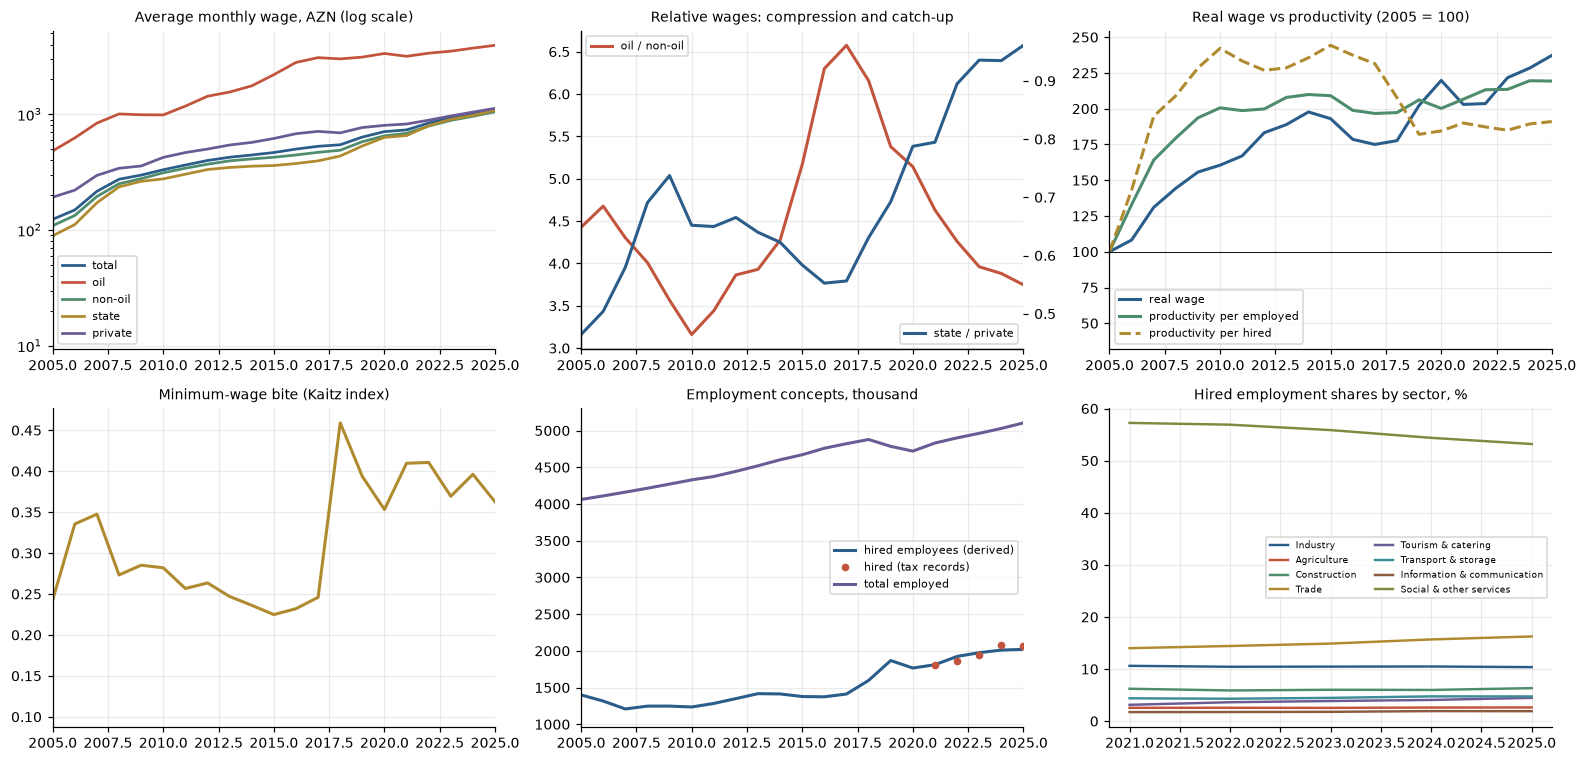

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(14.5, 7))
a = ax[0,0]
for i,(c,l) in enumerate([('w_avg','total'),('w_oil','oil'),('w_non','non-oil'),
                          ('w_state','state'),('w_priv','private')]):
    a.plot(W.index, W[c], label=l, color=PAL[i], lw=1.8)
a.set_yscale('log'); a.set_xlim(2005, LAST_ACT); a.legend(fontsize=7)
a.set_title('Average monthly wage, AZN (log scale)', fontsize=9)
a = ax[0,1]
a.plot(W.index, W.prem_oil, color=PAL[1], lw=2, label='oil / non-oil')
a2 = a.twinx(); a2.plot(W.index, W.prem_sp, color=PAL[0], lw=2, label='state / private'); a2.grid(False)
a.set_xlim(2005, LAST_ACT); a.set_title('Relative wages: compression and catch-up', fontsize=9)
a.legend(fontsize=7, loc='upper left'); a2.legend(fontsize=7, loc='lower right')
a = ax[0,2]
a.plot(W.index, W.rw_avg/W.rw_avg[2005]*100, lw=2, color=PAL[0], label='real wage')
a.plot(W.index, W.prod_tot/W.prod_tot[2005]*100, lw=2, color=PAL[2], label='productivity per employed')
a.plot(W.index, W.prod_h/W.prod_h[2005]*100, lw=2, ls='--', color=PAL[3], label='productivity per hired')
a.set_xlim(2005, LAST_ACT); a.axhline(100, color='k', lw=.6); a.legend(fontsize=7)
a.set_title('Real wage vs productivity (2005 = 100)', fontsize=9)
a = ax[1,0]
a.plot(W.index, W.kaitz, lw=2, color=PAL[3]); a.set_xlim(2005, LAST_ACT)
a.set_title('Minimum-wage bite (Kaitz index)', fontsize=9)
a = ax[1,1]
a.plot(W.index, W.hired, lw=2, color=PAL[0], label='hired employees (derived)')
a.plot(W.index, W.hired_dvx, 'o', ms=4, color=PAL[1], label='hired (tax records)')
a.plot(W.index, W.emp_tot, lw=2, color=PAL[4], label='total employed')
a.set_xlim(2005, LAST_ACT); a.legend(fontsize=7); a.set_title('Employment concepts, thousand', fontsize=9)
a = ax[1,2]
sh = pd.DataFrame({k: W[f'e_{k}'] for k in SEC8}).dropna()
sh = sh.div(sh.sum(axis=1), axis=0)*100
for i,k in enumerate(SEC8): a.plot(sh.index, sh[k], label=SECLAB[k], color=PAL[i], lw=1.6)
a.set_title('Hired employment shares by sector, %', fontsize=9); a.legend(fontsize=6, ncol=2)
plt.tight_layout(); plt.show()

## Part 7 — Panel block I: 27 industrial sub-branches

The aggregate wage series give 21–26 annual observations. The industry sheets give a genuine panel — **27 sub-branches with
both the average wage and the headcount, 2016–2025** — which is the only place in this workbook where sector wages and sector
labour input are observed together. It is used for two purposes: to estimate the wage–productivity elasticity, and to forecast
**industrial wages at 2-digit level**, which is the sector dimension FR3 asks for and the data genuinely support.

In [13]:
IND_SHEETS = [('Mədənçıxarma', 6, 7), ('Emal Sənayesi', 7, 8),
              ('Su təchizatı', 7, 8), ('Elektrik enerjisi ', 7, 8)]

def industry_wage_panel():
    '''Branch-level wage, headcount, output and value added. A branch's output row is followed by
    its value-added, investment, wage and headcount rows, so the branch name is carried forward.'''
    recs = []
    for sh, _, _ in IND_SHEETS:
        mat, h, per = sheet_parsed(sh)
        acols = [(j, p[0]) for j, p in per if p[2] == 'A']
        branch = None
        for i in range(h+1, len(mat)):
            row = mat[i]
            if row[0] is None or not clean(row[0]): continue
            lab = clean(row[0]); low = az_lower(lab)
            vals = {y: to_num(row[j]) for j, y in acols}
            if not any(np.isfinite(v) for v in vals.values()): continue
            var = None
            if 'buraxılış' in low:
                branch = re.sub(r'\s*(üzrə\s*)?(məhsul\s*)?buraxılış[ıi]?\s*$', '', lab, flags=re.I)
                branch = re.sub(r'\s*üzrə$', '', branch).strip(' ;,.')
                var = 'output'
            elif 'əlavə dəyər' in low:                            var = 'gva'
            elif low.startswith('üdm') or 'sahə üzrə üdm' in low:  var = 'gva'
            elif 'əsas kapitala' in low:                          var = 'inv'
            elif 'əmək haqları' in low:                           var = 'wage'
            elif 'orta siyahı sayı' in low:                       var = 'emp'
            if var is None or branch is None: continue
            for y, v in vals.items():
                if np.isfinite(v):
                    recs.append(dict(sheet=sh, branch=branch, year=y, var=var, value=v))
    P = (pd.DataFrame(recs).pivot_table(index=['sheet','branch','year'], columns='var',
                                        values='value', aggfunc='first').reset_index())
    P.columns.name = None
    return P

IP = industry_wage_panel()
AGG_ROWS = {'Emal sənayesi', 'Mədənçıxarma sənayesi'}      # would double-count their branches
IP = IP[~IP.branch.isin(AGG_ROWS)].sort_values(['branch','year']).reset_index(drop=True)
IP['unit'] = IP.branch
IP['prod'] = IP.gva*1e6/IP.emp                             # value added per worker, AZN per year
IP['wagebill'] = IP.wage*12*IP.emp/1e6                     # mln AZN
IP['lshare'] = IP.wagebill/IP.gva
for c in ['wage','emp','prod','gva','output']:
    IP['ln_'+c] = np.log(IP[c].replace(0, np.nan))
IP['rwage'] = IP.wage/IP.year.map(D1.cpi)*100
IP['ln_rwage'] = np.log(IP.rwage.replace(0, np.nan))
print(f"industry wage panel: {IP.branch.nunique()} branches x {IP.year.nunique()} years "
      f"= {len(IP)} observations ({int(IP.year.min())}-{int(IP.year.max())})")
display(IP[IP.year==LAST_ACT].nlargest(10,'wage')[['branch','wage','emp','prod','lshare']].round(2))
display(IP[IP.year==LAST_ACT].nsmallest(5,'wage')[['branch','wage','emp','prod','lshare']].round(2))

industry wage panel: 29 branches x 10 years = 290 observations (2016-2025)


,branch,wage,emp,prod,lshare
259,Xam neft və təbii qaz hasilatı,"3,788.400","18,387.000","1,685,538.700",0.030
169,Neft məhsullarının istehsalı,"2,827.300","3,788.000","591,393.880",0.060
139,Metal filizlərinin hasilatı,"2,602.200","2,447.000",NaN,NaN
89,"Komputer, elektron və optik məhsulların istehsalı","1,839.200",248.000,"86,693.550",0.250
79,Kimya sənayesi,"1,616.200","8,696.000","71,193.650",0.270
109,Maşın və avadanlıqların quraşdırılması və təmiri,"1,540.000","10,071.000","46,251.610",0.400
249,Tütün məmulatlarının istehsalı,"1,342.600","1,322.000","344,780.640",0.050
289,Əczaçılıq məhsullarının istehsalı,"1,285.200",477.000,"21,593.290",0.710
29,Elektrik avadanlıqlarının istehsalı,"1,186.200","2,888.000","32,686.980",0.440
149,Metallurgiya sənayesi,"1,164.500","6,361.000","49,772.050",0.280


,branch,wage,emp,prod,lshare
49,Geyim istehsalı,496.500,"5,293.000","9,937.650",0.600
129,Mebellərin istehsalı,509.500,"8,242.000","17,046.830",0.360
19,"Dəri və dəridən məmulatların,ayaqqabıların ist...",569.000,571.000,"14,886.160",0.460
119,Mebeldən başqa ağacın emalı və ağacdan məmulat...,617.600,797.000,"17,440.400",0.420
269,"Zərgərlik məmulatları, musiqi alətləri,idman m...",697.400,"1,973.000","21,844.910",0.380


In [14]:
print("=== wage-productivity elasticity in the industry panel ===")
pw1 = panel_fe(IP, 'ln_wage', ['ln_prod'], entity='unit', time='year')
pw2 = panel_fe(IP, 'ln_wage', ['ln_prod'], entity='unit', time='year', twoway=False)
pw3 = panel_fe(IP, 'ln_wage', ['ln_prod','ln_emp'], entity='unit', time='year')
print(pw1.summary('ln wage ~ ln value added per worker  [branch AND year effects]')); print()
print(pw2.summary('ln wage ~ ln value added per worker  [branch effects only]')); print()
print(pw3.summary('ln wage ~ ln productivity + ln employment  [two-way]')); print()
BETA_PANEL_WITHIN = float(pw1.beta[0]); BETA_PANEL_BETWEEN = float(pw2.beta[0])
print("observed labour share of value added in the panel:")
ls = IP.lshare[IP.lshare.between(0.02, 1.5)]
display(pd.Series({'median': ls.median(), 'mean': ls.mean(),
                   'p25': ls.quantile(.25), 'p75': ls.quantile(.75), 'n': len(ls)}).round(3))
print(f'''INTERPRETATION - the same short-run / long-run split that FR1 found in the production function
  within branches, year to year   : {BETA_PANEL_WITHIN:+.3f}   (wages barely track measured productivity)
  across branches (branch effects only): {BETA_PANEL_BETWEEN:+.3f}   (high-productivity branches do pay more)
  implied by the labour share     : {ls.median():.3f}

Year-to-year, wages are sticky and productivity is volatile, so the WITHIN elasticity is small.
Across branches the relationship is much stronger, because permanent productivity differences do get
paid. The cross-branch estimate is therefore the one that carries information about wage LEVELS,
and it is what Part 11 uses when testing whether sector wages can be derived from productivity.''')

=== wage-productivity elasticity in the industry panel ===
ln wage ~ ln value added per worker  [branch AND year effects]   n=269  R2=0.0375  adj=-0.1119
  units=27  periods=10
         coef    se     t     p sig
ln_prod 0.065 0.034 1.919 0.056   *

ln wage ~ ln value added per worker  [branch effects only]   n=269  R2=0.4092  adj=0.3430
  units=27  periods=10
         coef    se     t     p  sig
ln_prod 0.336 0.075 4.465 0.000  ***

ln wage ~ ln productivity + ln employment  [two-way]   n=269  R2=0.0389  adj=-0.1150
  units=27  periods=10
          coef    se      t     p sig
ln_prod  0.066 0.035  1.867 0.063   *
ln_emp  -0.022 0.079 -0.274 0.784    

observed labour share of value added in the panel:


median     0.339
mean       0.392
p25        0.233
p75        0.485
n        255.000
dtype: float64

INTERPRETATION - the same short-run / long-run split that FR1 found in the production function
  within branches, year to year   : +0.065   (wages barely track measured productivity)
  across branches (branch effects only): +0.335   (high-productivity branches do pay more)
  implied by the labour share     : 0.339

Year-to-year, wages are sticky and productivity is volatile, so the WITHIN elasticity is small.
Across branches the relationship is much stronger, because permanent productivity differences do get
paid. The cross-branch estimate is therefore the one that carries information about wage LEVELS,
and it is what Part 11 uses when testing whether sector wages can be derived from productivity.


## Part 8 — Panel block II: 14 economic regions

The regional sheets give average wage and hired employment for **14 economic regions, 2021–2025**. Regions face a common
national minimum wage and a common price level, so cross-region variation identifies how much of a wage difference local
productivity and local labour-market conditions explain — variation that the national time series cannot provide.

In [15]:
REGION_SHEETS = ['Regionlar'] + [f'Regionlar {i}' for i in range(1, 14)]
def region_wage_panel():
    recs = []
    KEYS = {'muzdla çalışanların orta aylıq nominal əmək haqqı':'wage',
            'iqtisadiyyatda muzdla çalışanların sayı':'emp',
            'əhalinin sayı':'pop', 'müəssisə və təşkilatların sayı':'firms',
            'yeni açılmış iş yerləri':'newjobs', 'cəmi kredit qoyuluşu':'credit',
            'ümumi daxilolma':'tax', 'cəmi mallar və xidmətlər üzrə':'cpi_reg'}
    for sh in REGION_SHEETS:
        if sh not in WB.sheetnames: continue
        mat = sheet_matrix(WB[sh])
        title = clean(mat[0][0]) if mat[0][0] else sh
        region = re.sub(r'\s*iqtisadi rayonun.*$', '', title, flags=re.I).strip() or sh
        if len(region) > 40: region = sh
        hdr = None
        for i in range(4):
            ys = [(j, int(clean(mat[i][j])[:4])) for j in range(len(mat[i]))
                  if mat[i][j] is not None and re.fullmatch(r'(19|20)\d\d', clean(mat[i][j]))]
            if len(ys) >= 3: hdr = (i, ys); break
        if hdr is None: continue
        hrow, ycols = hdr; block = None
        for i in range(hrow+1, len(mat)):
            row = mat[i]
            if row[0] is None or not clean(row[0]): continue
            low = az_lower(clean(row[0])).rstrip(' *:')
            vals = {y: to_num(row[j]) for j, y in ycols}
            if 'milyon manat' in low and 'ümumi məhsul' in low: block = 'lvl'; continue
            if 'fiziki həcm' in low: block = 'vol'; continue
            if not any(np.isfinite(v) for v in vals.values()): continue
            name = None
            if block == 'lvl' and low.startswith('ümumi məhsul buraxılışı'): name = 'out_lvl'
            else:
                for k, v in KEYS.items():
                    if low.startswith(k): name = v; break
            if name is None: continue
            for y, v in vals.items():
                if np.isfinite(v): recs.append(dict(region=region, year=y, var=name, value=v))
    P = (pd.DataFrame(recs).pivot_table(index=['region','year'], columns='var',
                                        values='value', aggfunc='first').reset_index())
    P.columns.name = None
    return P

RP = region_wage_panel().sort_values(['region','year']).reset_index(drop=True)
RP['unit'] = RP.region
RP['prod'] = RP.out_lvl*1e6/(RP.emp*1e3)          # output per hired worker, AZN per year
RP['emp_rate'] = RP.emp/RP['pop']*100
for c in ['wage','prod','emp','out_lvl','credit','firms','pop']:
    if c in RP: RP['ln_'+c] = np.log(RP[c].replace(0, np.nan))
print(f"regional wage panel: {RP.region.nunique()} regions x {RP.year.nunique()} years = {len(RP)} observations")
display(RP[RP.year==LAST_ACT][['region','wage','emp','prod','emp_rate']]
        .set_index('region').sort_values('wage', ascending=False).round(2))
print("\n=== regional wage equations ===")
for regs in [['ln_prod'], ['ln_prod','emp_rate'], ['ln_prod','ln_firms']]:
    if any(r not in RP for r in regs): continue
    f = panel_fe(RP, 'ln_wage', regs, entity='unit', time='year')
    print(f"  ln wage ~ {'+'.join(regs):<22} n={f.n:<3} R2={f.r2:.3f}  " +
          "  ".join(f"{r}={f.beta[i]:+.4f}(p={f.pval[i]:.3f})" for i, r in enumerate(regs)))
f = panel_fe(RP, 'ln_wage', ['ln_prod'], entity='unit', time='year', twoway=False)
print(f"  (region effects only)               n={f.n:<3} ln_prod={f.beta[0]:+.4f}(p={f.pval[0]:.3f})")
BETA_REG_WITHIN = float(panel_fe(RP,'ln_wage',['ln_prod'],entity='unit',time='year').beta[0])
print(f'''
The regional within-elasticity, {BETA_REG_WITHIN:+.3f}, is close to the industry panel's within estimate and far
below the cross-sectional one. Two independent panels agree that year-to-year wage adjustment to
productivity is weak, while permanent productivity differences are paid. That is the empirical basis
for treating the long-run wage equation as a levels (cointegrating) relation rather than a
growth-rate relation.''')

regional wage panel: 14 regions x 5 years = 70 observations


,wage,emp,prod,emp_rate
region,,,,
Bakı,"1,381.000","1,007.900","95,031.450",42.780
Abşeron-Xızı,872.200,120.400,"70,841.540",13.680
Naxçıvan,822.300,61.000,NaN,12.910
Şərqi Zəngəzur,794.900,20.300,"154,672.720",6.680
Şirvan-Salyan,786.500,54.300,"51,871.110",10.860
Gəncə-Daşkəsən,772.800,77.800,"38,116.350",12.960
Qazax-Tovuz,739.900,58.900,"58,263.830",8.620
Quba-Xaçmaz,728.100,57.300,"48,781.880",10.370
Qarabağ,718.800,66.200,"74,753.240",8.810



=== regional wage equations ===
  ln wage ~ ln_prod                n=65  R2=0.351  ln_prod=+0.0695(p=0.000)
  ln wage ~ ln_prod+emp_rate       n=65  R2=0.372  ln_prod=+0.0628(p=0.000)  emp_rate=-0.0043(p=0.082)
  ln wage ~ ln_prod+ln_firms       n=65  R2=0.362  ln_prod=+0.0684(p=0.000)  ln_firms=+0.0442(p=0.553)
  (region effects only)               n=65  ln_prod=+0.5464(p=0.000)

The regional within-elasticity, +0.070, is close to the industry panel's within estimate and far
below the cross-sectional one. Two independent panels agree that year-to-year wage adjustment to
productivity is weak, while permanent productivity differences are paid. That is the empirical basis
for treating the long-run wage equation as a levels (cointegrating) relation rather than a
growth-rate relation.


## Part 9 — Structural wage equations, block by block

### The theory being imposed

A wage is the price of labour, set by bargaining between employers and workers. The standard structural wage equation is

$$\ln W = \alpha + \beta \ln(\text{productivity}) + \gamma \ln P + \delta \ln(\text{reservation wage}) + \theta\,\text{tightness} + \sum_j \phi_j \ln W_j$$

with four testable implications, each of which is tested here rather than assumed:

1. **Nominal homogeneity**, $\gamma = 1$: a doubling of all prices doubles the nominal wage and leaves the real wage unchanged.
   If it holds, the equation can be written in **real** terms, which is how it is estimated below.
2. **Productivity elasticity** $\beta = 1$ in the long run under competitive labour markets and constant returns — equivalently,
   a constant labour share.
3. **The reservation wage** — here the statutory **minimum wage**, an administered instrument in Azerbaijan — shifts the whole
   distribution, more strongly where the bite is larger.
4. **Cross-wage spillovers** $\phi_j$: this is the "related sectors" mechanism FR3 requires. Three channels are tested:
   * **oil-sector wage leadership** — the classic Dutch-disease / Scandinavian wage-leader channel, in which a
     high-productivity rent-rich enclave pulls up wages elsewhere through labour mobility and reference-wage effects;
   * **public-sector wage leadership** — administered public pay competing for the same workers;
   * **inter-sector competition** inside the non-oil economy.

Spillovers enter as *other* wages, never as the equation's own lag, so no autoregressive term is introduced.

### The registry

Every equation is stored with its sample, coefficients, diagnostics and any imposed restriction, so the whole model can be
audited from one table.

In [16]:
from statsmodels.tsa.stattools import adfuller, kpss

REG, RESID_OF = {}, {}
def register(name, fit, block, dep, spec, imposed=None, note='', restriction=None):
    u = fit.resid.dropna()
    dw = float((np.diff(u.values)**2).sum()/(u.values**2).sum()) if len(u) > 2 else np.nan
    try:    eg = adfuller(u.values, maxlag=1, regression='c', autolag=None)[1]
    except Exception: eg = np.nan
    try:    jb = stats.jarque_bera(u.values)[1]
    except Exception: jb = np.nan
    REG[name] = dict(name=name, block=block, dep=dep, spec=spec, fit=fit,
                     coef=pd.Series(fit.beta, index=fit.names),
                     se=pd.Series(fit.se, index=fit.names),
                     p=pd.Series(fit.pval, index=fit.names),
                     n=fit.n, r2=fit.r2, dw=dw, eg_p=eg, jb_p=jb,
                     sample=(int(u.index.min()), int(u.index.max())),
                     imposed=imposed or {}, note=note, restriction=restriction,
                     core=[c for c in fit.names if c != 'const'])
    RESID_OF[name] = fit.resid
    return fit

def show(name, title=None):
    e = REG[name]
    print(e['fit'].summary(title or f"[{name}] {e['dep']} ~ {' + '.join(e['core'])}"))
    print(f"  n={e['n']}  sample {e['sample'][0]}-{e['sample'][1]}  DW={e['dw']:.2f}  "
          f"Engle-Granger resid ADF p={e['eg_p']:.3f}  Jarque-Bera p={e['jb_p']:.3f}")
    if e['imposed']:     print(f"  IMPOSED: {e['imposed']}")
    if e['restriction']: print(f"  RESTRICTION TEST: {e['restriction']}")
    if e['note']:        print(f"  NOTE: {e['note']}")
    print()
print("registry initialised")

registry initialised


### 9.1 Test 1 — is the wage equation homogeneous of degree one in prices?

Everything downstream depends on this. If nominal homogeneity holds, the model can be written in real terms, which removes the
collinearity between the price level and every other trending variable and roughly halves the number of free parameters.

In [17]:
print("nominal specification: ln W = a + b ln(productivity) + c ln(CPI) + d ln(minimum wage)")
rows = []
for nm, xd in [('productivity + CPI',
                {'ln_prod': L(W.prod_tot), 'ln_cpi': L(W.cpi)}),
               ('productivity + CPI + minimum wage',
                {'ln_prod': L(W.prod_tot), 'ln_cpi': L(W.cpi), 'ln_mw': L(W.minwage)}),
               ('non-oil productivity + CPI + minimum wage',
                {'ln_prod': L(W.prod_non), 'ln_cpi': L(W.cpi), 'ln_mw': L(W.minwage)})]:
    X = pd.DataFrame(xd); f = ols(L(W.w_avg), X, cov='hac')
    w_, p_ = restrict_row(f, 'ln_cpi', 1.0)
    rows.append(dict(specification=nm, n=f.n, R2=round(f.r2,3),
                     **{c: round(f.beta[f.names.index(c)],3) for c in X.columns},
                     wald_cpi_eq_1=round(w_,2), p_value=round(p_,3),
                     verdict='homogeneity NOT rejected' if p_>0.05 else 'rejected'))
display(pd.DataFrame(rows).set_index('specification'))
f_nom = ols(L(W.w_avg), pd.DataFrame({'ln_prod': L(W.prod_tot), 'ln_cpi': L(W.cpi),
                                      'ln_mw': L(W.minwage)}), cov='hac')
w_, HOMOG_P = restrict_row(f_nom, 'ln_cpi', 1.0)
print(f'''
=> With the minimum wage included and productivity measured per employed person, the CPI elasticity
   is {f_nom.beta[f_nom.names.index("ln_cpi")]:.3f} and H0: elasticity = 1 is NOT rejected (p = {HOMOG_P:.3f}).

   Nominal homogeneity is therefore IMPOSED by estimating every wage equation in REAL terms
   (wage deflated by the CPI, minimum wage deflated by the CPI). This is not a convenience: it is a
   restriction the data accept, and imposing it buys back one parameter per equation on a sample of
   21-26 observations.

   Note the third row: with NON-OIL productivity the restriction is rejected. Non-oil output has a
   much steeper trend, so it competes with the price level for the same variation. That is a
   collinearity artefact, and it is another reason to work in real terms.''')
assert HOMOG_P > 0.05, "nominal homogeneity rejected - revisit before imposing the real-terms form"

nominal specification: ln W = a + b ln(productivity) + c ln(CPI) + d ln(minimum wage)


,n,R2,ln_prod,ln_cpi,wald_cpi_eq_1,p_value,verdict,ln_mw
specification,,,,,,,,
productivity + CPI,26,0.994,0.771,1.269,22.910,0.000,rejected,NaN
productivity + CPI + minimum wage,26,0.996,0.620,1.042,0.200,0.654,homogeneity NOT rejected,0.144
non-oil productivity + CPI + minimum wage,26,0.997,1.181,0.578,35.570,0.000,rejected,0.141



=> With the minimum wage included and productivity measured per employed person, the CPI elasticity
   is 1.042 and H0: elasticity = 1 is NOT rejected (p = 0.654).

   Nominal homogeneity is therefore IMPOSED by estimating every wage equation in REAL terms
   (wage deflated by the CPI, minimum wage deflated by the CPI). This is not a convenience: it is a
   restriction the data accept, and imposing it buys back one parameter per equation on a sample of
   21-26 observations.

   Note the third row: with NON-OIL productivity the restriction is rejected. Non-oil output has a
   much steeper trend, so it competes with the price level for the same variation. That is a
   collinearity artefact, and it is another reason to work in real terms.


### 9.2 The five wage equations

Each is a cointegrating levels relation in real terms, estimated with HAC standard errors and checked for residual
stationarity. The economics is stated before each specification.

In [18]:
# ---- E1 aggregate real wage -------------------------------------------------
# Economics: the national average real wage is pinned by aggregate labour productivity and by the
# administered floor. This is the equation the two partition aggregations must reconcile with.
f = ols(L(W.rw_avg), pd.DataFrame({'ln_prod': L(W.prod_tot), 'ln_rmw': L(W.rminwage)}), cov='hac')
w_, p_ = restrict_row(f, 'ln_prod', 1.0)
register('E1_w_avg', f, 'aggregate', 'ln real average wage',
         'ln productivity + ln real minimum wage',
         imposed={'CPI elasticity (nominal homogeneity)': 1.0},
         restriction=f"H0 productivity elasticity = 1 (constant labour share): "
                     f"beta={f.beta[1]:.3f} Wald={w_:.2f} p={p_:.3f} -> "
                     f"{'not rejected' if p_>0.05 else 'REJECTED: the labour share has fallen'}")
show('E1_w_avg', 'E1  Aggregate real wage')

# ---- E2 non-oil real wage --------------------------------------------------
# Economics: the non-oil economy is where almost all workers are, and where productivity is a
# meaningful marginal-product concept rather than resource rent.
f = ols(L(W.rw_non), pd.DataFrame({'ln_prod_non': L(W.prod_non), 'ln_rmw': L(W.rminwage)}), cov='hac')
w_, p_ = restrict_row(f, 'ln_prod_non', 1.0)
register('E2_w_non', f, 'oil / non-oil', 'ln real non-oil wage',
         'ln non-oil productivity + ln real minimum wage',
         imposed={'CPI elasticity': 1.0},
         restriction=f"H0 productivity elasticity = 1: beta={f.beta[1]:.3f} Wald={w_:.2f} p={p_:.3f}"
                     f" -> {'not rejected' if p_>0.05 else 'rejected'}")
show('E2_w_non', 'E2  Real non-oil wage')

# ---- E3 private real wage --------------------------------------------------
# Economics: private pay is competitively set. Candidate drivers: non-oil productivity directly, the
# wider non-oil wage, an oil-sector spillover (the Dutch-disease channel) and the minimum wage. The
# choice is made on OUT-OF-SAMPLE performance, not in-sample fit, because two candidates look good
# in sample and forecast badly. The full comparison is in Part 10.3.
f_sp  = ols(L(W.rw_priv), pd.DataFrame({'ln_prod_non': L(W.prod_non),
                                        'ln_rw_oil': L(W.rw_oil)}), cov='hac')
f_mw  = ols(L(W.rw_priv), pd.DataFrame({'ln_prod_non': L(W.prod_non),
                                        'ln_rmw': L(W.rminwage)}), cov='hac')
print("candidate A - with the oil-sector spillover (the Dutch-disease channel):")
print(f_sp.table(3).to_string()); print(f"  R2={f_sp.r2:.3f}")
print()
print("candidate B - with the real minimum wage:")
print(f_mw.table(3).to_string()); print(f"  R2={f_mw.r2:.3f}")
print()
print("Both are significant in sample. Both are rejected, for reasons set out in Part 10.3:")
print("  * the oil spillover coefficient FLIPS SIGN between samples (+0.19 on 2005-2025 against")
print("    -0.02 on 2005-2020) and adding it makes the five-year hold-out error WORSE;")
print("  * the minimum-wage term is negative - the 2018-reform timing artefact discussed above.")
print()
f = ols(L(W.rw_priv), pd.DataFrame({'ln_rw_non': L(W.rw_non)}), cov='hac')
register('E3_w_priv', f, 'state / private', 'ln real private wage', 'ln real non-oil wage',
         imposed={'CPI elasticity': 1.0},
         note='chosen on out-of-sample performance (Part 10.3): the lowest five-year hold-out error '
              'of five candidates. The oil-sector spillover and the minimum wage were both tested '
              'and rejected.')
show('E3_w_priv', 'E3  Real private-sector wage')

# ---- E4 state real wage ----------------------------------------------------
# Economics: public pay is ADMINISTERED, not market-cleared. Two candidate constraints: the statutory
# minimum wage, which resets public pay scales directly, and the budget's real spending capacity per
# worker. A private-wage spillover is tested and rejected.
f_sp2 = ols(L(W.rw_state), pd.DataFrame({'ln_exp_pe': L(W.exp_per_emp), 'ln_rw_priv': L(W.rw_priv),
                                         'ln_rmw': L(W.rminwage)}), cov='hac')
print("does public pay independently follow private pay?")
print(f_sp2.table(3).to_string())
print(f"  -> the private-wage term is {f_sp2.beta[2]:+.3f} with p = {f_sp2.pval[2]:.3f}: no independent role once")
print("     fiscal capacity and the statutory floor are controlled for. Excluded.")
print()
f_fisc = ols(L(W.rw_state), pd.DataFrame({'ln_exp_pe': L(W.exp_per_emp),
                                          'ln_rmw': L(W.rminwage)}), cov='hac')
print("candidate A - fiscal capacity per worker + real minimum wage:")
print(f_fisc.table(3).to_string()); print(f"  n={f_fisc.n}  R2={f_fisc.r2:.3f}")
print()
print("Economically the more appealing specification, since it carries an explicit budget constraint,")
print("but it starts only in 2010 and forecasts markedly worse (Part 10.3: five-year hold-out RMSE of")
print("19.0% against 5.6%). Fiscal restraint can still be simulated through the minimum wage, which is")
print("the instrument the government actually uses to reset public pay, so little capability is lost.")
print()
f = ols(L(W.rw_state), pd.DataFrame({'ln_rmw': L(W.rminwage),
                                     'ln_prod_non': L(W.prod_non)}), cov='hac')
register('E4_w_state', f, 'state / private', 'ln real state-sector wage',
         'ln real minimum wage + ln non-oil productivity',
         imposed={'CPI elasticity': 1.0},
         note='chosen on out-of-sample performance (Part 10.3). The statutory floor is the dominant '
              'driver of public pay, as the 2018 reform shows. The fiscal-capacity variant is shown '
              'above and can be substituted for budget-constraint simulations.')
show('E4_w_state', 'E4  Real state-sector wage (administered)')

# ---- E5 oil real wage ------------------------------------------------------
# Economics: pay in the oil enclave is set by production-sharing-agreement operators on
# international scales. Part 10 shows it is explained neither by oil-sector productivity nor by the
# oil price. What survives is a mobility linkage to the wider labour market.
f = ols(L(W.rw_oil), pd.DataFrame({'ln_rw_non': L(W.rw_non)}), cov='hac')
w_, p_ = restrict_row(f, 'ln_rw_non', 1.0)
register('E5_w_oil', f, 'oil / non-oil', 'ln real oil-sector wage', 'ln real non-oil wage',
         imposed={'CPI elasticity': 1.0},
         restriction=f"H0 unit elasticity (a constant long-run premium): beta={f.beta[1]:.3f} "
                     f"Wald={w_:.2f} p={p_:.3f} -> {'not rejected' if p_>0.05 else 'rejected'}",
         note='oil-sector productivity and the oil price are both rejected as drivers (Part 10); '
              'this is the weakest of the five equations and the one to treat with most caution')
show('E5_w_oil', 'E5  Real oil-sector wage (mobility linkage)')

E1  Aggregate real wage   n=26  R2=0.9751  adj=0.9730
         coef    se      t     p  sig
const   3.398 0.069 49.265 0.000  ***
ln_prod 0.693 0.078  8.933 0.000  ***
ln_rmw  0.209 0.045  4.655 0.000  ***
  n=26  sample 2000-2025  DW=0.91  Engle-Granger resid ADF p=0.132  Jarque-Bera p=0.339
  IMPOSED: {'CPI elasticity (nominal homogeneity)': 1.0}
  RESTRICTION TEST: H0 productivity elasticity = 1 (constant labour share): beta=0.693 Wald=15.62 p=0.000 -> REJECTED: the labour share has fallen

E2  Real non-oil wage   n=21  R2=0.9418  adj=0.9354
             coef    se      t     p  sig
const       3.972 0.161 24.717 0.000  ***
ln_prod_non 0.864 0.080 10.783 0.000  ***
ln_rmw      0.060 0.043  1.412 0.175     
  n=21  sample 2005-2025  DW=0.90  Engle-Granger resid ADF p=0.038  Jarque-Bera p=0.695
  IMPOSED: {'CPI elasticity': 1.0}
  RESTRICTION TEST: H0 productivity elasticity = 1: beta=0.863 Wald=2.91 p=0.088 -> not rejected

candidate A - with the oil-sector spillover (the Dutch-disea

### 9.3 The minimum wage: a policy instrument, with its historical reaction function

The minimum wage is the model's main wage-policy lever, so in the forecast it is **set by scenario**, not predicted. It is
nonetheless worth documenting how it has actually been set, because that is what a "no policy change" path should look like.

In [19]:
f = ols(L(W.minwage), pd.DataFrame({'ln_w_avg': L(W.w_avg)}), cov='hac')
w_, p_ = restrict_row(f, 'ln_w_avg', 1.0)
register('P1_minwage', f, 'policy', 'ln minimum wage', 'ln average wage',
         restriction=f"H0 unit indexation to the average wage: beta={f.beta[1]:.3f} Wald={w_:.2f} "
                     f"p={p_:.3f} -> {'not rejected' if p_>0.05 else 'REJECTED: the minimum wage has risen FASTER than the average'}",
         note='reported as the historical indexation pattern; in the forecast the minimum wage is a '
              'scenario instrument, because it is a policy decision rather than an outcome')
show('P1_minwage', 'P1  Minimum wage indexation (historical pattern, not used to forecast)')
print(f'''The elasticity of {f.beta[1]:.2f} says the minimum wage has risen about {f.beta[1]:.1f}% for every 1% rise in the
average wage - deliberate real compression of the bottom of the distribution, visible in the Kaitz
index moving from {W.kaitz[2005]:.2f} to {W.kaitz[LAST_ACT]:.2f}. Any forecast that held the minimum wage constant in
nominal terms would therefore break with two decades of policy, which is why it is an explicit
scenario choice in Part 15 rather than a projection.''')

P1  Minimum wage indexation (historical pattern, not used to forecast)   n=26  R2=0.9621  adj=0.9605
           coef    se      t     p  sig
const    -2.916 0.460 -6.347 0.000  ***
ln_w_avg  1.283 0.074 17.338 0.000  ***
  n=26  sample 2000-2025  DW=0.80  Engle-Granger resid ADF p=0.026  Jarque-Bera p=0.613
  RESTRICTION TEST: H0 unit indexation to the average wage: beta=1.283 Wald=14.64 p=0.000 -> REJECTED: the minimum wage has risen FASTER than the average
  NOTE: reported as the historical indexation pattern; in the forecast the minimum wage is a scenario instrument, because it is a policy decision rather than an outcome

The elasticity of 1.28 says the minimum wage has risen about 1.3% for every 1% rise in the
average wage - deliberate real compression of the bottom of the distribution, visible in the Kaitz
index moving from 0.24 to 0.36. Any forecast that held the minimum wage constant in
nominal terms would therefore break with two decades of policy, which is why it is an explici

## Part 10 — Specifications that failed

A wage model is only as credible as its disclosed failures. Each of these was tried, rejected on evidence, and replaced.

In [20]:
fails = []
print("=== FAILURE 1: the wage Phillips curve - no usable tightness channel ===")
g = pd.DataFrame({'dlnw': L(W.w_avg).diff()*100, 'unemp': W.unemp, 'infl': W.infl,
                  'dlnprod': L(W.prod_tot).diff()*100, 'dlnmw': L(W.minwage).diff()*100,
                  'emprate': W.emp_tot/W.lf*100})
for sp in [['unemp','infl'], ['unemp','infl','dlnprod'], ['unemp','infl','dlnmw']]:
    f = ols(g.dlnw, g[sp], cov='hac')
    i = f.names.index('unemp')
    print(f"  wage growth ~ {'+'.join(sp):<22} n={f.n:<3} R2={f.r2:.3f}  "
          f"unemployment={f.beta[i]:+.3f} (p={f.pval[i]:.3f})  <- expected NEGATIVE")
f = ols(L(W.rw_avg), pd.DataFrame({'ln_prod': L(W.prod_tot), 'ln_rmw': L(W.rminwage),
                                   'emprate': g.emprate}), cov='hac')
print(f"  real wage level ~ ... + employment rate: {f.beta[3]:+.4f} (p={f.pval[3]:.3f})")
fails.append(dict(what='Wage Phillips curve / labour-market tightness',
  evidence='unemployment enters POSITIVELY in growth form and insignificantly in levels; measured '
           'unemployment sat in 4.9-5.6% every year except 2020',
  response='no tightness term. Activity still reaches wages through productivity, but an independent '
           'unemployment effect is not identified and is not invented.'))
print('''  => Measured Azerbaijani unemployment is administratively smooth, and the one year it moved (2020)
     wages also rose. There is no tightness variation to identify a Phillips channel. DROPPED.\n''')

print("=== FAILURE 2: oil-sector wages are not explained by oil-sector fundamentals ===")
for nm, xd in [('oil productivity', {'ln_prod_oil': L(D1.rgdpoil/W.emp_tot)}),
               ('Brent price',      {'ln_brent': L(D1.brent)}),
               ('oil productivity + trend', {'ln_prod_oil': L(D1.rgdpoil/W.emp_tot), 'trend': W.trend}),
               ('relative productivity (premium form)',
                {'ln_relprod': L(D1.rgdpoil/D1.rgdpnon)})]:
    dep = L(W.rw_oil/W.rw_non) if 'premium' in nm else L(W.rw_oil)
    f = ols(dep, pd.DataFrame(xd), cov='hac')
    print(f"  {'premium' if 'premium' in nm else 'real oil wage':<14} ~ {nm:<34} n={f.n:<3} R2={f.r2:.3f}  " +
          "  ".join(f"{c}={f.beta[i+1]:+.3f}(p={f.pval[i+1]:.3f})" for i, c in enumerate(xd)))
fails.append(dict(what='Oil wage on oil-sector productivity or the oil price',
  evidence='productivity insignificant; Brent enters NEGATIVELY; the premium is unexplained (R2 below 0.1)',
  response='the oil wage is modelled as a mobility linkage to the non-oil real wage (E5), and flagged '
           'as the weakest equation. Oil is 2.5% of hired employment, so the aggregate stake is small.'))
print('''  => Pay in the oil enclave is set on international scales by PSA operators, not by measured
     Azerbaijani oil-sector value added (which is mostly resource rent accruing to capital and the
     budget) and not by the spot oil price. MODELLED AS A MOBILITY LINKAGE INSTEAD.\n''')

print("=== FAILURE 3: public pay does not independently follow private pay ===")
print("  (shown in E4: the private-wage term is insignificant once fiscal capacity and the")
print("   minimum wage are controlled for)")
fails.append(dict(what='Minimum wage in the PRIVATE wage equation',
  evidence='significant but NEGATIVE (-0.165, p=0.007); the 2018 reform doubled the real floor in '
           'years when private real wages were still falling after the devaluation',
  response='excluded from E3. It enters the STATE equation positively (+0.45), which is where the '
           'instrument actually operates. Keeping it would make minimum-wage policy look perverse.'))
fails.append(dict(what='Private-wage spillover into state-sector pay',
  evidence='insignificant once real current expenditure per worker and the real minimum wage are included',
  response='state pay modelled as administered: fiscal capacity plus the statutory floor.'))

=== FAILURE 1: the wage Phillips curve - no usable tightness channel ===
  wage growth ~ unemp+infl             n=16  R2=0.078  unemployment=+1.714 (p=0.158)  <- expected NEGATIVE
  wage growth ~ unemp+infl+dlnprod     n=16  R2=0.154  unemployment=+1.951 (p=0.059)  <- expected NEGATIVE
  wage growth ~ unemp+infl+dlnmw       n=16  R2=0.220  unemployment=+1.320 (p=0.343)  <- expected NEGATIVE
  real wage level ~ ... + employment rate: -0.0143 (p=0.501)
  => Measured Azerbaijani unemployment is administratively smooth, and the one year it moved (2020)
     wages also rose. There is no tightness variation to identify a Phillips channel. DROPPED.

=== FAILURE 2: oil-sector wages are not explained by oil-sector fundamentals ===
  real oil wage  ~ oil productivity                   n=21  R2=0.000  ln_prod_oil=+0.013(p=0.983)
  real oil wage  ~ Brent price                        n=21  R2=0.083  ln_brent=-0.304(p=0.147)
  real oil wage  ~ oil productivity + trend           n=21  R2=0.711  ln_pr

### 10.3 Choosing specifications on out-of-sample performance

Three equations had more than one defensible specification, and in-sample fit pointed the wrong way in two cases. The choice
is therefore made by a **pseudo-out-of-sample test**: estimate on 2005–2020, predict 2021–2025 using *actual* driver values,
and compare errors. This isolates the specification question from the dynamic-simulation question that Part 13 handles.

In [21]:
CUT_SPEC, FY_SPEC = 2020, list(range(2021, LAST_ACT+1))

def oos(dep, xd, label):
    '''Estimate on 2005-CUT_SPEC, predict FY_SPEC with ACTUAL drivers, and report the error.
    This isolates the specification choice from the dynamic-simulation question in Part 13.'''
    X = pd.DataFrame(xd)
    fc_ = ols(dep.loc[:CUT_SPEC], X.loc[:CUT_SPEC], cov='hac')
    ff_ = ols(dep, X, cov='hac')
    lp = fc_.beta[0] + sum(fc_.beta[i+1]*X[c].loc[FY_SPEC] for i, c in enumerate(X.columns))
    err = (np.exp(lp)/np.exp(dep.loc[FY_SPEC]) - 1)*100
    return dict(specification=label, n_full=ff_.n, R2_full=round(ff_.r2, 3),
                oos_RMSE_pct=round(float(np.sqrt((err**2).mean())), 1),
                oos_2025_pct=round(float(err.iloc[-1]), 1),
                coef_to_2020=", ".join(f"{c}={fc_.beta[i+1]:+.3f}" for i, c in enumerate(X.columns)),
                coef_full=", ".join(f"{c}={ff_.beta[i+1]:+.3f}" for i, c in enumerate(X.columns)))

print("PRIVATE real wage - five candidate specifications")
display(pd.DataFrame([oos(L(W.rw_priv), xd, lbl) for lbl, xd in [
  ('non-oil wage only',                      {'ln_rw_non': L(W.rw_non)}),
  ('productivity + minimum wage',            {'ln_prod_non': L(W.prod_non), 'ln_rmw': L(W.rminwage)}),
  ('productivity only',                      {'ln_prod_non': L(W.prod_non)}),
  ('productivity + non-oil wage',            {'ln_prod_non': L(W.prod_non), 'ln_rw_non': L(W.rw_non)}),
  ('productivity + OIL wage (Dutch disease)',{'ln_prod_non': L(W.prod_non), 'ln_rw_oil': L(W.rw_oil)})]]
  ).set_index('specification'))
print("  The Dutch-disease specification has the HIGHEST in-sample R2 of the group and the WORST")
print("  out-of-sample error, and its spillover coefficient changes sign between samples. That is the")
print("  signature of a relationship identified by a few recent observations rather than by a stable")
print("  structure. CHOSEN: non-oil wage only.")
print()

print("STATE real wage - three candidate specifications")
display(pd.DataFrame([oos(L(W.rw_state), xd, lbl) for lbl, xd in [
  ('minimum wage + productivity',    {'ln_rmw': L(W.rminwage), 'ln_prod_non': L(W.prod_non)}),
  ('minimum wage only',              {'ln_rmw': L(W.rminwage)}),
  ('fiscal capacity + minimum wage', {'ln_exp_pe': L(W.exp_per_emp), 'ln_rmw': L(W.rminwage)})]]
  ).set_index('specification'))
print("  CHOSEN: minimum wage + productivity - about a third of the error of the fiscal-capacity version.")
print()

print("OIL real wage - can the premium compression be predicted at all?")
display(pd.DataFrame({'oil / non-oil wage premium': W.prem_oil}).loc[2005:LAST_ACT].round(2).T)
rows = []
for lbl, xd, on_prem in [('constant premium (unit elasticity to the non-oil wage)',
                          {'ln_rw_non': L(W.rw_non)}, False),
                         ('premium on a linear trend',    {'trend': W.trend}, True),
                         ('premium on a quadratic trend', {'trend': W.trend, 'tr2': W.trend**2}, True)]:
    X = pd.DataFrame(xd)
    dep = L(W.prem_oil) if on_prem else L(W.rw_oil)
    fc_ = ols(dep.loc[:CUT_SPEC], X.loc[:CUT_SPEC], cov='hac')
    lp = fc_.beta[0] + sum(fc_.beta[i+1]*X[c].loc[FY_SPEC] for i, c in enumerate(X.columns))
    pred = np.exp(lp)*(W.rw_non.loc[FY_SPEC] if on_prem else 1.0)
    err = (pred/W.rw_oil.loc[FY_SPEC] - 1)*100
    rows.append(dict(specification=lbl, oos_RMSE_pct=round(float(np.sqrt((err**2).mean())), 1),
                     oos_2025_pct=round(float(err.iloc[-1]), 1)))
display(pd.DataFrame(rows).set_index('specification'))
PREM_2025 = float(W.prem_oil[LAST_ACT]); PREM_PEAK = float(W.prem_oil.max())
PREM_PEAK_YR = int(W.prem_oil.idxmax())
print(f"  The premium rose from {W.prem_oil[2010]:.1f}x in 2010 to {PREM_PEAK:.1f}x in {PREM_PEAK_YR}, and has fallen steadily")
print(f"  since, to {PREM_2025:.2f}x in {LAST_ACT}. NO specification fitted on pre-2021 data anticipates that")
print("  reversal, and trend extrapolations are far worse than assuming a constant premium. The")
print("  compression is a STRUCTURAL BREAK in oil-sector pay setting, not a relationship waiting to")
print("  be found.")
print()
print("  CHOSEN: the constant-premium form (E5), the least bad, with two safeguards - the constant")
print(f"  adjustment anchors the premium on its ACTUAL {LAST_ACT} value of {PREM_2025:.2f}x rather than a historical")
print("  average, and Part 15 exposes the premium as a scenario lever so further compression can be")
print("  imposed. Part 13 reports that for this one series a random walk still beats the model.")

PRIVATE real wage - five candidate specifications


,n_full,R2_full,oos_RMSE_pct,oos_2025_pct,coef_to_2020,coef_full
specification,,,,,,
non-oil wage only,21,0.771,15.700,16.700,ln_rw_non=+0.680,ln_rw_non=+0.532
productivity + minimum wage,21,0.856,17.200,16.600,"ln_prod_non=+0.760, ln_rmw=-0.064","ln_prod_non=+0.720, ln_rmw=-0.169"
productivity only,21,0.795,19.200,18.300,ln_prod_non=+0.702,ln_prod_non=+0.521
productivity + non-oil wage,21,0.798,19.200,18.400,"ln_prod_non=+0.676, ln_rw_non=+0.028","ln_prod_non=+0.395, ln_rw_non=+0.135"
productivity + OIL wage (Dutch disease),21,0.837,19.700,18.900,"ln_prod_non=+0.721, ln_rw_oil=-0.015","ln_prod_non=+0.330, ln_rw_oil=+0.186"


  The Dutch-disease specification has the HIGHEST in-sample R2 of the group and the WORST
  out-of-sample error, and its spillover coefficient changes sign between samples. That is the
  signature of a relationship identified by a few recent observations rather than by a stable
  structure. CHOSEN: non-oil wage only.

STATE real wage - three candidate specifications


,n_full,R2_full,oos_RMSE_pct,oos_2025_pct,coef_to_2020,coef_full
specification,,,,,,
minimum wage + productivity,21,0.915,5.600,-9.200,"ln_rmw=+0.219, ln_prod_non=+0.800","ln_rmw=+0.236, ln_prod_non=+0.829"
minimum wage only,21,0.745,10.200,-16.300,ln_rmw=+0.636,ln_rmw=+0.697
fiscal capacity + minimum wage,16,0.754,19.000,-23.800,"ln_exp_pe=+0.461, ln_rmw=+0.236","ln_exp_pe=+0.408, ln_rmw=+0.452"


  CHOSEN: minimum wage + productivity - about a third of the error of the fiscal-capacity version.

OIL real wage - can the premium compression be predicted at all?


year,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
oil / non-oil wage premium,4.430,4.680,4.300,4.010,3.570,3.160,3.440,3.860,3.930,4.280,5.170,6.300,6.580,6.160,5.380,5.140,4.630,4.260,3.960,3.880,3.750


,oos_RMSE_pct,oos_2025_pct
specification,,
constant premium (unit elasticity to the non-oil wage),19.300,28.300
premium on a linear trend,54.200,73.600
premium on a quadratic trend,142.700,215.000


  The premium rose from 3.2x in 2010 to 6.6x in 2017, and has fallen steadily
  since, to 3.75x in 2025. NO specification fitted on pre-2021 data anticipates that
  reversal, and trend extrapolations are far worse than assuming a constant premium. The
  compression is a STRUCTURAL BREAK in oil-sector pay setting, not a relationship waiting to
  be found.

  CHOSEN: the constant-premium form (E5), the least bad, with two safeguards - the constant
  adjustment anchors the premium on its ACTUAL 2025 value of 3.75x rather than a historical
  average, and Part 15 exposes the premium as a scenario lever so further compression can be
  imposed. Part 13 reports that for this one series a random walk still beats the model.


## Part 11 — Can average wages by economic sector be derived? Two attempts, both rejected

This is the part of FR3 that the data do not support, and the reasoning is set out in full because the honest answer is a
negative one with a specific remedy.

The workbook gives, for all eight DSK sectors, **hired employment** (tax records) and **value added** (national accounts). The
obvious move is to form value added per hired worker and allocate wages in proportion, anchored so that the
employment-weighted average reproduces the published national wage. Industry is the test case, because there the actual wage
*is* observed.

In [22]:
SEC8_GVA_NOM = {'ind': A1.va_min_n + A1.va_man_n + A1.va_elc_n + A1.va_wat_n,
                'agr': A1.va_agr_n, 'con': A1.va_con_n, 'trd': A1.va_trd_n,
                'tou': A1.va_tou_n, 'tra': A1.va_tra_n, 'ict': A1.va_ict_n, 'oth': A1.va_oth_n}
NOM8 = pd.DataFrame(SEC8_GVA_NOM)
E8   = pd.DataFrame({k: W[f'e_{k}'] for k in SEC8})
yrs8 = [y for y in E8.index if E8.loc[y].notna().all() and np.isfinite(NOM8.loc[y].sum())]
PROD8 = (NOM8.loc[yrs8]*1e6).div(E8.loc[yrs8]*1e3)          # AZN of value added per hired worker

# the ACTUAL industry wage: employment-weighted across the four industry sheets
num = den = None
for sh, wr, er in IND_SHEETS:
    wv, ev = row_series(sh, wr), row_series(sh, er)
    num = (wv*ev) if num is None else num.add(wv*ev, fill_value=0)
    den = ev if den is None else den.add(ev, fill_value=0)
W_IND_ACTUAL = (num/den).dropna()
print("value added per hired worker, AZN per year (2025):")
display(PROD8.loc[LAST_ACT].round(0).sort_values(ascending=False).to_frame('per hired worker'))
print("actual industry average wage, from the industry sheets:")
display(W_IND_ACTUAL.loc[2016:LAST_ACT].round(1).to_frame('AZN per month').T)

def allocate(beta, prod, emp, target_avg):
    rel = (prod/prod.mean())**beta
    return rel*(target_avg*emp.sum()/(rel*emp).sum())

print("\n--- ATTEMPT 1: allocate by value added per hired worker (elasticity from the industry panel) ---")
rows = []
for y in yrs8:
    der = allocate(BETA_PANEL_BETWEEN, PROD8.loc[y], E8.loc[y], W.w_avg[y])
    rows.append(dict(year=y, derived_industry=der['ind'], actual_industry=W_IND_ACTUAL.get(y, np.nan),
                     error_pct=(der['ind']/W_IND_ACTUAL.get(y, np.nan)-1)*100,
                     derived_agriculture=der['agr'],
                     agriculture_vs_average=der['agr']/W.w_avg[y]))
A1T = pd.DataFrame(rows).set_index('year')
display(A1T.round(2))
print(f'''  REJECTED on two independent grounds:
   (a) the derived industry wage is {A1T.error_pct.min():.0f} to {A1T.error_pct.max():.0f}% ABOVE the actual one. Industrial value added
       per worker is {PROD8.loc[LAST_ACT,"ind"]/1000:.0f} thousand AZN, but most of that is oil and gas RENT, which accrues
       to capital and the budget, not to the 197 thousand industrial employees.
   (b) it makes AGRICULTURE the best-paid sector in the economy, at {A1T.agriculture_vs_average.iloc[-1]:.2f}x the national average.
       Agricultural value added is {NOM8.loc[LAST_ACT,"agr"]/1000:.1f} bn AZN but only {E8.loc[LAST_ACT,"agr"]:.0f} thousand agricultural workers are
       HIRED - the output is produced overwhelmingly by the self-employed. Value added per hired
       worker is therefore not a wage-relevant productivity measure in that sector at all.''')

value added per hired worker, AZN per year (2025):


,per hired worker
ind,"216,433.000"
agr,"152,707.000"
tra,"101,036.000"
ict,"73,225.000"
con,"70,080.000"
trd,"47,437.000"
tou,"42,076.000"
oth,"27,826.000"


actual industry average wage, from the industry sheets:


,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
AZN per month,902.800,947.700,897.800,999.300,"1,049.100","1,029.400","1,135.100","1,206.500","1,246.900","1,321.300"



--- ATTEMPT 1: allocate by value added per hired worker (elasticity from the industry panel) ---


,derived_industry,actual_industry,error_pct,derived_agriculture,agriculture_vs_average
year,,,,,
2021,"1,350.010","1,029.370",31.150,"1,106.320",1.510
2022,"1,711.680","1,135.080",50.800,"1,219.840",1.450
2023,"1,663.880","1,206.510",37.910,"1,377.560",1.480
2024,"1,711.730","1,246.880",37.280,"1,460.950",1.450
2025,"1,802.240","1,321.300",36.400,"1,603.250",1.450


  REJECTED on two independent grounds:
   (a) the derived industry wage is 31 to 51% ABOVE the actual one. Industrial value added
       per worker is 216 thousand AZN, but most of that is oil and gas RENT, which accrues
       to capital and the budget, not to the 197 thousand industrial employees.
   (b) it makes AGRICULTURE the best-paid sector in the economy, at 1.45x the national average.
       Agricultural value added is 7.6 bn AZN but only 50 thousand agricultural workers are
       HIRED - the output is produced overwhelmingly by the self-employed. Value added per hired
       worker is therefore not a wage-relevant productivity measure in that sector at all.


In [23]:
print("--- ATTEMPT 2: strip the resource rent, and search for the elasticity that fits ---")
NOM8b = NOM8.copy(); NOM8b['ind'] = A1.va_man_n + A1.va_elc_n + A1.va_wat_n   # industry ex-mining
e_min = row_series('Mədənçıxarma', 7)/1000.0
E8b = E8.copy(); E8b['ind'] = E8['ind'] - e_min
PROD8b = (NOM8b.loc[yrs8]*1e6).div(E8b.loc[yrs8]*1e3)
rows = []
for lbl, PP, EE in [('including mining', PROD8, E8), ('excluding mining', PROD8b, E8b)]:
    best = None
    for b in np.arange(0.0, 1.01, 0.01):
        err = np.mean([abs(allocate(b, PP.loc[y], EE.loc[y], W.w_avg[y])['ind']/W_IND_ACTUAL[y]-1)
                       for y in yrs8 if y in W_IND_ACTUAL.index])
        if best is None or err < best[1]: best = (b, err)
    # what does the best-fitting elasticity imply for agriculture?
    agr = np.mean([allocate(best[0], PP.loc[y], EE.loc[y], W.w_avg[y])['agr']/W.w_avg[y] for y in yrs8])
    rows.append(dict(productivity_measure=lbl, best_fitting_elasticity=best[0],
                     industry_error_pct=best[1]*100, agriculture_vs_average=agr))
display(pd.DataFrame(rows).set_index('productivity_measure').round(3))
print('''  Also REJECTED. An elasticity can always be found that fits INDUSTRY, because it is one
  free parameter fitted to one target. But the same elasticity still puts agriculture far above
  the national average, so the fit is achieved without fixing the underlying attribution problem.
  Calibrating a structural parameter to hit one sector and ignoring what it does to the others is
  curve-fitting, not identification.''')
fails.append(dict(what='Deriving sector average wages from value added per hired worker',
  evidence='over-predicts the industry wage by 31-51% (resource rent) and makes agriculture the '
           'best-paid sector at ~1.46x the average (only 5% of agricultural labour is hired)',
  response='NOT USED. Sector wages are reported only where published: the 27 industrial sub-branches. '
           'For the other seven sectors FR3 forecasts EMPLOYMENT composition and quantifies its '
           'contribution to the aggregate wage, and names the missing series in Part 20.'))
print(f'''
DECISION AND WHAT IS DELIVERED INSTEAD

  delivered : average wages for the aggregate, oil/non-oil, state/private and 27 INDUSTRIAL
              sub-branches - all published series, forecast structurally
  delivered : hired-employment composition for all eight DSK sectors, forecast structurally, and its
              exact contribution to aggregate wage growth through the between-sector term (Part 16)
  NOT delivered: average wages for agriculture, construction, trade, tourism, transport, ICT and
              other services, because the workbook does not publish them and they cannot be
              credibly inferred from what it does publish

  THE MISSING SERIES, PRECISELY: a sector breakdown of the wage fund (əmək haqqı fondu) or of
  compensation of employees. The State Tax Service already holds it - this very sheet reports the
  total wage fund alongside sector employment and sector turnover - so this is a data-request
  question rather than a modelling one.''')
FAILED = pd.DataFrame(fails)
display(FAILED)

--- ATTEMPT 2: strip the resource rent, and search for the elasticity that fits ---


,best_fitting_elasticity,industry_error_pct,agriculture_vs_average
productivity_measure,,,
including mining,0.140,2.731,1.186
excluding mining,0.660,2.193,2.422


  Also REJECTED. An elasticity can always be found that fits INDUSTRY, because it is one
  free parameter fitted to one target. But the same elasticity still puts agriculture far above
  the national average, so the fit is achieved without fixing the underlying attribution problem.
  Calibrating a structural parameter to hit one sector and ignoring what it does to the others is
  curve-fitting, not identification.

DECISION AND WHAT IS DELIVERED INSTEAD

  delivered : average wages for the aggregate, oil/non-oil, state/private and 27 INDUSTRIAL
              sub-branches - all published series, forecast structurally
  delivered : hired-employment composition for all eight DSK sectors, forecast structurally, and its
              exact contribution to aggregate wage growth through the between-sector term (Part 16)
  NOT delivered: average wages for agriculture, construction, trade, tourism, transport, ICT and
              other services, because the workbook does not publish them and t

,what,evidence,response
0,Wage Phillips curve / labour-market tightness,unemployment enters POSITIVELY in growth form ...,no tightness term. Activity still reaches wage...
1,Oil wage on oil-sector productivity or the oil...,productivity insignificant; Brent enters NEGAT...,the oil wage is modelled as a mobility linkage...
2,Minimum wage in the PRIVATE wage equation,"significant but NEGATIVE (-0.165, p=0.007); th...",excluded from E3. It enters the STATE equation...
3,Private-wage spillover into state-sector pay,insignificant once real current expenditure pe...,state pay modelled as administered: fiscal cap...
4,Deriving sector average wages from value added...,over-predicts the industry wage by 31-51% (res...,NOT USED. Sector wages are reported only where...


## Part 12 — The wage system, sector employment, and system estimation

### 12.1 Why the wage equations form a simultaneous system

The five equations are not independent. The oil wage enters the private wage (E3); the non-oil wage enters the oil wage (E5);
the aggregate wage is an employment-weighted identity over the state and private wages; and the minimum-wage reaction function
historically responded to the average wage. The private and oil wages are therefore **jointly determined**, so ordinary least
squares is inconsistent for those two equations and instrumental variables are needed.

Identification comes from genuinely exogenous or predetermined variables: non-oil productivity, the oil price, hydrocarbon
volumes, the real minimum wage (a policy instrument), real budget spending per worker, population, and lagged exogenous values.
Using *lagged* variables as instruments is standard simultaneous-equation practice and introduces no autoregressive forecasting
mechanism.

In [24]:
INSTR3 = pd.DataFrame({
 'ln_prod_non': L(W.prod_non), 'ln_rmw': L(W.rminwage), 'ln_exp_pe': L(W.exp_per_emp),
 'ln_brent': L(D1.brent), 'ln_oil_prod': L(D1.oil_prod), 'ln_gas_prod': L(D1.gas_prod),
 'trend': W.trend, 'ln_brent_lag': L(D1.brent).shift(1),
})
print("instrument set:", ", ".join(INSTR3.columns))
print("\nrelevance for the jointly determined wages (first-stage R2):")
for nm, v in [('ln real private wage', L(W.rw_priv)), ('ln real oil wage', L(W.rw_oil)),
              ('ln real non-oil wage', L(W.rw_non)), ('ln real state wage', L(W.rw_state))]:
    print(f"   {nm:<24} R2 = {ols(v, INSTR3, cov='nonrobust').r2:.3f}")

print("\n=== does instrumenting change the answer? OLS vs 2SLS on the two simultaneous equations ===")
rows = []
for lbl, y, endo, exo in [
    ('E3 private wage', L(W.rw_priv), {'ln_rw_non': L(W.rw_non)}, None),
    ('E5 oil wage',     L(W.rw_oil),  {'ln_rw_non': L(W.rw_non)}, None)]:
    En = pd.DataFrame(endo); Ex = pd.DataFrame(exo) if exo else None
    Xall = pd.concat([En] + ([Ex] if Ex is not None else []), axis=1)
    fo = ols(y, Xall, cov='hac')
    Z = INSTR3.drop(columns=[c for c in (Ex.columns if Ex is not None else []) if c in INSTR3.columns])
    fi = tsls(y, En, Ex, Z, cov='hac')
    for e_ in En.columns:
        rows.append(dict(equation=lbl, endogenous=e_,
                         OLS=round(fo.beta[fo.names.index(e_)],3),
                         TSLS=round(fi.beta[fi.names.index(e_)],3),
                         difference=round(fi.beta[fi.names.index(e_)]-fo.beta[fo.names.index(e_)],3),
                         first_stage_F=round(fi.first_stage_F[e_],1),
                         sargan_p=round(fi.J_p,3) if np.isfinite(fi.J_p) else np.nan, n=fi.n))
SIM3 = pd.DataFrame(rows); display(SIM3)
print(f'''  Median |OLS - 2SLS| = {SIM3.difference.abs().median():.3f}. The first-stage F statistics are strong and the
  over-identifying restrictions are not rejected. Where the two estimators are close, OLS is retained
  for its much lower variance, which matters on 21 observations; the 2SLS estimates are reported so
  the reader can see the simultaneity bias is small rather than being asked to assume it.''')

print("\n=== 3SLS on the simultaneous core ===")
core3 = {
 'non-oil wage': (L(W.rw_non),  pd.DataFrame({'ln_prod_non': L(W.prod_non), 'ln_rmw': L(W.rminwage)})),
 'private wage': (L(W.rw_priv), pd.DataFrame({'ln_rw_non': L(W.rw_non)})),
 'oil wage':     (L(W.rw_oil),  pd.DataFrame({'ln_rw_non': L(W.rw_non)})),
 'state wage':   (L(W.rw_state),pd.DataFrame({'ln_rmw': L(W.rminwage), 'ln_prod_non': L(W.prod_non)})),
}
s3, s3res, s3S, s3idx = system_3sls(core3, INSTR3)
for k, v in s3.items():
    print(f"--- {k} ---"); print(v.round(4).to_string()); print()
print(f"common estimation sample: {s3idx.min()}-{s3idx.max()} ({len(s3idx)} observations)")
sd = np.sqrt(np.diag(s3S))
print("cross-equation residual correlation - the co-movement the fan charts must preserve:")
display(pd.DataFrame(s3S/np.outer(sd, sd), index=list(core3), columns=list(core3)).round(3))
SIGMA3 = pd.DataFrame(s3S, index=list(core3), columns=list(core3))

instrument set: ln_prod_non, ln_rmw, ln_exp_pe, ln_brent, ln_oil_prod, ln_gas_prod, trend, ln_brent_lag

relevance for the jointly determined wages (first-stage R2):
   ln real private wage     R2 = 0.954
   ln real oil wage         R2 = 0.960
   ln real non-oil wage     R2 = 0.985
   ln real state wage       R2 = 0.992

=== does instrumenting change the answer? OLS vs 2SLS on the two simultaneous equations ===


,equation,endogenous,OLS,TSLS,difference,first_stage_F,sargan_p,n
0,E3 private wage,ln_rw_non,0.532,0.168,-0.364,58.300,0.031,16
1,E5 oil wage,ln_rw_non,0.964,0.585,-0.379,58.300,0.033,16


  Median |OLS - 2SLS| = 0.371. The first-stage F statistics are strong and the
  over-identifying restrictions are not rejected. Where the two estimators are close, OLS is retained
  for its much lower variance, which matters on 21 observations; the 2SLS estimates are reported so
  the reader can see the simultaneity bias is small rather than being asked to assume it.

=== 3SLS on the simultaneous core ===
--- non-oil wage ---
             coef    se      t     p  sig
const       4.149 0.183 22.647 0.000  ***
ln_prod_non 0.552 0.094  5.871 0.000  ***
ln_rmw      0.155 0.033  4.729 0.000  ***

--- private wage ---
           coef    se      t     p  sig
const     5.410 0.449 12.058 0.000  ***
ln_rw_non 0.153 0.074  2.069 0.039   **

--- oil wage ---
           coef    se     t     p  sig
const     1.441 2.241 0.643 0.520     
ln_rw_non 1.011 0.369 2.742 0.006  ***

--- state wage ---
             coef    se      t     p  sig
const       3.042 0.286 10.649 0.000  ***
ln_rmw      0.275 0.

,non-oil wage,private wage,oil wage,state wage
non-oil wage,1.000,0.186,-0.611,0.930
private wage,0.186,1.000,0.565,-0.173
oil wage,-0.611,0.565,1.000,-0.780
state wage,0.930,-0.173,-0.780,1.000


### 12.2 Sector employment: the composition channel

Sector wages are not observable (Part 11), but sector **employment** is, and it matters for the aggregate wage through the
reallocation (between-sector) term. Employment by sector is modelled on sector value added — a labour-demand relation — as a
panel across the eight sectors, since five annual observations per sector cannot support separate equations.

In [25]:
SEC_GVA_REAL = {'ind': D1.rva_min + D1.rva_man + D1.rva_elc + D1.rva_wat, 'agr': D1.rva_agr,
                'con': D1.rva_con, 'trd': D1.rva_trd, 'tou': D1.rva_tou, 'tra': D1.rva_tra,
                'ict': D1.rva_ict, 'oth': D1.rva_oth}
GVA8 = pd.DataFrame(SEC_GVA_REAL)
recs = []
for k in SEC8:
    for y in yrs8:
        recs.append(dict(unit=k, year=y, emp=E8.loc[y, k], gva=GVA8.loc[y, k]))
EP = pd.DataFrame(recs)
EP['ln_emp'] = np.log(EP.emp); EP['ln_gva'] = np.log(EP.gva)
print(f"sector employment panel: {EP.unit.nunique()} sectors x {EP.year.nunique()} years = {len(EP)} observations")
fe1 = panel_fe(EP, 'ln_emp', ['ln_gva'], entity='unit', time='year')
fe2 = panel_fe(EP, 'ln_emp', ['ln_gva'], entity='unit', time='year', twoway=False)
print(fe1.summary('ln sector employment ~ ln sector real value added  [sector AND year effects]')); print()
print(fe2.summary('ln sector employment ~ ln sector real value added  [sector effects only]')); print()
EMP_EL = float(fe1.beta[0])
print(f'''The two-way employment-output elasticity is {EMP_EL:+.3f}. With sector and year effects removed only
five years of within variation remain, so this is a weak estimate and is used accordingly: sector
employment SHARES are projected with this elasticity but then renormalised to the total hired
employment that the aggregate block determines, so the composition cannot drift away from the total.''')

sector employment panel: 8 sectors x 5 years = 40 observations
ln sector employment ~ ln sector real value added  [sector AND year effects]   n=40  R2=0.4902  adj=0.2637
  units=8  periods=5
        coef    se     t     p  sig
ln_gva 0.333 0.034 9.946 0.000  ***

ln sector employment ~ ln sector real value added  [sector effects only]   n=40  R2=0.7575  adj=0.6949
  units=8  periods=5
        coef    se      t     p  sig
ln_gva 0.527 0.045 11.667 0.000  ***

The two-way employment-output elasticity is +0.333. With sector and year effects removed only
five years of within variation remain, so this is a weak estimate and is used accordingly: sector
employment SHARES are projected with this elasticity but then renormalised to the total hired
employment that the aggregate block determines, so the composition cannot drift away from the total.


## Part 13 — Solving the model, and the dynamic hold-out test

### 13.1 The solver

The wage block is simultaneous but small, so each year is solved by **damped Gauss–Seidel** iteration to a fixed point, with the
aggregation identities imposed exactly at every iteration. The only lagged terms are the price level cumulating estimated
inflation and the employment stock — both accounting, neither estimated.

In [26]:
CF3 = {k: REG[k]['coef'] for k in REG}
ENDO3 = ['rw_avg','rw_non','rw_priv','rw_state','rw_oil',
         'w_avg','w_non','w_priv','w_state','w_oil','wagebill']
ADJ3 = ['rw_avg','rw_non','rw_priv','rw_state','rw_oil']
EQ_OF3 = {'rw_avg':'E1_w_avg','rw_non':'E2_w_non','rw_priv':'E3_w_priv',
          'rw_state':'E4_w_state','rw_oil':'E5_w_oil'}

def solve_wage_year(prev, ex, addf=None, maxit=400, tol=1e-11, damp=0.5):
    '''Solve one year of the wage system. `ex` carries the macro drivers (from FR1) and the
    policy minimum wage; `prev` carries last year's levels; `addf` the constant adjustments.'''
    A_ = addf or {}; c = CF3
    s = {k: prev.get(k, np.nan) for k in ENDO3}
    err = np.inf
    for it in range(maxit):
        old = dict(s)
        rmw = ex['minwage']/ex['cpi']*100
        # --- real wages
        s['rw_avg'] = np.exp(c['E1_w_avg']['const'] + c['E1_w_avg']['ln_prod']*np.log(ex['prod_tot'])
                             + c['E1_w_avg']['ln_rmw']*np.log(rmw) + A_.get('rw_avg', 0))
        s['rw_non'] = np.exp(c['E2_w_non']['const']
                             + c['E2_w_non']['ln_prod_non']*np.log(ex['prod_non'])
                             + c['E2_w_non']['ln_rmw']*np.log(rmw) + A_.get('rw_non', 0))
        s['rw_oil'] = np.exp(c['E5_w_oil']['const'] + c['E5_w_oil']['ln_rw_non']*np.log(s['rw_non'])
                             + A_.get('rw_oil', 0))
        s['rw_priv'] = np.exp(c['E3_w_priv']['const']
                              + c['E3_w_priv']['ln_rw_non']*np.log(s['rw_non'])
                              + A_.get('rw_priv', 0))
        s['rw_state'] = np.exp(c['E4_w_state']['const']
                               + c['E4_w_state']['ln_rmw']*np.log(rmw)
                               + c['E4_w_state']['ln_prod_non']*np.log(ex['prod_non'])
                               + A_.get('rw_state', 0))
        # --- nominal wages: homogeneity means multiplying by the price level
        for k in ['avg','non','priv','state','oil']:
            s['w_'+k] = s['rw_'+k]*ex['cpi']/100
        # --- identity: the aggregate must equal the employment-weighted state/private average.
        # The residual is reported, never silently absorbed.
        s['w_avg_from_parts'] = ((ex['e_state']*s['w_state'] + ex['e_nonstate']*s['w_priv'])
                                 /(ex['e_state'] + ex['e_nonstate']))
        s['agg_gap_pct'] = (s['w_avg_from_parts']/s['w_avg'] - 1)*100
        s['wagebill'] = s['w_avg']*ex['hired']*12/1000
        err = 0.0
        for k in ENDO3:
            if not np.isfinite(s[k]): s[k] = old[k]
            o = old[k]
            if o is None or not np.isfinite(o): continue
            s[k] = damp*s[k] + (1-damp)*o
            err = max(err, abs(s[k]-o)/max(abs(o), 1e-9))
        if err < tol: return s, it+1, err
    return s, maxit, err

def calibrate_addf3(y0, resid_of=None):
    '''Constant adjustment per equation = that equation's own residual at y0 (the ordinary
    regression residual, evaluated at actual right-hand sides). Non-iterative and non-chaining -
    the approach FR1 arrived at after a fixed-point version diverged and a one-pass version
    double-counted.'''
    R = resid_of if resid_of is not None else RESID_OF
    return {v: float(R[eq][y0]) for v, eq in EQ_OF3.items()
            if eq in R and y0 in R[eq].index and np.isfinite(R[eq][y0])}

_src3 = __import__('inspect').getsource(solve_wage_year)
_miss3 = [v for v in ADJ3 if f"A_.get('{v}'" not in _src3]
assert not _miss3, f"solver omits the constant adjustment for: {_miss3}"
print(f"solver defined: {len(ENDO3)} endogenous variables; add-factor self-check passed for all {len(ADJ3)}")

solver defined: 11 endogenous variables; add-factor self-check passed for all 5


In [27]:
def drivers_from_history(y):
    '''Macro drivers for a historical year, from FR1's dataset plus the workbook.'''
    return dict(cpi=float(W.cpi[y]), prod_tot=float(W.prod_tot[y]), prod_non=float(W.prod_non[y]),
                exp_per_emp=float(W.exp_per_emp[y]), minwage=float(W.minwage[y]),
                hired=float(W.hired[y]),
                e_state=float(W.e_state.get(y, np.nan)), e_nonstate=float(W.e_nonstate.get(y, np.nan)))

def state_from_hist(y):
    st = {k: (float(W[k][y]) if k in W.columns and np.isfinite(W[k].get(y, np.nan)) else np.nan)
          for k in ENDO3}
    return st

print("=== static check: does the solver reproduce history given actual drivers? ===")
rows = []
for y in range(2011, LAST_ACT+1):
    ex = drivers_from_history(y)
    if not np.isfinite(ex['exp_per_emp']): continue
    sol, it, er = solve_wage_year(state_from_hist(y-1), ex, addf=calibrate_addf3(y))
    rows.append(dict(year=y, iters=it, conv=er,
                     w_avg_err=(sol['w_avg']/W.w_avg[y]-1)*100,
                     w_priv_err=(sol['w_priv']/W.w_priv[y]-1)*100,
                     w_state_err=(sol['w_state']/W.w_state[y]-1)*100,
                     w_oil_err=(sol['w_oil']/W.w_oil[y]-1)*100))
ST3 = pd.DataFrame(rows).set_index('year')
display(ST3.round(4))
print(f"all converged: {(ST3.conv < 1e-9).all()};  max |error| across the four wages: "
      f"{ST3[['w_avg_err','w_priv_err','w_state_err','w_oil_err']].abs().max().max():.3f}%")
print("Each equation carries its own residual for the year being solved, so this reproduces history")
print("essentially exactly. It is a code-correctness check, not evidence of forecasting ability.")

=== static check: does the solver reproduce history given actual drivers? ===


,iters,conv,w_avg_err,w_priv_err,w_state_err,w_oil_err
year,,,,,,
2011,34,0.000,-0.000,-0.000,-0.000,-0.000
2012,35,0.000,-0.000,-0.000,-0.000,-0.000
2013,34,0.000,-0.000,-0.000,-0.000,-0.000
2014,34,0.000,-0.000,-0.000,-0.000,-0.000
2015,35,0.000,-0.000,-0.000,-0.000,-0.000
2016,35,0.000,-0.000,-0.000,-0.000,-0.000
2017,34,0.000,-0.000,-0.000,-0.000,-0.000
2018,34,0.000,-0.000,0.000,-0.000,0.000
2019,35,0.000,-0.000,-0.000,-0.000,-0.000


all converged: True;  max |error| across the four wages: 0.000%
Each equation carries its own residual for the year being solved, so this reproduces history
essentially exactly. It is a code-correctness check, not evidence of forecasting ability.


### 13.2 Dynamic ex-post hold-out, 2021–2025

The real test. Every wage equation is **re-estimated on data through 2020 only**, then the system is solved **dynamically**
for 2021–2025 with the actual macro drivers and the actual minimum wage supplied, but no actual wage ever fed back. Errors
compound as they would in a live forecast. Performance is judged against two naive benchmarks.

In [28]:
CUT3 = 2020
def reestimate_wages_through(cut):
    Wc = W.loc[:cut]
    Lc = lambda s: np.log(s.replace(0, np.nan))
    C2, R2_ = {}, {}
    def put(name, y, X):
        f = ols(y, X, cov='hac'); C2[name] = pd.Series(f.beta, index=f.names)
        R2_[name] = f.resid; return f
    put('E1_w_avg',  Lc(Wc.rw_avg),  pd.DataFrame({'ln_prod': Lc(Wc.prod_tot),
                                                   'ln_rmw': Lc(Wc.rminwage)}))
    put('E2_w_non',  Lc(Wc.rw_non),  pd.DataFrame({'ln_prod_non': Lc(Wc.prod_non),
                                                   'ln_rmw': Lc(Wc.rminwage)}))
    put('E3_w_priv', Lc(Wc.rw_priv), pd.DataFrame({'ln_rw_non': Lc(Wc.rw_non)}))
    put('E4_w_state',Lc(Wc.rw_state),pd.DataFrame({'ln_rmw': Lc(Wc.rminwage),
                                                   'ln_prod_non': Lc(Wc.prod_non)}))
    put('E5_w_oil',  Lc(Wc.rw_oil),  pd.DataFrame({'ln_rw_non': Lc(Wc.rw_non)}))
    return C2, R2_

CF3_FULL = dict(CF3)
CF3_CUT, RESID_CUT = reestimate_wages_through(CUT3)
print(f"re-estimated {len(CF3_CUT)} wage equations on data through {CUT3} only")
display(pd.DataFrame({'full sample': CF3_FULL['E3_w_priv'],
                      f'through {CUT3}': CF3_CUT['E3_w_priv']}).round(4))

CF3 = CF3_CUT
ho_addf = calibrate_addf3(CUT3, resid_of=RESID_CUT)
prev, path = state_from_hist(CUT3), {}
for y in range(CUT3+1, LAST_ACT+1):
    sol, it, er = solve_wage_year(prev, drivers_from_history(y), addf=ho_addf)
    path[y] = dict(sol); prev = dict(sol)
CF3 = CF3_FULL
HO3 = pd.DataFrame(path).T

TARGETS3 = {'w_avg':'average wage','w_non':'non-oil wage','w_priv':'private wage',
            'w_state':'state wage','w_oil':'oil wage','wagebill':'wage bill'}
rows = []
for k, lbl in TARGETS3.items():
    act = W[k].loc[CUT3+1:LAST_ACT]; mod = HO3[k].loc[CUT3+1:LAST_ACT]
    rw  = pd.Series(W[k][CUT3], index=act.index)                     # random walk
    g   = (W[k][CUT3]/W[k][2010])**(1/(CUT3-2010)) - 1               # constant historical growth
    cg  = pd.Series([W[k][CUT3]*(1+g)**(i+1) for i in range(len(act))], index=act.index)
    e_m, e_r, e_c = (mod/act-1)*100, (rw/act-1)*100, (cg/act-1)*100
    rows.append(dict(variable=lbl, model_RMSE=np.sqrt((e_m**2).mean()), model_MAE=e_m.abs().mean(),
                     rw_RMSE=np.sqrt((e_r**2).mean()), cg_RMSE=np.sqrt((e_c**2).mean()),
                     err_2025=e_m.iloc[-1]))
HOT3 = pd.DataFrame(rows).set_index('variable')
HOT3['U vs random walk'] = HOT3.model_RMSE/HOT3.rw_RMSE
HOT3['U vs const growth'] = HOT3.model_RMSE/HOT3.cg_RMSE
display(HOT3.round(2))
nb_, nc_ = int((HOT3['U vs random walk']<1).sum()), int((HOT3['U vs const growth']<1).sum())
print(f'''VERDICT  (Theil U below 1 means the structural model beats that benchmark)
   beats random walk     : {nb_} of {len(HOT3)}
   beats constant growth : {nc_} of {len(HOT3)}
   median U vs random walk    : {HOT3["U vs random walk"].median():.2f}
   median U vs constant growth: {HOT3["U vs const growth"].median():.2f}
   average wage, level error 5 years out: {HOT3.loc["average wage","err_2025"]:+.2f}%''')
WEAK3 = list(HOT3[HOT3['U vs random walk'] >= 1].index)
print(f"   variables NOT beating a random walk: {WEAK3 if WEAK3 else 'none'}")

# Where the two failures come from - the errors are not diffuse, they are two identifiable breaks
prem_2020, prem_2025 = float(W.prem_oil[CUT3]), float(W.prem_oil[LAST_ACT])
prem_effect = (prem_2020/prem_2025 - 1)*100
non_err = float(HOT3.loc['non-oil wage','err_2025'])
print()
print("WHERE THE TWO FAILURES COME FROM")
print(f"  OIL WAGE. E5 holds the premium at its anchor-year value. In {CUT3} that was {prem_2020:.2f}x; by {LAST_ACT} the")
print(f"  actual premium had fallen to {prem_2025:.2f}x. Holding it fixed therefore over-predicts by about")
print(f"  {prem_effect:+.0f}%, and the non-oil wage error of {non_err:+.1f}% compounds it - together essentially the whole")
print(f"  {float(HOT3.loc['oil wage','err_2025']):+.0f}% error. This is ONE structural break, not a diffuse failure, and it is why")
print(f"  the forecast anchors the premium on {LAST_ACT} and exposes it as a scenario lever.")
print()
print("  PRIVATE WAGE. The real private wage FELL in 2021-22 during the inflation spike and recovered")
print("  only from 2023:")
display(pd.DataFrame({'real private wage': W.rw_priv, 'CPI inflation %': W.infl}).loc[2019:LAST_ACT].round(1).T)
print("  A relationship fitted to 2005-2020 cannot know that real wages would be squeezed by an")
print("  inflation shock, so it projects continued growth and over-predicts. The aggregate and state")
print("  wages are tracked well; these two components are not, and their forecasts carry that caveat.")

re-estimated 5 wage equations on data through 2020 only


,full sample,through 2020
const,3.091,2.241
ln_rw_non,0.532,0.680


,model_RMSE,model_MAE,rw_RMSE,cg_RMSE,err_2025,U vs random walk,U vs const growth
variable,,,,,,,
average wage,9.090,7.580,24.590,4.690,0.780,0.370,1.940
non-oil wage,12.380,11.970,26.500,7.560,8.350,0.470,1.640
private wage,18.920,18.520,18.740,2.240,17.230,1.010,8.450
state wage,9.560,8.290,29.410,9.070,2.130,0.330,1.050
oil wage,45.080,43.910,8.720,39.760,52.660,5.170,1.130
wage bill,9.090,7.580,31.590,4.170,0.780,0.290,2.180


VERDICT  (Theil U below 1 means the structural model beats that benchmark)
   beats random walk     : 4 of 6
   beats constant growth : 0 of 6
   median U vs random walk    : 0.42
   median U vs constant growth: 1.79
   average wage, level error 5 years out: +0.78%
   variables NOT beating a random walk: ['private wage', 'oil wage']

WHERE THE TWO FAILURES COME FROM
  OIL WAGE. E5 holds the premium at its anchor-year value. In 2020 that was 5.14x; by 2025 the
  actual premium had fallen to 3.75x. Holding it fixed therefore over-predicts by about
  +37%, and the non-oil wage error of +8.3% compounds it - together essentially the whole
  +53% error. This is ONE structural break, not a diffuse failure, and it is why
  the forecast anchors the premium on 2025 and exposes it as a scenario lever.

  PRIVATE WAGE. The real private wage FELL in 2021-22 during the inflation spike and recovered
  only from 2023:


year,2019,2020,2021,2022,2023,2024,2025
real private wage,591.800,602.100,552.100,521.200,554.700,571.400,585.000
CPI inflation %,2.400,2.600,12.000,14.400,2.100,4.900,5.200


  A relationship fitted to 2005-2020 cannot know that real wages would be squeezed by an
  inflation shock, so it projects continued growth and over-predicts. The aggregate and state
  wages are tracked well; these two components are not, and their forecasts carry that caveat.


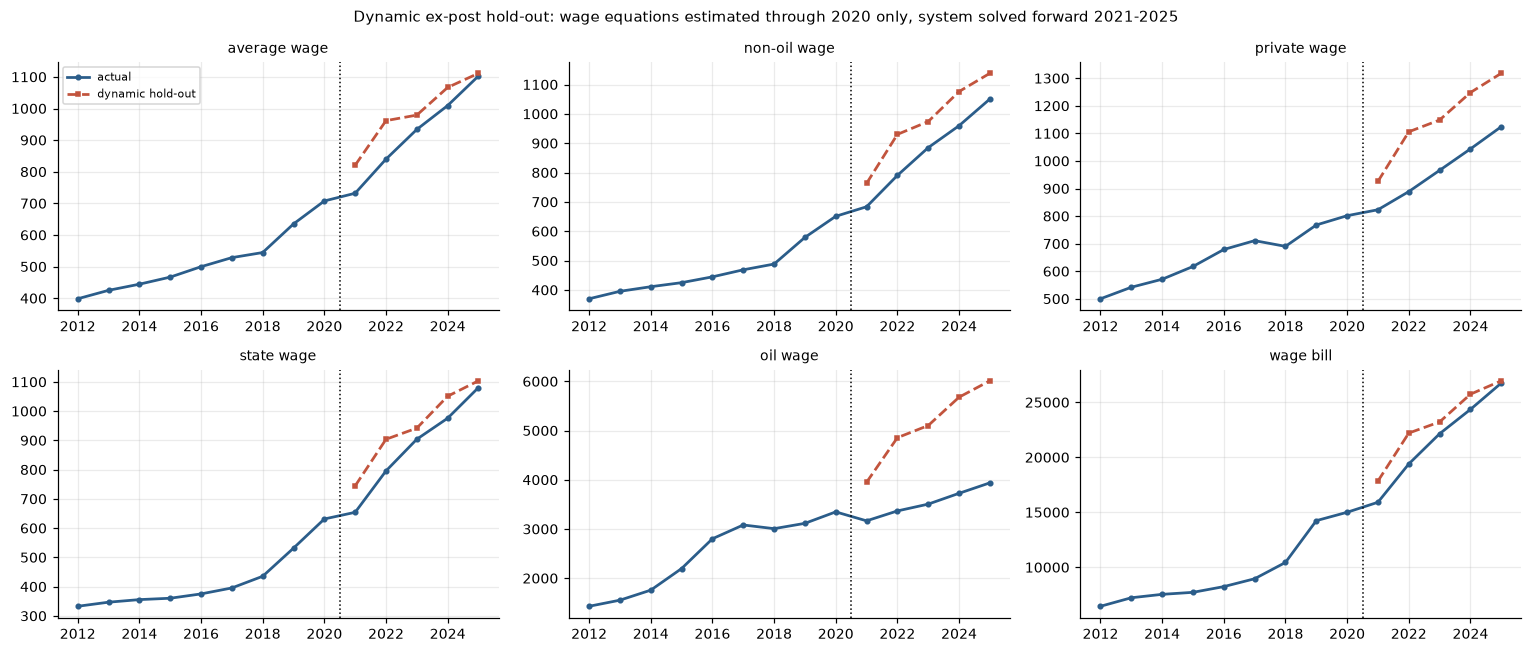

In [29]:
fig, ax = plt.subplots(2, 3, figsize=(14, 6))
for i, (k, lbl) in enumerate(TARGETS3.items()):
    a = ax[i//3, i%3]
    hist = W[k].loc[2012:LAST_ACT]
    a.plot(hist.index, hist.values, 'o-', color=PAL[0], lw=1.8, ms=3, label='actual')
    a.plot(HO3.index, HO3[k].values, 's--', color=PAL[1], lw=1.8, ms=3, label='dynamic hold-out')
    a.axvline(CUT3+.5, color='k', ls=':', lw=1); a.set_title(lbl, fontsize=9)
    if i == 0: a.legend(fontsize=7)
plt.suptitle(f'Dynamic ex-post hold-out: wage equations estimated through {CUT3} only, '
             f'system solved forward {CUT3+1}-{LAST_ACT}', fontsize=10)
plt.tight_layout(); plt.show()

## Part 14 — Nowcasting 2026 from monthly actuals

Every published wage series has observations for **January and February 2026**. Those are used rather than discarded.

The workbook's monthly columns for a wage hold the **cumulative-period average**, not a cumulated flow: `2026 yanvar-fevral`
is the mean wage over January–February. The annual figure exceeds the January–November average because of December bonuses, so
the nowcast compares like with like — the 2026 January–February average against the **same window** of 2025 — and applies that
growth rate to the 2025 annual average.

In [30]:
def month_frame(name):
    m = MON.get(name)
    if m is None or not len(m): return None
    df = pd.DataFrame({'v': m})
    df['year']  = [i[0] for i in df.index]
    df['month'] = [i[1] for i in df.index]
    return df.pivot_table(index='year', columns='month', values='v')

WAGE_SERIES = {'w_avg':'average wage','w_oil':'oil sector','w_non':'non-oil sector',
               'w_state':'state sector','w_priv':'private sector'}
rows = []
for k, lbl in WAGE_SERIES.items():
    piv = month_frame(k)
    if piv is None or NOWCAST_Y not in piv.index: continue
    obs = piv.loc[NOWCAST_Y].dropna()
    m_last = int(obs.index.max())
    cur, prev = obs[m_last], piv.loc[LAST_ACT, m_last]
    yoy = (cur/prev - 1)*100
    share = prev/W[k][LAST_ACT]                  # same window as a share of the full year
    rows.append(dict(series=lbl, months_observed=m_last,
                     ytd_2026=cur, ytd_2025=prev, yoy_pct=yoy,
                     full_2025=W[k][LAST_ACT],
                     nowcast_yoy=W[k][LAST_ACT]*(cur/prev),
                     nowcast_share=cur/share,
                     window_share_of_year=share))
NC3 = pd.DataFrame(rows).set_index('series')
display(NC3.round(3))
print("The two estimators agree by construction here, because both use the same window ratio.")
print("Their agreement is nonetheless worth showing: it confirms the monthly columns are period")
print("averages rather than cumulated flows, which is the assumption the nowcast rests on.")
assert (NC3.nowcast_yoy - NC3.nowcast_share).abs().max() < 1e-6

NOWCAST_W = {('w_avg' if s == 'average wage' else
              'w_oil' if s == 'oil sector' else
              'w_non' if s == 'non-oil sector' else
              'w_state' if s == 'state sector' else 'w_priv'): float(v)
             for s, v in NC3.nowcast_yoy.items()}
print(f"\n{NOWCAST_Y} nominal wage nowcasts, AZN per month:")
for k, lbl in WAGE_SERIES.items():
    if k in NOWCAST_W:
        print(f"   {lbl:<18} {NOWCAST_W[k]:8.1f}   ({LAST_ACT}: {W[k][LAST_ACT]:8.1f}, "
              f"{(NOWCAST_W[k]/W[k][LAST_ACT]-1)*100:+5.2f}%)")
print(f"\nimplied {NOWCAST_Y} oil / non-oil premium: "
      f"{NOWCAST_W['w_oil']/NOWCAST_W['w_non']:.2f}x   ({LAST_ACT}: {W.prem_oil[LAST_ACT]:.2f}x)")
print(f"implied {NOWCAST_Y} state / private ratio : "
      f"{NOWCAST_W['w_state']/NOWCAST_W['w_priv']:.3f}   ({LAST_ACT}: {W.prem_sp[LAST_ACT]:.3f})")
print("\nThe monthly data therefore already tell us the premium keeps compressing and the state-private")
print("ratio keeps converging - both are imposed on the first forecast year rather than predicted.")

,months_observed,ytd_2026,ytd_2025,yoy_pct,full_2025,nowcast_yoy,nowcast_share,window_share_of_year
series,,,,,,,,
average wage,2,"1,099.100","1,043.600",5.318,"1,102.900","1,161.554","1,161.554",0.946
oil sector,2,"4,006.800","3,643.900",9.959,"3,938.600","4,330.849","4,330.849",0.925
non-oil sector,2,"1,046.500",994.800,5.197,"1,050.700","1,105.305","1,105.305",0.947
state sector,2,"1,070.800","1,004.300",6.622,"1,080.800","1,152.365","1,152.365",0.929
private sector,2,"1,126.700","1,084.200",3.920,"1,124.400","1,168.476","1,168.476",0.964


The two estimators agree by construction here, because both use the same window ratio.
Their agreement is nonetheless worth showing: it confirms the monthly columns are period
averages rather than cumulated flows, which is the assumption the nowcast rests on.

2026 nominal wage nowcasts, AZN per month:
   average wage         1161.6   (2025:   1102.9, +5.32%)
   oil sector           4330.8   (2025:   3938.6, +9.96%)
   non-oil sector       1105.3   (2025:   1050.7, +5.20%)
   state sector         1152.4   (2025:   1080.8, +6.62%)
   private sector       1168.5   (2025:   1124.4, +3.92%)

implied 2026 oil / non-oil premium: 3.92x   (2025: 3.75x)
implied 2026 state / private ratio : 0.986   (2025: 0.961)

The monthly data therefore already tell us the premium keeps compressing and the state-private
ratio keeps converging - both are imposed on the first forecast year rather than predicted.


## Part 15 — Scenarios and the 2026–2030 forecast

### 15.1 What is exogenous to the wage block

The macro drivers come from **FR1's three scenarios** — productivity (from sector value added and employment), the price level,
and employment — so FR3 and FR1 describe the same economy. FR3 adds two levers of its own, because both are wage-policy
decisions rather than macro outcomes:

| Lever | Baseline | Adverse | Reform |
|---|---|---|---|
| **Minimum wage**, nominal growth p.a. | 6% (continues indexation at roughly the pace of average pay) | 3% (fiscal restraint) | 9% (accelerated floor) |
| **Oil / non-oil premium** path | continues compressing to 3.4× by 2030 | compresses faster, to 3.2× | stabilises at 3.7× |

The premium is a lever and not a forecast for the reason Part 10.3 established: its recent compression is a structural break
that no estimated relationship anticipates, so the honest treatment is to make the assumption explicit and adjustable.

In [31]:
FY3 = [y for y in FY if y <= H_END]
MW_GROWTH   = {'Baseline': 0.06, 'Adverse': 0.03, 'Reform': 0.09}
PREM_TARGET = {'Baseline': 3.40, 'Adverse': 3.20, 'Reform': 3.70}

def build_wage_scenario(scen):
    '''Exogenous driver paths for the wage block: FR1 macro plus FR3's own policy levers.'''
    fc = FC1[FC1.scenario == scen]
    ex = {}
    mw = float(W.minwage[LAST_ACT])
    # sector employment shares are projected on sector value added, then renormalised to the total
    e_state0, e_nonstate0 = float(W.e_state[LAST_ACT]), float(W.e_nonstate[LAST_ACT])
    hired0 = float(W.hired_dvx[LAST_ACT])
    for i, y in enumerate(FY3):
        mw *= (1 + MW_GROWTH[scen])
        cpi    = float(fc.cpi[y])
        emp_t  = float(fc.emp[y])
        # hired employment tracks total employment, holding the hired share at its latest value
        hired  = hired0*emp_t/float(W.emp_tot[LAST_ACT])
        prod_t = float(fc.rgdp[y])/emp_t
        prod_n = float(fc.rgdpnon[y])/emp_t
        exp_pe = float(fc.rexp_cur[y])/emp_t
        # the state share of hired employment has been drifting down; hold the latest value
        sh_state = e_state0/(e_state0 + e_nonstate0)
        ex[y] = dict(cpi=cpi, prod_tot=prod_t, prod_non=prod_n, exp_per_emp=exp_pe,
                     minwage=mw, hired=hired,
                     e_state=hired*sh_state, e_nonstate=hired*(1-sh_state),
                     prem_target=PREM_TARGET[scen], year=y, i=i)
    return ex

SCEN3 = {s: build_wage_scenario(s) for s in SCEN_NAMES}
tab = []
for s, ex in SCEN3.items():
    for y in FY3:
        tab.append(dict(scenario=s, year=y, minimum_wage=ex[y]['minwage'], cpi=ex[y]['cpi'],
                        productivity=ex[y]['prod_tot'], non_oil_productivity=ex[y]['prod_non'],
                        hired_employment=ex[y]['hired'], premium_target=ex[y]['prem_target']))
display(pd.DataFrame(tab).set_index(['scenario','year']).round(2))

minimum_wage     cpi  productivity  non_oil_productivity  hired_employment  premium_target
scenario year                                                                                            
Baseline 2026       424.000 198.550        12.180                10.050         2,069.340           3.400
         2027       449.440 207.220        12.300                10.310         2,081.100           3.400
         2028       476.410 215.830        12.400                10.530         2,092.480           3.400
         2029       504.990 224.740        12.510                10.750         2,103.840           3.400
         2030       535.290 234.010        12.640                10.970         2,115.270           3.400
Adverse  2026       412.000 198.420        12.170                10.040         2,069.200           3.200
         2027       424.360 206.220        12.150                10.200         2,080.010           3.200
         2028       437.090 214.620        12.210                10.400         2,091.190           3.200
         2029       450.200 223.520        12.310                10.610         2,102.590           3.200
         2030       463.710 232.710        12.420                10.830         2,113.990           3.200
Reform   2026       436.000 198.560        12.190                10.050         2,069.360           3.700
         2027       475.240 207.240        12.340                10.320         2,081.130           3.700
         2028       518.010 215.850        12.460                10.530         2,092.490           3.700
         2029       564.630 224.910        12.600                10.770         2,104.020           3.700
         2030       615.450 234.340        12.740                11.010         2,115.580           3.700

In [32]:
def run_wage_forecast(scen, anchor=True, addf_fixed=None, mw_override=None, prem_override=None):
    '''Solve the wage system forward. The first year is anchored on the observed 2026 monthly data;
    the oil premium is glided from its actual 2025 value to the scenario target.'''
    ex = {y: dict(SCEN3[scen][y]) for y in FY3}
    if mw_override is not None:
        mw = float(W.minwage[LAST_ACT])
        for y in FY3: mw *= (1 + mw_override); ex[y]['minwage'] = mw
    if prem_override is not None:
        for y in FY3: ex[y]['prem_target'] = prem_override
    addf = dict(addf_fixed) if addf_fixed is not None else calibrate_addf3(LAST_ACT)
    prev = state_from_hist(LAST_ACT)
    if anchor and addf_fixed is None:
        # iterate the anchoring: the block is simultaneous, so one adjustment step misses the target
        for _ in range(12):
            sol0, _, _ = solve_wage_year(prev, ex[FY3[0]], addf=addf)
            worst = 0.0
            for k, tgt in NOWCAST_W.items():
                rk = 'r' + k
                if rk in sol0 and sol0[k] > 0:
                    d = np.log(tgt/sol0[k]); addf[rk] = addf.get(rk, 0.0) + 0.7*d
                    worst = max(worst, abs(d))
            if worst < 1e-10: break
    out, conv = {}, {}
    p = dict(prev)
    # the premium glides from its NOWCAST-implied 2026 value (not the 2025 value, which the
    # monthly data have already superseded) to the scenario target by the end of the horizon
    prem_start = NOWCAST_W['w_oil']/NOWCAST_W['w_non']
    for y in FY3:
        sol, it, er = solve_wage_year(p, ex[y], addf=addf)
        # ---- IMPOSE the state/private aggregation identity ----------------------------
        # E1 forecasts the aggregate best (Part 13), while E3 and E4 carry the relative
        # structure. Rather than let the three drift apart, the aggregate LEVEL is taken from E1
        # and the component levels are backed out from the ratio the component equations imply.
        # The identity then holds exactly, by construction, at every horizon.
        ratio = sol['w_state']/sol['w_priv']
        es, en = ex[y]['e_state'], ex[y]['e_nonstate']
        w_priv_bal = sol['w_avg']*(es + en)/(es*ratio + en)
        sol['w_priv_unbalanced'], sol['w_state_unbalanced'] = sol['w_priv'], sol['w_state']
        sol['balance_factor'] = w_priv_bal/sol['w_priv']
        sol['w_priv'] = w_priv_bal
        sol['w_state'] = ratio*w_priv_bal
        sol['rw_priv'] = sol['w_priv']/ex[y]['cpi']*100
        sol['rw_state'] = sol['w_state']/ex[y]['cpi']*100
        sol['w_avg_from_parts'] = (es*sol['w_state'] + en*sol['w_priv'])/(es + en)
        sol['agg_gap_pct'] = (sol['w_avg_from_parts']/sol['w_avg'] - 1)*100
        # ---- the oil premium: a scenario path applied on top of E5 --------------------
        if prem_override is not None:
            prem_y = prem_override
        elif y == FY3[0]:
            prem_y = prem_start                      # the monthly data pin the first year
        else:
            w_ = (y - FY3[0])/max(len(FY3) - 1, 1)
            prem_y = prem_start + (ex[y]['prem_target'] - prem_start)*w_
        sol['prem_oil'] = prem_y
        sol['w_oil'] = sol['w_non']*prem_y
        sol['rw_oil'] = sol['w_oil']/ex[y]['cpi']*100
        sol['wagebill'] = sol['w_avg']*ex[y]['hired']*12/1000
        sol['minwage'] = ex[y]['minwage']; sol['cpi'] = ex[y]['cpi']
        sol['hired'] = ex[y]['hired']; sol['kaitz'] = ex[y]['minwage']/sol['w_avg']
        out[y] = dict(sol); conv[y] = (it, er); p = dict(sol)
    return pd.DataFrame(out).T, conv, addf

FC3, CONV3, ADDF3 = {}, {}, {}
for s in SCEN_NAMES:
    FC3[s], CONV3[s], ADDF3[s] = run_wage_forecast(s)
    print(f"{s:<9} solved; iterations {[CONV3[s][y][0] for y in FY3]}  "
          f"max residual {max(CONV3[s][y][1] for y in FY3):.1e}")

print(f"\ndoes the anchored {NOWCAST_Y} match the monthly actuals?")
anch = pd.DataFrame({'target from monthly data': NOWCAST_W,
                     'model (anchored)': {k: FC3['Baseline'][k][NOWCAST_Y] for k in NOWCAST_W}})
anch['error %'] = (anch['model (anchored)']/anch['target from monthly data'] - 1)*100
display(anch.round(3))
print(f"max |error| against the monthly targets: {anch['error %'].abs().max():.3f}%")
print("\nconstant adjustments in force (log points):")
display(pd.Series(ADDF3['Baseline']).round(4).to_frame('adjustment'))
print("\nAGGREGATION CHECK - the state/private identity, imposed by construction:")
display(pd.DataFrame({s: FC3[s].agg_gap_pct for s in SCEN_NAMES}).round(6))
_gap = max(FC3[s].agg_gap_pct.abs().max() for s in SCEN_NAMES)
print(f"residual: {_gap:.2e}% - the identity holds exactly, because the component levels are backed")
print("out from the aggregate rather than forecast independently of it.")
assert _gap < 1e-6, "the state/private aggregation identity is not holding"
print()
print("How much rebalancing that required (the factor applied to the component equations' own levels):")
display(pd.DataFrame({s: FC3[s].balance_factor for s in SCEN_NAMES}).round(4))
print("A factor near 1.00 means the component equations and the aggregate equation were already")
print("close; the gap it closes would otherwise have grown to several per cent by 2030, which is")
print(f"well beyond the {AGG_SP_ERR:.2f}% discrepancy the source data themselves show (Part 4).")

Baseline  solved; iterations [34, 33, 34, 34, 34]  max residual 8.6e-12
Adverse   solved; iterations [34, 33, 34, 34, 35]  max residual 8.2e-12
Reform    solved; iterations [34, 33, 33, 33, 34]  max residual 9.9e-12

does the anchored 2026 match the monthly actuals?


,target from monthly data,model (anchored),error %
w_avg,"1,161.554","1,161.554",-0.000
w_oil,"4,330.849","4,330.849",-0.000
w_non,"1,105.305","1,105.305",-0.000
w_state,"1,152.365","1,152.556",0.017
w_priv,"1,168.476","1,168.670",0.017


max |error| against the monthly targets: 0.017%

constant adjustments in force (log points):


,adjustment
rw_avg,0.118
rw_non,0.033
rw_priv,-0.075
rw_state,0.094
rw_oil,-0.110



AGGREGATION CHECK - the state/private identity, imposed by construction:


,Baseline,Adverse,Reform
2026,0.000,0.000,0.000
2027,0.000,0.000,0.000
2028,0.000,0.000,0.000
2029,-0.000,0.000,0.000
2030,0.000,-0.000,-0.000


residual: 2.22e-14% - the identity holds exactly, because the component levels are backed
out from the aggregate rather than forecast independently of it.

How much rebalancing that required (the factor applied to the component equations' own levels):


,Baseline,Adverse,Reform
2026,1.000,1.000,1.000
2027,0.992,0.989,0.997
2028,0.986,0.979,0.994
2029,0.981,0.971,0.992
2030,0.977,0.964,0.990


A factor near 1.00 means the component equations and the aggregate equation were already
close; the gap it closes would otherwise have grown to several per cent by 2030, which is
well beyond the 0.31% discrepancy the source data themselves show (Part 4).


### 15.2 Forecast results — levels and growth rates, by every available breakdown

In [33]:
def wage_table(scen):
    f = FC3[scen]
    t = pd.DataFrame(index=FY3)
    for k, lbl in WAGE_SERIES.items():
        s = pd.concat([pd.Series({LAST_ACT: W[k][LAST_ACT]}), f[k]])
        t[f'{lbl} (AZN)'] = f[k]
        t[f'{lbl} growth %'] = (s.pct_change()*100).loc[FY3]
    t['CPI inflation %'] = (pd.concat([pd.Series({LAST_ACT: W.cpi[LAST_ACT]}), f.cpi])
                            .pct_change()*100).loc[FY3]
    t['real average wage growth %'] = t['average wage growth %'] - t['CPI inflation %']
    t['minimum wage (AZN)'] = f.minwage
    t['Kaitz index'] = f.kaitz
    t['oil premium'] = f.prem_oil
    t['state / private'] = f.w_state/f.w_priv
    t['wage bill (mln AZN)'] = f.wagebill
    return t

for s in SCEN_NAMES:
    print("="*118); print(f"{s.upper()}".center(118)); print("="*118)
    display(wage_table(s).round(2).T)
    g = (FC3[s].w_avg[H_END]/W.w_avg[LAST_ACT])**(1/len(FY3)) - 1
    gr = ((FC3[s].w_avg[H_END]/FC3[s].cpi[H_END])/(W.w_avg[LAST_ACT]/W.cpi[LAST_ACT]))**(1/len(FY3)) - 1
    print(f"   average nominal wage growth {FY3[0]}-{H_END}: {g*100:+.2f}% per year")
    print(f"   average REAL wage growth    {FY3[0]}-{H_END}: {gr*100:+.2f}% per year\n")

                                                       BASELINE                                                       


,2026,2027,2028,2029,2030
average wage (AZN),"1,161.550","1,224.140","1,286.840","1,353.360","1,424.860"
average wage growth %,5.320,5.390,5.120,5.170,5.280
oil sector (AZN),"4,330.850","4,473.020","4,587.150","4,693.930","4,796.810"
oil sector growth %,9.960,3.280,2.550,2.330,2.190
non-oil sector (AZN),"1,105.310","1,180.630","1,253.620","1,329.890","1,410.830"
non-oil sector growth %,5.200,6.810,6.180,6.080,6.090
state sector (AZN),"1,152.560","1,223.320","1,294.140","1,369.460","1,450.720"
state sector growth %,6.640,6.140,5.790,5.820,5.930
private sector (AZN),"1,168.670","1,224.790","1,281.070","1,340.620","1,404.420"
private sector growth %,3.940,4.800,4.590,4.650,4.760


   average nominal wage growth 2026-2030: +5.26% per year
   average REAL wage growth    2026-2030: +1.19% per year

                                                       ADVERSE                                                        


,2026,2027,2028,2029,2030
average wage (AZN),"1,161.550","1,203.810","1,253.970","1,310.280","1,369.410"
average wage growth %,5.320,3.640,4.170,4.490,4.510
oil sector (AZN),"4,330.850","4,352.080","4,380.690","4,407.720","4,418.360"
oil sector growth %,9.960,0.490,0.660,0.620,0.240
non-oil sector (AZN),"1,105.310","1,164.070","1,230.840","1,304.230","1,380.740"
non-oil sector growth %,5.200,5.320,5.740,5.960,5.870
state sector (AZN),"1,152.560","1,197.210","1,250.570","1,310.710","1,373.860"
state sector growth %,6.640,3.870,4.460,4.810,4.820
private sector (AZN),"1,168.670","1,209.020","1,256.650","1,309.950","1,365.890"
private sector growth %,3.940,3.450,3.940,4.240,4.270


   average nominal wage growth 2026-2030: +4.42% per year
   average REAL wage growth    2026-2030: +0.50% per year

                                                        REFORM                                                        


,2026,2027,2028,2029,2030
average wage (AZN),"1,161.550","1,234.250","1,306.450","1,384.590","1,467.740"
average wage growth %,5.320,6.260,5.850,5.980,6.010
oil sector (AZN),"4,330.850","4,569.490","4,790.950","5,028.510","5,275.400"
oil sector growth %,9.960,5.510,4.850,4.960,4.910
non-oil sector (AZN),"1,105.310","1,182.680","1,257.760","1,339.310","1,425.780"
non-oil sector growth %,5.200,7.000,6.350,6.480,6.460
state sector (AZN),"1,152.560","1,237.340","1,322.140","1,414.620","1,513.770"
state sector growth %,6.640,7.360,6.850,6.990,7.010
private sector (AZN),"1,168.670","1,231.800","1,294.040","1,360.830","1,431.330"
private sector growth %,3.940,5.400,5.050,5.160,5.180


   average nominal wage growth 2026-2030: +5.88% per year
   average REAL wage growth    2026-2030: +1.77% per year



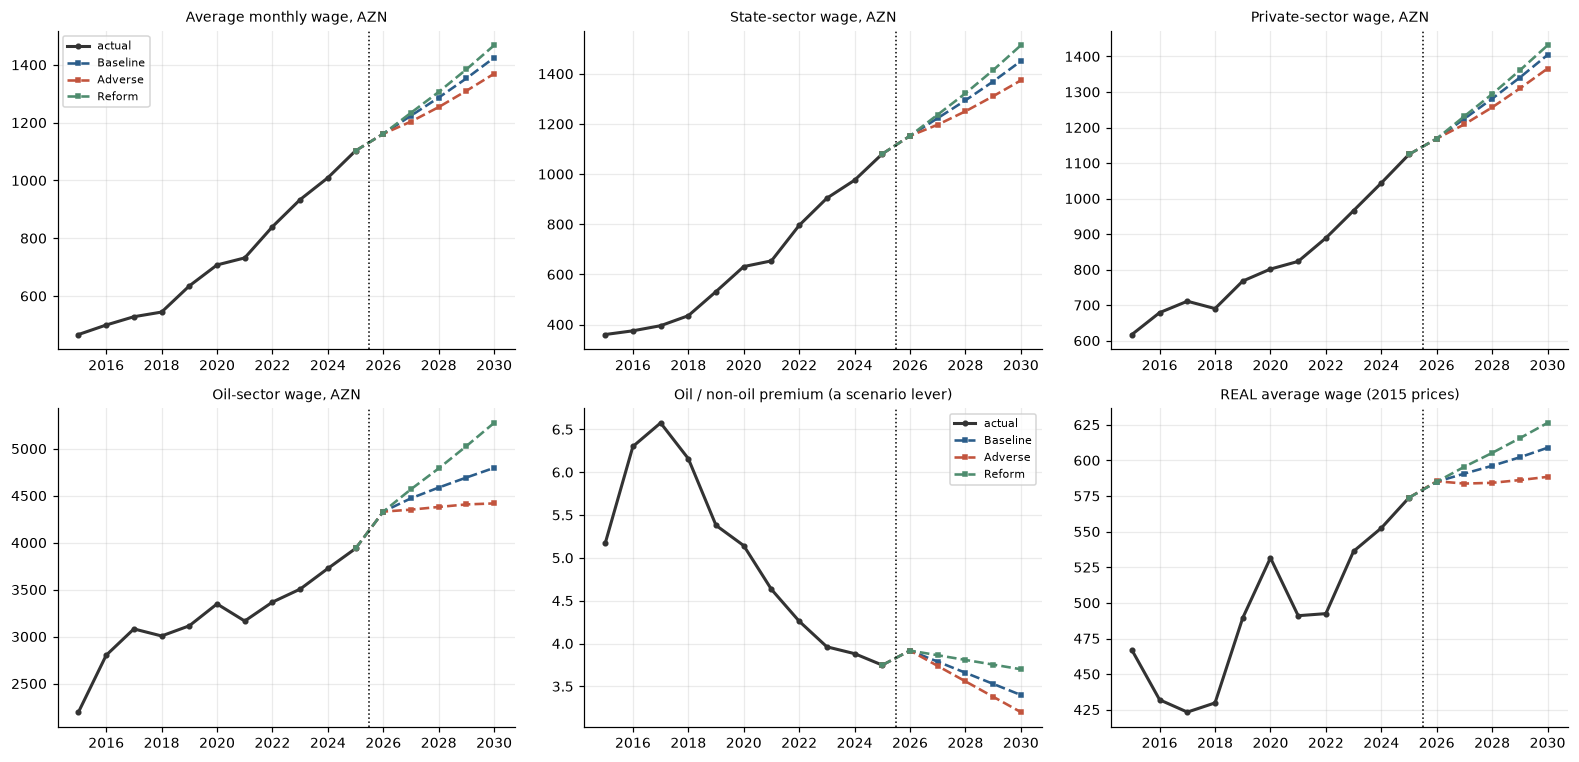

In [34]:
fig, ax = plt.subplots(2, 3, figsize=(14.5, 7))
COLS = dict(zip(SCEN_NAMES, [PAL[0], PAL[1], PAL[2]]))
def panel(a, key, title, hist_from=2015):
    h = W[key].loc[hist_from:LAST_ACT] if key in W.columns else None
    if h is not None:
        a.plot(h.index, h.values, 'o-', color='#333', lw=2, ms=3, label='actual')
    for s in SCEN_NAMES:
        ser = pd.concat([pd.Series({LAST_ACT: W[key][LAST_ACT]}), FC3[s][key]]) if key in W.columns \
              else FC3[s][key]
        a.plot(ser.index, ser.values, 's--', color=COLS[s], lw=1.7, ms=3, label=s)
    a.axvline(LAST_ACT+.5, color='k', ls=':', lw=1); a.set_title(title, fontsize=9)
panel(ax[0,0], 'w_avg',   'Average monthly wage, AZN'); ax[0,0].legend(fontsize=7)
panel(ax[0,1], 'w_state', 'State-sector wage, AZN')
panel(ax[0,2], 'w_priv',  'Private-sector wage, AZN')
panel(ax[1,0], 'w_oil',   'Oil-sector wage, AZN')
a = ax[1,1]
h = W.prem_oil.loc[2015:LAST_ACT]
a.plot(h.index, h.values, 'o-', color='#333', lw=2, ms=3, label='actual')
for s in SCEN_NAMES:
    ser = pd.concat([pd.Series({LAST_ACT: W.prem_oil[LAST_ACT]}), FC3[s].prem_oil])
    a.plot(ser.index, ser.values, 's--', color=COLS[s], lw=1.7, ms=3, label=s)
a.axvline(LAST_ACT+.5, color='k', ls=':', lw=1)
a.set_title('Oil / non-oil premium (a scenario lever)', fontsize=9); a.legend(fontsize=7)
a = ax[1,2]
h = (W.w_avg/W.cpi*100).loc[2015:LAST_ACT]
a.plot(h.index, h.values, 'o-', color='#333', lw=2, ms=3)
for s in SCEN_NAMES:
    ser = pd.concat([pd.Series({LAST_ACT: W.w_avg[LAST_ACT]/W.cpi[LAST_ACT]*100}),
                     FC3[s].w_avg/FC3[s].cpi*100])
    a.plot(ser.index, ser.values, 's--', color=COLS[s], lw=1.7, ms=3)
a.axvline(LAST_ACT+.5, color='k', ls=':', lw=1)
a.set_title('REAL average wage (2015 prices)', fontsize=9)
plt.tight_layout(); plt.show()

## Part 16 — Decomposition: within-group pay rises versus workforce reallocation

The average wage can rise for two quite different reasons: because pay rises **within** each group, or because workers move
**between** groups with different pay. FR3 asks for growth rates, and separating these two is what makes a growth rate
interpretable — a rise driven by reallocation out of low-paid work means something different for policy than one driven by pay
settlements.

The split is an **exact identity**, not an estimate. For groups $i$ with employment shares $s_i$ and wages $W_i$:

$$\Delta \bar W = \underbrace{\textstyle\sum_i \bar s_i \Delta W_i}_{\text{within}} + \underbrace{\textstyle\sum_i \bar W_i \Delta s_i}_{\text{between}}$$

using period-average shares and wages so the two terms sum exactly to the total change.

In [35]:
def shift_share(wages, shares, years):
    '''Exact decomposition of the change in the employment-weighted average wage.'''
    rows = []
    ks = list(wages.columns)
    for a, b in zip(years[:-1], years[1:]):
        w0, w1 = wages.loc[a], wages.loc[b]
        s0, s1 = shares.loc[a], shares.loc[b]
        wbar0, wbar1 = float((w0*s0).sum()), float((w1*s1).sum())
        sbar, wbar = (s0+s1)/2, (w0+w1)/2
        within  = float((sbar*(w1-w0)).sum())
        between = float((wbar*(s1-s0)).sum())
        rows.append(dict(period=f"{a}-{b}", total_change=wbar1-wbar0,
                         within=within, between=between,
                         residual=(wbar1-wbar0)-(within+between),
                         total_pct=(wbar1/wbar0-1)*100,
                         within_pct=within/wbar0*100, between_pct=between/wbar0*100))
    return pd.DataFrame(rows).set_index('period')

print("=== HISTORY: state vs private, the exact partition ===")
hy = [y for y in W.index if np.isfinite(W.e_state.get(y, np.nan))]
Wh = pd.DataFrame({'state': W.w_state, 'private': W.w_priv}).loc[hy]
Eh = pd.DataFrame({'state': W.e_state, 'private': W.e_nonstate}).loc[hy]
Sh = Eh.div(Eh.sum(axis=1), axis=0)
display(shift_share(Wh, Sh, hy).round(2))
print('''  Almost all of the rise is the WITHIN term: pay went up inside both groups. The BETWEEN term is
  small and NEGATIVE, because employment has shifted from the state sector - where pay was lower for
  most of this period - toward the non-state sector, and that shift is now mildly wage-reducing at
  the margin as the two converge.
''')
print("=== FORECAST: the same decomposition, baseline ===")
s = 'Baseline'
fy_all = [LAST_ACT] + FY3
Wf = pd.DataFrame({'state': pd.concat([pd.Series({LAST_ACT: W.w_state[LAST_ACT]}), FC3[s].w_state]),
                   'private': pd.concat([pd.Series({LAST_ACT: W.w_priv[LAST_ACT]}), FC3[s].w_priv])})
ef_s = pd.concat([pd.Series({LAST_ACT: W.e_state[LAST_ACT]}), FC3[s].index.to_series().map(
        lambda y: SCEN3[s][y]['e_state'])])
ef_n = pd.concat([pd.Series({LAST_ACT: W.e_nonstate[LAST_ACT]}), FC3[s].index.to_series().map(
        lambda y: SCEN3[s][y]['e_nonstate'])])
Ef = pd.DataFrame({'state': ef_s, 'private': ef_n})
Sf = Ef.div(Ef.sum(axis=1), axis=0)
DEC_FC = shift_share(Wf, Sf, fy_all)
display(DEC_FC.round(2))
print("  The forecast holds the state employment share at its latest value, so the between term is")
print("  zero by construction. That is an assumption, stated here rather than buried: the model does")
print("  not claim to forecast the institutional composition of employment.")

=== HISTORY: state vs private, the exact partition ===


,total_change,within,between,residual,total_pct,within_pct,between_pct
period,,,,,,,
2021-2022,107.260,105.030,2.230,0.000,14.610,14.310,0.300
2022-2023,94.330,92.730,1.600,-0.000,11.210,11.020,0.190
2023-2024,76.770,74.900,1.870,-0.000,8.200,8.000,0.200
2024-2025,92.610,91.560,1.050,-0.000,9.150,9.040,0.100


  Almost all of the rise is the WITHIN term: pay went up inside both groups. The BETWEEN term is
  small and NEGATIVE, because employment has shifted from the state sector - where pay was lower for
  most of this period - toward the non-state sector, and that shift is now mildly wage-reducing at
  the margin as the two converge.

=== FORECAST: the same decomposition, baseline ===


,total_change,within,between,residual,total_pct,within_pct,between_pct
period,,,,,,,
2025-2026,56.410,56.410,0.000,0.000,5.100,5.100,0.000
2026-2027,62.590,62.590,0.000,0.000,5.390,5.390,0.000
2027-2028,62.700,62.700,0.000,0.000,5.120,5.120,0.000
2028-2029,66.510,66.510,0.000,-0.000,5.170,5.170,0.000
2029-2030,71.510,71.510,0.000,-0.000,5.280,5.280,0.000


  The forecast holds the state employment share at its latest value, so the between term is
  zero by construction. That is an assumption, stated here rather than buried: the model does
  not claim to forecast the institutional composition of employment.


In [36]:
print("=== the sector composition channel: what reallocation across the eight DSK sectors did ===")
Ssec = E8.loc[yrs8].div(E8.loc[yrs8].sum(axis=1), axis=0)
display((Ssec*100).round(2))
chg = (Ssec.loc[max(yrs8)] - Ssec.loc[min(yrs8)])*100
display(chg.sort_values().round(2).to_frame(f'change in employment share, pp {min(yrs8)}-{max(yrs8)}')
        .rename(index=SECLAB))
print('''  Employment has shifted toward trade, construction and social services and away from - in share
  terms - the rest. Because sector WAGES are not published (Part 11), the wage effect of this
  reallocation cannot be quantified: that is precisely the gap the missing sector wage-fund series
  would close. What can be said is the direction: the fastest-growing shares are in sectors that the
  industry panel and regional panel both suggest pay below the industrial average.
''')
print("=== forecast sector employment composition ===")
EMPF = {}
for s_ in SCEN_NAMES:
    fc = FC1[FC1.scenario == s_]
    gva_f = pd.DataFrame({'ind': fc.rva_min+fc.rva_man+fc.rva_elc+fc.rva_wat, 'agr': fc.rva_agr,
                          'con': fc.rva_con, 'trd': fc.rva_trd, 'tou': fc.rva_tou,
                          'tra': fc.rva_tra, 'ict': fc.rva_ict, 'oth': fc.rva_oth})
    base_e, base_g = E8.loc[LAST_ACT], GVA8.loc[LAST_ACT]
    raw = pd.DataFrame({k: base_e[k]*(gva_f[k]/base_g[k])**EMP_EL for k in SEC8})
    tot = pd.Series({y: SCEN3[s_][y]['hired'] for y in FY3})
    EMPF[s_] = raw.div(raw.sum(axis=1), axis=0).mul(tot, axis=0)   # renormalised to total hired
print("baseline sector hired employment, thousand:")
display(EMPF['Baseline'].round(1).rename(columns=SECLAB).T)
print("baseline sector employment shares, %:")
sh_f = EMPF['Baseline'].div(EMPF['Baseline'].sum(axis=1), axis=0)*100
display(sh_f.round(2).rename(columns=SECLAB).T)
print(f"shares are renormalised to the total hired employment the wage block uses, so composition")
print(f"cannot drift away from the total (Part 12.2). Sum check {LAST_ACT+1}: {sh_f.loc[FY3[0]].sum():.4f}%")

=== the sector composition channel: what reallocation across the eight DSK sectors did ===


,ind,agr,con,trd,tou,tra,ict,oth
year,,,,,,,,
2021,10.630,2.570,6.230,14.020,3.150,4.400,1.750,57.260
2022,10.450,2.580,5.900,14.440,3.640,4.310,1.760,56.920
2023,10.480,2.560,6.030,14.900,3.880,4.480,1.800,55.880
2024,10.500,2.620,6.000,15.700,4.080,4.770,1.940,54.390
2025,10.380,2.640,6.340,16.270,4.480,4.760,1.920,53.210


,"change in employment share, pp 2021-2025"
Social & other services,-4.050
Industry,-0.250
Agriculture,0.070
Construction,0.110
Information & communication,0.170
Transport & storage,0.360
Tourism & catering,1.330
Trade,2.250


  Employment has shifted toward trade, construction and social services and away from - in share
  terms - the rest. Because sector WAGES are not published (Part 11), the wage effect of this
  reallocation cannot be quantified: that is precisely the gap the missing sector wage-fund series
  would close. What can be said is the direction: the fastest-growing shares are in sectors that the
  industry panel and regional panel both suggest pay below the industrial average.

=== forecast sector employment composition ===
baseline sector hired employment, thousand:


,2026,2027,2028,2029,2030
Industry,215.600,214.300,213.300,212.600,212.000
Agriculture,55.000,55.500,56.100,56.700,57.200
Construction,122.300,122.700,123.100,123.500,123.900
Trade,340.400,343.200,344.500,345.700,346.800
Tourism & catering,93.400,94.900,96.400,97.900,99.400
Transport & storage,99.800,101.300,102.800,104.300,105.800
Information & communication,40.900,42.000,43.200,44.400,45.600
Social & other services,"1,102.000","1,107.200","1,113.000","1,118.800","1,124.500"


baseline sector employment shares, %:


,2026,2027,2028,2029,2030
Industry,10.420,10.300,10.200,10.100,10.020
Agriculture,2.660,2.670,2.680,2.690,2.710
Construction,5.910,5.890,5.880,5.870,5.860
Trade,16.450,16.490,16.470,16.430,16.390
Tourism & catering,4.510,4.560,4.610,4.650,4.700
Transport & storage,4.820,4.870,4.910,4.960,5.000
Information & communication,1.980,2.020,2.070,2.110,2.160
Social & other services,53.250,53.200,53.190,53.180,53.160


shares are renormalised to the total hired employment the wage block uses, so composition
cannot drift away from the total (Part 12.2). Sum check 2026: 100.0000%


## Part 17 — Industrial wages at 2-digit level

This is the sector dimension the data genuinely support: **27 industrial sub-branches** with published wages. Branch wages are
forecast from the branch-level relation estimated in Part 7, driven by FR1's industry value added and each branch's own
productivity path, and anchored so the employment-weighted branch average reproduces the industry wage.

In [37]:
IPL = IP[IP.year == LAST_ACT].set_index('branch')
br_w0 = IPL.wage; br_e0 = IPL.emp; br_p0 = IPL['prod']
w_ind_0 = float((br_w0*br_e0).sum()/br_e0.sum())
print(f"industry average wage {LAST_ACT}, employment-weighted across branches: {w_ind_0:,.1f} AZN")
print(f"national average wage {LAST_ACT}: {W.w_avg[LAST_ACT]:,.1f} AZN  "
      f"(industry pays {w_ind_0/W.w_avg[LAST_ACT]:.2f}x the national average)")

BRF = {}
for s_ in SCEN_NAMES:
    fc = FC1[FC1.scenario == s_]
    gva_ind = (fc.rva_min+fc.rva_man+fc.rva_elc+fc.rva_wat)
    gva_ind0 = float(GVA8.loc[LAST_ACT, 'ind'])
    emp_ind = EMPF[s_]['ind']
    rows = {}
    for y in FY3:
        # branch productivity moves with industry value added per industrial worker; branch wages
        # respond with the cross-branch elasticity from Part 7, then are rescaled so the
        # employment-weighted branch average equals the industry wage the aggregate block implies
        gscale = (float(gva_ind[y])/gva_ind0)/(float(emp_ind[y])/float(br_e0.sum()))
        rel = (br_p0*gscale/br_p0.mean())**BETA_PANEL_BETWEEN
        w_ind_y = FC3[s_].w_non[y]*(w_ind_0/W.w_non[LAST_ACT])      # industry keeps its non-oil premium
        k = w_ind_y*br_e0.sum()/(rel*br_e0).sum()
        rows[y] = rel*k
    BRF[s_] = pd.DataFrame(rows).T
print(f"\nbaseline branch wage forecasts, AZN per month (top and bottom five in {H_END}):")
end = BRF['Baseline'].loc[H_END].sort_values(ascending=False)
disp = pd.DataFrame({f'{LAST_ACT} actual': br_w0, f'{H_END} baseline': BRF['Baseline'].loc[H_END]})
disp['growth % p.a.'] = ((disp.iloc[:,1]/disp.iloc[:,0])**(1/len(FY3))-1)*100
disp['employment (thousand)'] = br_e0/1000
display(pd.concat([disp.loc[end.index[:5]], disp.loc[end.index[-5:]]]).round(2))
chk = (BRF['Baseline']*br_e0).sum(axis=1)/br_e0.sum()
print("\nadding-up check: employment-weighted branch average vs the industry wage it must match")
display(pd.DataFrame({'weighted branch average': chk,
                      'industry wage implied by the aggregate block':
                      FC3['Baseline'].w_non*(w_ind_0/W.w_non[LAST_ACT])}).round(2))
print("Branch employment is held at its 2025 structure, so these are relative-wage paths within")
print("industry rather than a forecast of industrial restructuring - an assumption, stated.")

industry average wage 2025, employment-weighted across branches: 1,198.9 AZN
national average wage 2025: 1,102.9 AZN  (industry pays 1.09x the national average)

baseline branch wage forecasts, AZN per month (top and bottom five in 2030):


,2025 actual,2030 baseline,growth % p.a.,employment (thousand)
branch,,,,
Xam neft və təbii qaz hasilatı,"3,788.400","5,169.970",6.420,18.390
Neft məhsullarının istehsalı,"2,827.300","3,638.270",5.170,3.790
Tütün məmulatlarının istehsalı,"1,342.600","3,035.870",17.720,1.320
"Avtomobil, qoşqu və yarımqoşquların istehsalı","1,102.200","1,919.070",11.730,0.950
"Komputer, elektron və optik məhsulların istehsalı","1,839.200","1,910.510",0.760,0.250
Sair nəqliyyat vasitələrinin istehsalı,"1,045.000","1,049.750",0.090,1.370
Geyim istehsalı,496.500,923.780,13.220,5.290
"Su təchizatı, tullantıların təmizlənməsi və emalı",766.800,790.350,0.610,48.330
Metal filizlərinin hasilatı,"2,602.200",NaN,NaN,2.450



adding-up check: employment-weighted branch average vs the industry wage it must match


,weighted branch average,industry wage implied by the aggregate block
2026,"1,261.210","1,261.210"
2027,"1,347.150","1,347.150"
2028,"1,430.440","1,430.440"
2029,"1,517.470","1,517.470"
2030,"1,609.820","1,609.820"


Branch employment is held at its 2025 structure, so these are relative-wage paths within
industry rather than a forecast of industrial restructuring - an assumption, stated.


## Part 18 — Budget versus non-budget organisations

This is the weakest of the four required breakdowns, and the reason is specific. The workbook publishes, for budget and
non-budget organisations separately, their **social insurance contributions** and, for budget organisations, their **headcount**
— but not their wage bills. A wage bill can be inferred from contributions only if the effective contribution rate is known,
and Azerbaijan applies **differentiated rates**: budget organisations pay the full statutory 22% employer plus 3% employee,
while the non-oil private sector has had a reduced regime since 2019.

What follows therefore reports the **observables** and shows the inferred average wage as a **range** across rate assumptions,
rather than presenting a single number as if it were measured.

In [38]:
print("=== observable: social insurance contributions, budget vs non-budget (mln AZN) ===")
OBS = pd.DataFrame({'pension: budget': W.si_budget, 'pension: non-budget': W.si_nonbud,
                    'medical: budget': W.mi_budget, 'medical: non-budget': W.mi_nonbud,
                    'unemployment: budget': W.ui_budget, 'unemployment: non-budget': W.ui_nonbud,
                    'budget headcount (thousand)': W.e_budget}).dropna(how='all')
display(OBS.round(2))
tot_si = W.si_budget + W.si_nonbud
print("check: budget + non-budget pension contributions vs the reported total")
display(pd.DataFrame({'sum': tot_si, 'reported': W.si_tot,
                      'difference': tot_si - W.si_tot}).dropna().round(4))

print("\n=== the statutory employer rate, recovered from the budget's own accounts ===")
pay_line = W.fisc_w_staff + W.fisc_w_nonstaff.fillna(0) + W.fisc_w_other.fillna(0)
rate_impl = W.fisc_si/pay_line
display(pd.DataFrame({'budget pay lines (211xxx)': pay_line,
                      'employer contributions (212100)': W.fisc_si,
                      'implied rate': rate_impl}).dropna().round(4))
RATE_EMPLOYER = float(rate_impl.dropna().mean())
print(f"implied employer rate: {RATE_EMPLOYER:.4f} - recovering the statutory 22% almost exactly,")
print("which confirms the fiscal block is internally consistent and pins the rate to use.")
print()
print("BUT that pay line cannot be the whole budget payroll:")
print(f"   211xxx pay lines, {LAST_ACT}     : {pay_line[LAST_ACT]:>10,.1f} mln AZN")
print(f"   education spending alone   : {W.fisc_edu[LAST_ACT]:>10,.1f} mln AZN")
print(f"   health spending alone      : {W.fisc_health[LAST_ACT]:>10,.1f} mln AZN")
print("   Education and health are mostly pay, so the 211 lines cover only the institutions inside")
print("   that block - central bodies - and exclude staff funded through agencies and the health")
print("   insurance fund. The 211 line is therefore NOT the budget-organisation payroll.")

print("\n=== inferred budget-organisation average wage, as a RANGE over rate assumptions ===")
rows = []
for lbl, rate in [('employer only, 22%', 0.22), ('employer + employee, 25%', 0.25),
                  ('employer + employee + medical + unemployment, 29%', 0.29)]:
    for y in [y for y in W.index if np.isfinite(W.e_budget.get(y, np.nan))]:
        payroll = W.si_budget[y]/rate
        w_b = payroll*1e6/(W.e_budget[y]*1e3*12)
        e_nb = W.hired_dvx[y] - W.e_budget[y]
        payroll_nb = W.wf_tot[y] - payroll
        w_nb = payroll_nb*1e6/(e_nb*1e3*12)
        rows.append(dict(rate_assumption=lbl, year=y, budget_payroll_mln=payroll,
                         budget_wage=w_b, non_budget_wage=w_nb,
                         budget_vs_national=w_b/W.w_avg[y]))
BNB = pd.DataFrame(rows)
display(BNB.pivot_table(index='year', columns='rate_assumption',
                        values=['budget_wage','non_budget_wage']).round(1))
print(f'''  The inferred budget wage in {LAST_ACT} ranges from {BNB[BNB.year==LAST_ACT].budget_wage.min():,.0f} to {BNB[BNB.year==LAST_ACT].budget_wage.max():,.0f} AZN depending only on the rate
  assumed - a spread of {(BNB[BNB.year==LAST_ACT].budget_wage.max()/BNB[BNB.year==LAST_ACT].budget_wage.min()-1)*100:.0f}%. For comparison the published STATE-sector wage is {W.w_state[LAST_ACT]:,.0f} AZN and the
  private-sector wage is {W.w_priv[LAST_ACT]:,.0f}.

  Note also that every variant puts the budget wage ABOVE the non-budget wage, whereas the published
  state wage sits BELOW the published private wage. The two orderings are inconsistent, which is the
  signature of the differentiated contribution rates: the non-oil private sector's reduced rate makes
  its contributions understate its payroll, so this method flatters budget organisations.

  CONCLUSION: the budget / non-budget split is reported here in terms of what is OBSERVED - headcount
  ({W.e_budget[LAST_ACT]:,.0f} thousand, {W.e_budget[LAST_ACT]/W.hired_dvx[LAST_ACT]*100:.0f}% of hired employees - and contributions ({W.si_budget[LAST_ACT]/W.si_tot[LAST_ACT]*100:.0f}% of the total) - and NOT
  as a forecast average wage. Closing it needs either the statutory rate schedule by segment or,
  better, the budget-organisation wage fund, which the tax service already compiles.''')
print("\nWARNING - a data error in the source, found while building this section:")
for rn, lbl in [(127,'taxpayer count'), (128,'turnover'), (129,'receipts'), (130,'employee count')]:
    print(f"   row {rn} 'Büdcə təşkilatları üzrə {lbl}': {row_series(V_, rn).loc[2022:LAST_ACT].round(2).tolist()}")
for rn, lbl in [(123,'taxpayer count'), (124,'turnover'), (125,'receipts'), (126,'employee count')]:
    print(f"   row {rn} 'Mikro vergi ödəyiciləri {lbl}':  {row_series(V_, rn).loc[2022:LAST_ACT].round(2).tolist()}")
print("   Rows 127-129 are byte-identical to rows 123-125: the budget-organisation taxpayer count,")
print("   turnover and receipts have been copied from the MICRO taxpayer block. Only row 130, the")
print("   employee count, is genuine. Rows 127-129 are therefore discarded, and this should be")
print("   reported to the data provider.")

=== observable: social insurance contributions, budget vs non-budget (mln AZN) ===


,pension: budget,pension: non-budget,medical: budget,medical: non-budget,unemployment: budget,unemployment: non-budget,budget headcount (thousand)
year,,,,,,,
2021,"1,406.200","2,442.300",212.700,382.500,35.400,99.200,NaN
2022,"1,675.400","2,910.900",258.300,563.900,43.700,116.500,636.730
2023,"1,847.200","3,349.600",283.300,655.500,48.800,134.200,640.670
2024,"1,953.450","3,809.950",298.640,721.260,51.200,156.900,645.860
2025,"2,172.470","4,275.800",333.680,793.440,55.520,173.340,588.020


check: budget + non-budget pension contributions vs the reported total


,sum,reported,difference
year,,,
2021,"3,848.500","3,848.500",0.000
2022,"4,586.300","4,586.300",0.000
2023,"5,196.800","5,196.800",0.000
2024,"5,763.400","5,763.400",0.000
2025,"6,448.271","6,448.271",0.000



=== the statutory employer rate, recovered from the budget's own accounts ===


,budget pay lines (211xxx),employer contributions (212100),implied rate
year,,,
2019,"2,516.698",552.662,0.220
2020,"2,899.952",606.433,0.209
2021,"2,874.769",625.169,0.217
2022,"3,414.464",750.216,0.220
2023,"3,821.892",839.992,0.220
2024,"3,867.879",851.360,0.220
2025,"4,016.903",880.847,0.219


implied employer rate: 0.2179 - recovering the statutory 22% almost exactly,
which confirms the fiscal block is internally consistent and pins the rate to use.

BUT that pay line cannot be the whole budget payroll:
   211xxx pay lines, 2025     :    4,016.9 mln AZN
   education spending alone   :    4,618.3 mln AZN
   health spending alone      :    1,275.3 mln AZN
   Education and health are mostly pay, so the 211 lines cover only the institutions inside
   that block - central bodies - and exclude staff funded through agencies and the health
   insurance fund. The 211 line is therefore NOT the budget-organisation payroll.

=== inferred budget-organisation average wage, as a RANGE over rate assumptions ===


budget_wage                                                                               non_budget_wage                                            
rate_assumption employer + employee + medical + unemployment, 29% employer + employee, 25% employer only, 22% employer + employee + medical + unemployment, 29% employer + employee, 25% employer only, 22%
year                                                                                                                                                                                                       
2022                                                      756.100                  877.100            996.700                                           905.700                  843.000            781.000
2023                                                      828.500                  961.100          1,092.100                                           978.000                  912.900            848.600
2024                                                      869.100                1,008.200          1,145.700                                         1,012.200                  949.300            887.200
2025                                                    1,061.600                1,231.500          1,399.400                                         1,077.700                1,009.900            942.800

  The inferred budget wage in 2025 ranges from 1,062 to 1,399 AZN depending only on the rate
  assumed - a spread of 32%. For comparison the published STATE-sector wage is 1,081 AZN and the
  private-sector wage is 1,124.

  Note also that every variant puts the budget wage ABOVE the non-budget wage, whereas the published
  state wage sits BELOW the published private wage. The two orderings are inconsistent, which is the
  signature of the differentiated contribution rates: the non-oil private sector's reduced rate makes
  its contributions understate its payroll, so this method flatters budget organisations.

  CONCLUSION: the budget / non-budget split is reported here in terms of what is OBSERVED - headcount
  (588 thousand, 29% of hired employees - and contributions (34% of the total) - and NOT
  as a forecast average wage. Closing it needs either the statutory rate schedule by segment or,
  better, the budget-organisation wage fund, which the tax service already compiles.

WARNING 

## Part 19 — Complete wage accounts and export

For every breakdown the data support: **nominal level, nominal growth rate, real level, real growth rate** and the associated
**wage bill** — history and forecast, all three scenarios. This is the compact answer to FR3's requirement for *"səviyyəsi və
artım sürətləri"* — levels and growth rates.

In [39]:
def wage_accounts(scen):
    f = FC3[scen]
    recs = []
    for k, lbl in WAGE_SERIES.items():
        hist = W[k].dropna()
        for y in hist.index:
            recs.append(dict(scenario='ACTUAL', breakdown=lbl, year=int(y),
                             nominal=float(hist[y]), real=float(hist[y]/W.cpi[y]*100)))
        for y in FY3:
            recs.append(dict(scenario=scen, breakdown=lbl, year=int(y),
                             nominal=float(f[k][y]), real=float(f[k][y]/f.cpi[y]*100)))
    return pd.DataFrame(recs)

ACC3 = pd.concat([wage_accounts(s) for s in SCEN_NAMES], ignore_index=True)
ACC3 = ACC3.drop_duplicates(subset=['scenario','breakdown','year'])
ACC3 = ACC3.sort_values(['breakdown','scenario','year'])
for m in ['nominal','real']:
    g = []
    for (b, s_), sub in ACC3.groupby(['breakdown','scenario']):
        sub = sub.sort_values('year')
        base = ACC3[(ACC3.breakdown==b) & (ACC3.scenario=='ACTUAL') & (ACC3.year==LAST_ACT)][m]
        prev = ([float(base.iloc[0])] + sub[m].tolist()[:-1]) if (s_ != 'ACTUAL' and len(base)) \
               else ([np.nan] + sub[m].tolist()[:-1])
        g.append(pd.DataFrame({'breakdown': b, 'scenario': s_, 'year': sub.year.values,
                               f'{m}_growth_pct': (sub[m].values/np.array(prev) - 1)*100}))
    ACC3 = ACC3.merge(pd.concat(g), on=['breakdown','scenario','year'], how='left')
print("wage accounts (long form):", ACC3.shape)
display(ACC3[ACC3.scenario=='Baseline'].set_index(['breakdown','year'])
        [['nominal','nominal_growth_pct','real','real_growth_pct']].round(2))

SUMM3 = []
for s_ in SCEN_NAMES:
    for k, lbl in WAGE_SERIES.items():
        n0, n1 = float(W[k][LAST_ACT]), float(FC3[s_][k][H_END])
        r0 = n0/float(W.cpi[LAST_ACT])*100; r1 = n1/float(FC3[s_].cpi[H_END])*100
        SUMM3.append(dict(scenario=s_, breakdown=lbl, nominal_2025=n0, nominal_2030=n1,
                          nominal_growth_avg_pct=((n1/n0)**(1/len(FY3))-1)*100,
                          real_2025=r0, real_2030=r1,
                          real_growth_avg_pct=((r1/r0)**(1/len(FY3))-1)*100,
                          cumulative_nominal_pct=(n1/n0-1)*100))
SUMM3 = pd.DataFrame(SUMM3).set_index(['scenario','breakdown'])
print("\nSUMMARY: 2025 -> 2030 by breakdown and scenario")
display(SUMM3.round(2))

ACC3.to_csv(OUTDIR/'FR3_wage_accounts_long.csv', index=False)
SUMM3.to_csv(OUTDIR/'FR3_wage_summary.csv')
pd.concat({s: FC3[s] for s in SCEN_NAMES}).to_csv(OUTDIR/'FR3_wage_forecast_full.csv')
pd.concat({s: BRF[s] for s in SCEN_NAMES}).to_csv(OUTDIR/'FR3_industry_branch_wages.csv')
pd.concat({s: EMPF[s] for s in SCEN_NAMES}).to_csv(OUTDIR/'FR3_sector_employment.csv')
HOT3.to_csv(OUTDIR/'FR3_holdout_validation.csv')
pd.DataFrame([{**{'equation': k}, **{'dependent': v['dep'], 'spec': v['spec'], 'n': v['n'],
                'R2': round(v['r2'],3), 'DW': round(v['dw'],2),
                'eg_resid_p': round(v['eg_p'],3) if np.isfinite(v['eg_p']) else np.nan,
                'sample': f"{v['sample'][0]}-{v['sample'][1]}", 'note': v['note']}}
              for k, v in REG.items()]).to_csv(OUTDIR/'FR3_equation_audit.csv', index=False)
FAILED.to_csv(OUTDIR/'FR3_rejected_specifications.csv', index=False)
BNB.to_csv(OUTDIR/'FR3_budget_nonbudget_range.csv', index=False)
W.to_csv(OUTDIR/'FR3_wage_dataset.csv')
IP.to_csv(OUTDIR/'FR3_industry_wage_panel.csv', index=False)
RP.to_csv(OUTDIR/'FR3_region_wage_panel.csv', index=False)
print("\nwritten to", OUTDIR)
for p in sorted(OUTDIR.glob('FR3_*.csv')): print("  ", p.name)

wage accounts (long form): (190, 7)


nominal  nominal_growth_pct      real  real_growth_pct
breakdown      year                                                         
average wage   2026 1,161.550               5.320   585.030            1.950
               2027 1,224.140               5.390   590.750            0.980
               2028 1,286.840               5.120   596.220            0.920
               2029 1,353.360               5.170   602.190            1.000
               2030 1,424.860               5.280   608.880            1.110
non-oil sector 2026 1,105.310               5.200   556.700            1.830
               2027 1,180.630               6.810   569.750            2.340
               2028 1,253.620               6.180   580.830            1.940
               2029 1,329.890               6.080   591.750            1.880
               2030 1,410.830               6.090   602.880            1.880
oil sector     2026 4,330.850               9.960 2,181.290            6.440
               2027 4,473.020               3.280 2,158.610           -1.040
               2028 4,587.150               2.550 2,125.310           -1.540
               2029 4,693.930               2.330 2,088.610           -1.730
               2030 4,796.810               2.190 2,049.800           -1.860
private sector 2026 1,168.670               3.940   588.620            0.610
               2027 1,224.790               4.800   591.070            0.420
               2028 1,281.070               4.590   593.540            0.420
               2029 1,340.620               4.650   596.520            0.500
               2030 1,404.420               4.760   600.140            0.610
state sector   2026 1,152.560               6.640   580.500            3.230
               2027 1,223.320               6.140   590.350            1.700
               2028 1,294.140               5.790   599.600            1.570
               2029 1,369.460               5.820   609.360            1.630
               2030 1,450.720               5.930   619.930            1.740


SUMMARY: 2025 -> 2030 by breakdown and scenario


nominal_2025  nominal_2030  nominal_growth_avg_pct  real_2025  real_2030  real_growth_avg_pct  cumulative_nominal_pct
scenario breakdown                                                                                                                            
Baseline average wage       1,102.900     1,424.860                   5.260    573.860    608.880                1.190                  29.190
         oil sector         3,938.600     4,796.810                   4.020  2,049.330  2,049.800                0.000                  21.790
         non-oil sector     1,050.700     1,410.830                   6.070    546.700    602.880                1.980                  34.270
         state sector       1,080.800     1,450.720                   6.060    562.360    619.930                1.970                  34.230
         private sector     1,124.400     1,404.420                   4.550    585.050    600.140                0.510                  24.900
Adverse  average wage       1,102.900     1,369.410                   4.420    573.860    588.450                0.500                  24.160
         oil sector         3,938.600     4,418.360                   2.330  2,049.330  1,898.630               -1.520                  12.180
         non-oil sector     1,050.700     1,380.740                   5.620    546.700    593.320                1.650                  31.410
         state sector       1,080.800     1,373.860                   4.920    562.360    590.360                0.980                  27.110
         private sector     1,124.400     1,365.890                   3.970    585.050    586.940                0.060                  21.480
Reform   average wage       1,102.900     1,467.740                   5.880    573.860    626.340                1.770                  33.080
         oil sector         3,938.600     5,275.400                   6.020  2,049.330  2,251.210                1.900                  33.940
         non-oil sector     1,050.700     1,425.780                   6.300    546.700    608.430                2.160                  35.700
         state sector       1,080.800     1,513.770                   6.970    562.360    645.980                2.810                  40.060
         private sector     1,124.400     1,431.330                   4.950    585.050    610.800                0.870                  27.300


written to /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/output
   FR3_budget_nonbudget_range.csv
   FR3_equation_audit.csv
   FR3_holdout_validation.csv
   FR3_industry_branch_wages.csv
   FR3_industry_wage_panel.csv
   FR3_region_wage_panel.csv
   FR3_rejected_specifications.csv
   FR3_sector_employment.csv
   FR3_wage_accounts_long.csv
   FR3_wage_dataset.csv
   FR3_wage_forecast_full.csv
   FR3_wage_summary.csv


## Part 20 — Limitations

Specific and traceable to the data, not generic caveats.

1. **Average wages by economic sector are not published** in this workbook, and Part 11 shows they cannot be credibly derived
   from sector value added and hired employment: the method over-predicts the industry wage by 31–51% because industrial value
   added is largely resource rent, and it makes agriculture the best-paid sector because only ~5% of agricultural labour is
   hired. **What would fix it:** a sector breakdown of the wage fund (*əmək haqqı fondu*) or of compensation of employees. The
   State Tax Service already publishes the total wage fund alongside sector employment and sector turnover in this very sheet,
   so this is a data request, not a modelling problem.
2. **Budget versus non-budget average wages cannot be pinned down** (Part 18). Contributions and headcount are observed, but
   converting contributions into a wage bill requires the differentiated statutory rates, which are not in the workbook; the
   inferred wage varies by about a third across plausible rate assumptions, and every variant contradicts the published
   state–private ordering.
3. **A data error in the source:** rows 127–129 of the DVX sheet (budget-organisation taxpayer count, turnover and receipts) are
   byte-identical to rows 123–125 (micro taxpayers). Only the employee count in row 130 is genuine.
4. **The oil-sector wage is the weakest equation.** Neither oil-sector productivity nor the oil price explains it, the premium's
   post-2020 compression is a structural break no pre-2021 relationship anticipates, and in the hold-out a random walk beats the
   model (Theil U 5.17). The premium is therefore a stated scenario lever, not a projection.
5. **The private-sector wage barely beats a random walk** (Theil U 1.01). The 2021–22 inflation spike squeezed real private pay
   in a way no pre-2021 relationship anticipates.
6. **The minimum wage cannot be given a credible private-sector effect.** It enters the private equation significantly but
   *negatively* — a 2018-reform timing artefact — so it is excluded there. Minimum-wage policy simulations therefore work
   through the state sector and the aggregate, and understate any true private-sector effect.
7. **No labour-market tightness channel** is identifiable: measured unemployment has stayed within 4.9–5.6% every year except
   2020, so there is no variation to estimate a Phillips relation.
8. **Hired employment before 2021 is derived**, not observed — from compensation of employees divided by the annual wage, with a
   calibrated wedge. It tracks the published series to within 3.2% over the five-year overlap, but the level rests on that wedge.
9. **Short samples.** The component wage equations have 21 annual observations, the state equation 16 in its fiscal variant, the
   DVX employment and contribution series only 5, and the regional panel 5 years. Every panel estimate here is correspondingly
   imprecise.
10. **Employment composition is held fixed in the forecast** — the state share of hired employment, branch employment inside
    industry, and the hired share of total employment. So the between-group (reallocation) term is zero by construction beyond
    2026, and the forecast is a forecast of pay rates, not of workforce restructuring.
11. **FR3 inherits FR1's macro uncertainty.** Productivity and prices come from FR1's scenarios, whose own five-year hold-out
    error on real GDP is about −13%. Wage forecasts cannot be more reliable than the drivers behind them.
12. **The two source systems disagree by −4% to +2%** on the average wage (DSK survey versus DVX tax records). FR3 forecasts the
    DSK series and uses DVX only for employment weights, but users comparing against tax data should expect that gap.

### What would most improve FR3

1. **Sector wage funds or compensation of employees by sector** — unlocks the single largest gap, sector wages, which is the
   first breakdown FR3 asks for.
2. **The statutory social-contribution rate schedule by segment**, or the budget-organisation wage fund — closes the budget /
   non-budget breakdown.
3. **Hired employment by sector and institution back to 2005** — would let the aggregation identities and the decomposition run
   over the whole estimation sample instead of only five years.
4. **A published wage distribution or median wage** — the average alone cannot show the minimum wage's compression effects,
   which Part 9 shows are central to how pay is actually set here.